<a href="https://colab.research.google.com/github/asa-ken/stock-data-tools/blob/main/short_term_trading_1_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# セクション0.1：初期化・パラメータ定義_Colab 環境設定

In [ ]:
# ───────────────────────────────────────────────
# セクション0.1.1
# 初期化・パラメータ定義_Colab 環境設定_Google Drive マウント
# ───────────────────────────────────────────────

from google.colab import drive

# Google Drive をマウント
drive.mount('/content/drive')

# マウント確認
import os
mount_path = '/content/drive/MyDrive'
if os.path.exists(mount_path):
    print("✓ Google Drive マウント成功")
    print(f"  マウントパス: {mount_path}")
else:
    print("✗ Google Drive マウント失敗")
    raise Exception("Google Drive のマウントに失敗しました")

Mounted at /content/drive
✓ Google Drive マウント成功
  マウントパス: /content/drive/MyDrive


In [ ]:
# ───────────────────────────────────────────────
# セクション0.1.2
# 初期化・パラメータ定義_Colab 環境設定_必要ライブラリのインポート
# ───────────────────────────────────────────────

import sys
import warnings
warnings.filterwarnings('ignore')

# データ処理関連
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import pytz

# テクニカル指標計算（条件付きインストール）
try:
    import talib
except ModuleNotFoundError:
    print("talib がインストールされていません。インストール中...")
    !pip install TA-Lib -q
    import talib

# API・スプレッドシート関連
import gspread
from google.auth import default
from google.colab import auth

# その他ユーティリティ
import json
import logging
from typing import Dict, List, Tuple, Optional
import traceback

print("✓ ライブラリインポート完了")
print(f"  pandas: {pd.__version__}")
print(f"  numpy: {np.__version__}")
print(f"  talib: {talib.__version__}")
print(f"  gspread: {gspread.__version__}")

talib がインストールされていません。インストール中...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 36.5 MB/s eta 0:00:00
✓ ライブラリインポート完了
  pandas: 2.2.2
  numpy: 2.0.2
  talib: 0.6.8
  gspread: 6.2.1


✓ 日本語フォント設定完了
  使用フォント: default


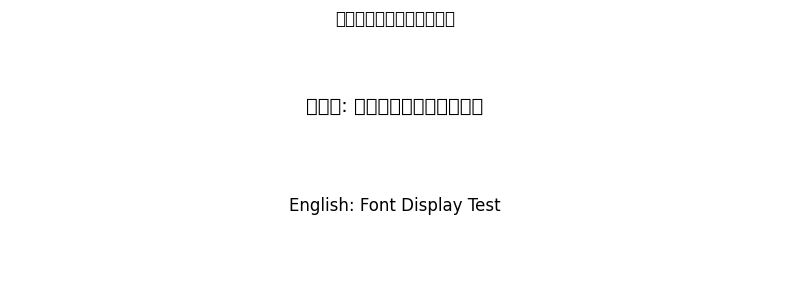

✓ 日本語表示対応確認完了


In [ ]:
# ───────────────────────────────────────────────
# セクション0.1.3
# 初期化・パラメータ定義_Colab 環境設定_日本語フォント設定
# ───────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib

# 日本語フォント設定
try:
    # Colab デフォルトの日本語フォント（NotoSansCJK）を使用
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # フォールバック

    # 日本語フォントの設定試行
    import subprocess
    result = subprocess.run(['fc-list', ':', 'family'], capture_output=True, text=True)

    if 'Noto Sans CJK' in result.stdout or 'Noto Sans Mono CJK' in result.stdout:
        plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
        font_name = 'Noto Sans CJK JP'
    elif 'DejaVu Sans' in result.stdout:
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
        font_name = 'DejaVu Sans'
    else:
        font_name = 'default'

    plt.rcParams['axes.unicode_minus'] = False

    print("✓ 日本語フォント設定完了")
    print(f"  使用フォント: {font_name}")

except Exception as e:
    print(f"⚠ フォント設定に警告がありますが、処理は続行します: {str(e)}")
    plt.rcParams['axes.unicode_minus'] = False

# テスト: 日本語表示確認
fig, ax = plt.subplots(figsize=(8, 3))
ax.text(0.5, 0.7, 'テスト: 日本語フォント表示確認',
        ha='center', va='center', fontsize=14)
ax.text(0.5, 0.3, 'English: Font Display Test',
        ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title('日本語フォント設定テスト')
plt.tight_layout()
plt.show()

print("✓ 日本語表示対応確認完了")

In [ ]:
# ───────────────────────────────────────────────
# セクション0.1.4
# Colab 環境設定_Logger初期化（全体共通）
# ───────────────────────────────────────────────

import logging

try:
    # =============== Logger設定 ===============
    LOG_LEVEL = logging.INFO

    # ロガーの作成
    logger = logging.getLogger('TradingSystem')
    logger.setLevel(LOG_LEVEL)

    # 既存のハンドラーを削除（重複防止）
    if logger.handlers:
        logger.handlers.clear()

    # コンソール出力ハンドラー
    console_handler = logging.StreamHandler()
    console_handler.setLevel(LOG_LEVEL)

    # ログフォーマット定義
    log_format = logging.Formatter(
        '[%(asctime)s] [%(levelname)s] %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S'
    )
    console_handler.setFormatter(log_format)

    # ロガーにハンドラーを追加
    logger.addHandler(console_handler)

    # グローバル変数に保存
    globals()['logger'] = logger

    # テストログ出力
    logger.info("Logger初期化完了")

    print("✓ Logger初期化完了")
    print(f"  ロギングレベル: {logging.getLevelName(LOG_LEVEL)}")
    print(f"  ロガー名: TradingSystem")
    print(f"  ハンドラー: コンソール出力")
    print()

    print("✓ logger オブジェクトは後続セクション（0.2以降）で使用可能です")
    print("  使用例:")
    print("    logger.info('情報ログ')")
    print("    logger.warning('警告ログ')")
    print("    logger.error('エラーログ')")
    print()

except Exception as e:
    print(f"✗ Logger初期化エラー: {str(e)}")
    print(f"  詳細: {traceback.format_exc()}")
    raise Exception("Logger初期化に失敗しました")

[2025-11-29 03:12:49] [INFO] Logger初期化完了
INFO:TradingSystem:Logger初期化完了


✓ Logger初期化完了
  ロギングレベル: INFO
  ロガー名: TradingSystem
  ハンドラー: コンソール出力

✓ logger オブジェクトは後続セクション（0.2以降）で使用可能です
  使用例:
    logger.info('情報ログ')
    logger.warning('警告ログ')
    logger.error('エラーログ')



#セクション0.2：初期化・パラメータ定義_CONFIG パラメータ読み込み

In [ ]:
# #0.2：初期化・パラメータ定義_CONFIG パラメータ読み込み

# ───────────────────────────────────────────────
# セクション0.2.1
# 初期化・パラメータ定義_CONFIG パラメータ読み込み_Google Sheets API 認証
# ───────────────────────────────────────────────

from google.colab import auth
from google.auth import default
import gspread

try:
    # Google Colab 環境での認証
    auth.authenticate_user()

    # Colab 環境で認可情報を取得
    creds, _ = default()

    # gspread クライアント作成（Colab 認証情報を使用）
    gc = gspread.authorize(creds)

    print("✓ Google Sheets API 認証完了")
    print("  認証情報: Google Colab デフォルト認証")
    print("  gspread クライアント: 作成完了")

except Exception as e:
    print(f"✗ 認証エラー: {str(e)}")
    print(f"  詳細: {traceback.format_exc()}")
    raise Exception("Google Sheets API 認証に失敗しました")

✓ Google Sheets API 認証完了
  認証情報: Google Colab デフォルト認証
  gspread クライアント: 作成完了


In [ ]:
# #0.2：初期化・パラメータ定義_CONFIG パラメータ読み込み

# ───────────────────────────────────────────────
# セクション0.2.2
# 初期化・パラメータ定義_CONFIG パラメータ読み込み_CONFIG シート読み込み
# ───────────────────────────────────────────────

import gspread
import pandas as pd
from google.colab import auth

try:
    # gspread クライアント作成（前のセルで実行済みの場合は不要）
    try:
        gc  # gc が存在するか確認
    except NameError:
        auth.authenticate_user()
        gc = gspread.oauth()

    # スプレッドシート ID（設定が必要）
    spreadsheet_id = "1jdE43a3p9WqILSGugGmLolowP2S1clUqhXHt_a9Biwc"
    sheet_name = "CONFIG"

    # スプレッドシート開く
    spreadsheet = gc.open_by_key(spreadsheet_id)
    worksheet = spreadsheet.worksheet(sheet_name)

    # シート全体をデータフレームに読み込み
    data = worksheet.get_all_values()

    # "カテゴリ" 行を見つける（ヘッダー行）
    header_row_idx = None
    for idx, row in enumerate(data):
        if row and row[0] == 'カテゴリ':
            header_row_idx = idx
            break

    if header_row_idx is None:
        raise ValueError("'カテゴリ' 行が見つかりません")

    # ヘッダー行以降のデータを抽出
    header = data[header_row_idx]
    data_rows = data[header_row_idx + 1:]

    # データフレームに変換
    config_df = pd.DataFrame(data_rows, columns=header)

    # 空行を削除
    config_df = config_df.dropna(how='all')
    config_df = config_df[config_df['カテゴリ'] != '']  # カテゴリが空でない行のみ

    print("✓ CONFIG シート読み込み成功")
    print(f"  シート: {sheet_name}")
    print(f"  行数: {len(config_df)}")
    print(f"  列数: {len(config_df.columns)}")
    print(f"\n  カラム一覧: {list(config_df.columns)}")

    # 先頭5行を確認
    print(f"\n  先頭5行:")
    print(config_df.head())

except Exception as e:
    print(f"✗ CONFIG シート読み込みエラー: {str(e)}")
    print(f"  詳細: {traceback.format_exc()}")
    raise Exception("CONFIG シートの読み込みに失敗しました")

✓ CONFIG シート読み込み成功
  シート: CONFIG
  行数: 106
  列数: 8

  カラム一覧: ['カテゴリ', 'param_key', '説明', 'デフォルト値', '型', '必須', 'バリデーション', '備考']

  先頭5行:
   カテゴリ        param_key                    説明      デフォルト値      型 必須  \
0  期間設定            START  指標計算の基準開始日（過去データ取得用）  2023-01-01   date  Y   
1  期間設定              END             データ取得の最終日  2025-06-10   date  Y   
2  期間設定       TEST_START           バックテスト実行開始日  2024-01-10   date  Y   
3  期間設定         TEST_END           バックテスト実行終了日  2025-06-10   date  Y   
4  資金管理  initial_capital      バックテストの初期資金（JPY）   1,000,000  float  Y   

                                       バリデーション  \
0                               is_date(START)   
1                is_date(END) and END >= START   
2  is_date(TEST_START) and TEST_START >= START   
3        is_date(TEST_END) and TEST_END <= END   
4                          initial_capital > 0   

                                    備考  
0  ISO形式 YYYY-MM-DD。TEST_STARTより前であること  
1                       現在日付または過去日付を指定  
2      

In [ ]:
# #0.2：初期化・パラメータ定義_CONFIG パラメータ読み込み

# ───────────────────────────────────────────────
# セクション0.2.3
# 初期化・パラメータ定義_CONFIG パラメータ読み込み_パラメータバリデーション
# ───────────────────────────────────────────────

import pandas as pd
from datetime import datetime

try:
    # バリデーション結果を格納するリスト
    validation_results = []
    validation_errors = []

    print("✓ パラメータバリデーション開始")
    print(f"  対象: {len(config_df)} 個のパラメータ")
    print()

    # 各パラメータをチェック
    for idx, row in config_df.iterrows():
        param_key = row['param_key']
        default_value = row['デフォルト値']
        required = row['必須']
        data_type = row['型']

        # 必須チェック
        if required == 'Y' and (pd.isna(default_value) or default_value == ''):
            validation_errors.append(f"  ✗ {param_key}: 必須パラメータにデフォルト値がありません")

        # データ型チェック
        if data_type == 'date' and default_value != '':
            try:
                datetime.strptime(str(default_value), '%Y-%m-%d')
            except ValueError:
                validation_errors.append(f"  ✗ {param_key}: 日付形式が不正です（{default_value}）")

        if data_type == 'integer' and default_value != '':
            try:
                int(float(default_value))
            except ValueError:
                validation_errors.append(f"  ✗ {param_key}: 整数形式が不正です（{default_value}）")

        if data_type == 'float' and default_value != '':
            try:
                float(default_value)
            except ValueError:
                validation_errors.append(f"  ✗ {param_key}: 浮動小数点形式が不正です（{default_value}）")

    # バリデーション結果を表示
    if validation_errors:
        print("⚠ バリデーション警告:")
        for error in validation_errors:
            print(error)
        print(f"\n  警告数: {len(validation_errors)}")
    else:
        print("✓ すべてのパラメータが有効です")

    print(f"\n✓ パラメータバリデーション完了")
    print(f"  チェック項目:")
    print(f"    - 必須フラグ確認")
    print(f"    - データ型確認（date, integer, float）")

except Exception as e:
    print(f"✗ バリデーションエラー: {str(e)}")
    print(f"  詳細: {traceback.format_exc()}")
    raise Exception("パラメータバリデーションに失敗しました")

✓ パラメータバリデーション開始
  対象: 106 個のパラメータ

⚠ バリデーション警告:
  ✗ initial_capital: 浮動小数点形式が不正です（1,000,000）
  ✗ min_cash_reserve: 浮動小数点形式が不正です（100,000）

  警告数: 2

✓ パラメータバリデーション完了
  チェック項目:
    - 必須フラグ確認
    - データ型確認（date, integer, float）


In [ ]:
# ───────────────────────────────────────────────
# セクション0.2.4
# 初期化・パラメータ定義_CONFIG パラメータ読み込み_パラメータをグローバル変数化
# 【修正版】JST設定対応 + logger.info()対応
# ───────────────────────────────────────────────

from datetime import datetime
import pytz

try:
    logger.info("\n【セクション0.2.4：パラメータをグローバル変数化】")

    # config_df を辞書に変換（param_key をキー、デフォルト値を値）
    config = {}

    # ===== 除外対象キーの定義 =====
    # ヘッダー情報や日本語ラベルは除外
    exclude_keys = {
        '', 'デフォルト値', 'データ型', 'パラメータのカテゴリ分類',
        'パラメータの一意識別名', 'パラメータの人間向け説明',
        '実行時必須フラグ', '検証ルール', '補足事項', '説明',
        'カテゴリ'
    }

    for idx, row in config_df.iterrows():
        param_key = row['param_key']
        default_value = row['デフォルト値']
        data_type = row['型']

        # ===== 除外対象をスキップ =====
        if param_key in exclude_keys or pd.isna(param_key):
            continue

        # ===== データ型に応じて値を正規化・変換 =====
        normalized_value = None

        if data_type == 'date':
            try:
                if pd.isna(default_value) or default_value == '':
                    normalized_value = None
                else:
                    normalized_value = datetime.strptime(str(default_value), '%Y-%m-%d').date()
            except (ValueError, TypeError):
                normalized_value = default_value

        elif data_type == 'integer':
            try:
                if pd.isna(default_value) or default_value == '':
                    normalized_value = None
                else:
                    # 文字列のカンマを削除して整数に変換
                    normalized_value = int(float(str(default_value).replace(',', '')))
            except (ValueError, TypeError):
                normalized_value = default_value

        elif data_type == 'float':
            try:
                if pd.isna(default_value) or default_value == '':
                    normalized_value = None
                else:
                    # 文字列のカンマを削除して浮動小数点に変換
                    normalized_value = float(str(default_value).replace(',', ''))
            except (ValueError, TypeError):
                normalized_value = default_value

        elif data_type == 'boolean':
            try:
                if pd.isna(default_value) or default_value == '':
                    normalized_value = False
                else:
                    normalized_value = str(default_value).upper() in ['TRUE', '1', 'YES', 'Y']
            except (ValueError, TypeError):
                normalized_value = False

        else:
            # 文字列型（その他）
            normalized_value = str(default_value) if not pd.isna(default_value) else None

        # ===== config辞書に格納 =====
        config[param_key] = normalized_value

    # グローバル変数として設定
    globals()['config'] = config

    logger.info(f"  config 辞書作成: {len(config)} 個のパラメータ")

    print("✓ パラメータをグローバル変数化完了")
    print(f"  config 辞書作成: {len(config)} 個のパラメータ")
    print()

    # ===== 型変換結果の確認 =====
    print("✓ データ型正規化結果:")
    print()

    # 主要パラメータの確認と型表示
    key_params = [
        'START', 'END', 'TEST_START', 'TEST_END',
        'initial_capital', 'MAX_HOLD_DAYS', 'MIN_HOLD_DAYS',
        'max_positions', 'fee_per_trade', 'fee_pct',
        'entry_slippage_market', 'exit_slippage_market'
    ]

    print("  【日付型パラメータ】")
    for key in key_params:
        if key in config and isinstance(config[key], type(datetime.now().date())):
            print(f"    - config['{key}']: {config[key]} (型: {type(config[key]).__name__})")

    print()
    print("  【整数型パラメータ】")
    for key in key_params:
        if key in config and isinstance(config[key], int):
            print(f"    - config['{key}']: {config[key]:,} (型: {type(config[key]).__name__})")

    print()
    print("  【浮動小数点型パラメータ】")
    for key in key_params:
        if key in config and isinstance(config[key], float):
            print(f"    - config['{key}']: {config[key]:.6f} (型: {type(config[key]).__name__})")

    print()

    # ===== 型別統計 =====
    print("✓ パラメータの型別統計:")
    type_counts = {}
    for key, val in config.items():
        t = type(val).__name__
        type_counts[t] = type_counts.get(t, 0) + 1
    print(f"  {type_counts}")

    logger.info(f"  パラメータの型別統計: {type_counts}")

    print()

    # =============== 【新規追加】JST（タイムゾーン）設定 ===============
    logger.info("\n【JST（タイムゾーン）設定】")

    try:
        timezone_name = config.get('TIMEZONE', 'Asia/Tokyo')
        jst = pytz.timezone(timezone_name)

        # グローバル変数に保存
        globals()['jst'] = jst

        logger.info(f"  TIMEZONE: {timezone_name}")
        logger.info(f"  pytz オブジェクト: {jst}")

        print("✓ タイムゾーン設定完了")
        print(f"  TIMEZONE: {timezone_name}")
        print(f"  jst オブジェクト: 後続セクションで使用可能")
        print()

    except Exception as tz_error:
        logger.error(f"タイムゾーン設定エラー: {str(tz_error)}")
        print(f"✗ タイムゾーン設定エラー: {str(tz_error)}")
        raise

    # =============== グローバル変数確認 ===============
    logger.info("\n【グローバル変数確認】")
    logger.info(f"  - config: {len(config)} 個のパラメータ")
    logger.info(f"  - jst: {jst}（TIMEZONE: {config['TIMEZONE']}）")

    print("✓ グローバル変数設定完了")
    print("  - config: パラメータ辞書")
    print("  - jst: pytz タイムゾーンオブジェクト")
    print()

    print("✓ config 辞書は後続セクションで参照可能です")
    print("  ※ すべてのパラメータが正規化済みです")
    print("  ※ セクション4.1以降で型チェック不要です")
    print()
    print("✓ jst オブジェクトは後続セクションで参照可能です")
    print("  使用例: datetime.now(jst).strftime('%Y-%m-%d %H:%M:%S')")

    logger.info("✅ セクション0.2.4 完了")

except Exception as e:
    logger.error(f"セクション0.2.4エラー: {str(e)}")
    print(f"✗ グローバル変数化エラー: {str(e)}")
    print(f"  詳細: {traceback.format_exc()}")
    raise Exception("パラメータをグローバル変数化に失敗しました")

[2025-11-29 04:21:29] [INFO] 
【セクション0.2.4：パラメータをグローバル変数化】
INFO:TradingSystem:
【セクション0.2.4：パラメータをグローバル変数化】
[2025-11-29 04:21:29] [INFO]   config 辞書作成: 96 個のパラメータ
INFO:TradingSystem:  config 辞書作成: 96 個のパラメータ
[2025-11-29 04:21:29] [INFO]   パラメータの型別統計: {'date': 4, 'float': 30, 'int': 29, 'str': 18, 'bool': 15}
INFO:TradingSystem:  パラメータの型別統計: {'date': 4, 'float': 30, 'int': 29, 'str': 18, 'bool': 15}
[2025-11-29 04:21:29] [INFO] 
【JST（タイムゾーン）設定】
INFO:TradingSystem:
【JST（タイムゾーン）設定】
[2025-11-29 04:21:29] [INFO]   TIMEZONE: Asia/Tokyo
INFO:TradingSystem:  TIMEZONE: Asia/Tokyo
[2025-11-29 04:21:29] [INFO]   pytz オブジェクト: Asia/Tokyo
INFO:TradingSystem:  pytz オブジェクト: Asia/Tokyo
[2025-11-29 04:21:29] [INFO] 
【グローバル変数確認】
INFO:TradingSystem:
【グローバル変数確認】
[2025-11-29 04:21:29] [INFO]   - config: 96 個のパラメータ
INFO:TradingSystem:  - config: 96 個のパラメータ
[2025-11-29 04:21:29] [INFO]   - jst: Asia/Tokyo（TIMEZONE: Asia/Tokyo）
INFO:TradingSystem:  - jst: Asia/Tokyo（TIMEZONE: Asia/Tokyo）
[2025-11-29 04:21:29] [I

✓ パラメータをグローバル変数化完了
  config 辞書作成: 96 個のパラメータ

✓ データ型正規化結果:

  【日付型パラメータ】
    - config['START']: 2023-01-01 (型: date)
    - config['END']: 2025-06-10 (型: date)
    - config['TEST_START']: 2024-01-10 (型: date)
    - config['TEST_END']: 2025-06-10 (型: date)

  【整数型パラメータ】
    - config['MAX_HOLD_DAYS']: 12 (型: int)
    - config['MIN_HOLD_DAYS']: 1 (型: int)
    - config['max_positions']: 3 (型: int)

  【浮動小数点型パラメータ】
    - config['initial_capital']: 1000000.000000 (型: float)
    - config['fee_per_trade']: 0.000000 (型: float)
    - config['fee_pct']: 0.001000 (型: float)
    - config['entry_slippage_market']: 0.003000 (型: float)
    - config['exit_slippage_market']: 0.003000 (型: float)

✓ パラメータの型別統計:
  {'date': 4, 'float': 30, 'int': 29, 'str': 18, 'bool': 15}

✓ タイムゾーン設定完了
  TIMEZONE: Asia/Tokyo
  jst オブジェクト: 後続セクションで使用可能

✓ グローバル変数設定完了
  - config: パラメータ辞書
  - jst: pytz タイムゾーンオブジェクト

✓ config 辞書は後続セクションで参照可能です
  ※ すべてのパラメータが正規化済みです
  ※ セクション4.1以降で型チェック不要です

✓ jst オブジェクトは後続セクションで参照可能です
  使用例: da

#セクション0.3：初期化・パラメータ定義_ロギング・エラーハンドリング設定

In [ ]:
# ───────────────────────────────────────────────
# セクション0.3
# 初期化・パラメータ定義_ロギング・エラーハンドリング設定
# 【統合版】セクション0.3.1 + 0.3.2（Logger確認 + JST対応）
# ───────────────────────────────────────────────

import os
import traceback
from datetime import datetime

try:
    # =============== セクション0.3.1：Logger・タイムゾーン確認 ===============
    logger.info("\n【セクション0.3.1：Logger・タイムゾーン確認】")

    print("\n【セクション0.3.1：Logger・タイムゾーン確認】")
    print()

    # Logger確認
    logger.info(f"  Logger名: {logger.name}")
    logger.info(f"  ロギングレベル: {logger.level}")
    logger.info(f"  ハンドラー数: {len(logger.handlers)}")

    print("✓ Logger確認完了")
    print(f"  Logger名: {logger.name}")
    print(f"  ロギングレベル: {logger.level}")
    print(f"  ハンドラー数: {len(logger.handlers)}")
    print()

    # タイムゾーン確認（セクション0.2.4で設定済みのjstを参照）
    current_time_jst = datetime.now(jst)
    logger.info(f"  TIMEZONE: {config['TIMEZONE']}")
    logger.info(f"  現在時刻（JST）: {current_time_jst.strftime('%Y-%m-%d %H:%M:%S')}")

    print("✓ タイムゾーン確認完了")
    print(f"  TIMEZONE: {config['TIMEZONE']}")
    print(f"  現在時刻（JST）: {current_time_jst.strftime('%Y-%m-%d %H:%M:%S')}")
    print()

    logger.info("✅ セクション0.3.1 完了")

    # =============== セクション0.3.2：実行履歴ディレクトリ作成・RUN_ID定義 ===============
    logger.info("\n【セクション0.3.2：実行履歴ディレクトリ作成・RUN_ID定義】")

    print("【セクション0.3.2：実行履歴ディレクトリ作成・RUN_ID定義】")
    print()

    # =============== JST現在時刻からタイムスタンプを生成 ===============
    timestamp = datetime.now(jst).strftime('%Y%m%d_%H%M%S')
    logger.info(f"  タイムスタンプ（JST）: {timestamp}")

    print(f"✓ タイムスタンプ（JST）生成完了: {timestamp}")
    print()

    # =============== 出力ディレクトリ取得 ===============
    base_save_dir = config['SAVE_DIR']
    logger.info(f"  ベースディレクトリ: {base_save_dir}")

    print(f"✓ ベースディレクトリ: {base_save_dir}")
    print()

    # =============== タイムスタンプ付きディレクトリ名作成 ===============
    run_dir = os.path.join(base_save_dir, f"run_{timestamp}")
    logger.info(f"  実行ディレクトリ名: run_{timestamp}")

    # =============== ディレクトリ作成 ===============
    os.makedirs(run_dir, exist_ok=True)
    logger.info(f"  ディレクトリ作成: {run_dir}")

    print(f"✓ ディレクトリ作成完了: {run_dir}")
    print()

    # =============== RUN_ID定義 ===============
    RUN_ID = timestamp
    logger.info(f"  RUN_ID: {RUN_ID}")

    print(f"✓ RUN_ID定義完了: {RUN_ID}")
    print()

    # =============== グローバル変数に保存 ===============
    globals()['RUN_DIR'] = run_dir
    globals()['RUN_ID'] = RUN_ID

    logger.info(f"  グローバル変数登録: RUN_DIR, RUN_ID")

    # =============== ディレクトリ確認 ===============
    if os.path.exists(run_dir):
        logger.info(f"  ディレクトリ確認: OK")
        print(f"✓ ディレクトリ確認: 正常に作成されました")
        print()
    else:
        logger.error(f"ディレクトリ作成失敗: {run_dir}")
        raise Exception(f"ディレクトリ作成失敗: {run_dir}")

    logger.info("✅ セクション0.3.2 完了")

    # =============== セクション0.3 全体完了ログ ===============
    logger.info("\n【グローバル変数最終確認】")
    logger.info(f"  - logger: TradingSystem")
    logger.info(f"  - config: {len(config)} 個のパラメータ")
    logger.info(f"  - jst: {jst}（TIMEZONE: {config['TIMEZONE']}）")
    logger.info(f"  - RUN_ID: {RUN_ID}")
    logger.info(f"  - RUN_DIR: {run_dir}")
    logger.info("\n✅ セクション0.3（ロギング・エラーハンドリング設定）完了")

    print("【グローバル変数最終確認】")
    print(f"  - logger: TradingSystem")
    print(f"  - config: {len(config)} 個のパラメータ")
    print(f"  - jst: {jst}（TIMEZONE: {config['TIMEZONE']}）")
    print(f"  - RUN_ID: {RUN_ID}")
    print(f"  - RUN_DIR: {run_dir}")
    print()
    print("✅ セクション0.3（ロギング・エラーハンドリング設定）完了")
    print()
    print("=" * 60)
    print("✓ Phase 0「初期化・パラメータ定義」の主要セクション完了")
    print("=" * 60)

except Exception as e:
    logger.error(f"セクション0.3エラー: {str(e)}")
    print(f"✗ セクション0.3 エラー: {str(e)}")
    print(f"  詳細: {traceback.format_exc()}")
    raise Exception("セクション0.3の初期化に失敗しました")

[2025-11-29 04:21:30] [INFO] 
【セクション0.3.1：Logger・タイムゾーン確認】
INFO:TradingSystem:
【セクション0.3.1：Logger・タイムゾーン確認】
[2025-11-29 04:21:30] [INFO]   Logger名: TradingSystem
INFO:TradingSystem:  Logger名: TradingSystem
[2025-11-29 04:21:30] [INFO]   ロギングレベル: 20
INFO:TradingSystem:  ロギングレベル: 20
[2025-11-29 04:21:30] [INFO]   ハンドラー数: 1
INFO:TradingSystem:  ハンドラー数: 1
[2025-11-29 04:21:30] [INFO]   TIMEZONE: Asia/Tokyo



【セクション0.3.1：Logger・タイムゾーン確認】

✓ Logger確認完了
  Logger名: TradingSystem
  ロギングレベル: 20
  ハンドラー数: 1



INFO:TradingSystem:  TIMEZONE: Asia/Tokyo
[2025-11-29 04:21:30] [INFO]   現在時刻（JST）: 2025-11-29 13:21:30
INFO:TradingSystem:  現在時刻（JST）: 2025-11-29 13:21:30
[2025-11-29 04:21:30] [INFO] ✅ セクション0.3.1 完了
INFO:TradingSystem:✅ セクション0.3.1 完了
[2025-11-29 04:21:30] [INFO] 
【セクション0.3.2：実行履歴ディレクトリ作成・RUN_ID定義】
INFO:TradingSystem:
【セクション0.3.2：実行履歴ディレクトリ作成・RUN_ID定義】
[2025-11-29 04:21:30] [INFO]   タイムスタンプ（JST）: 20251129_132130
INFO:TradingSystem:  タイムスタンプ（JST）: 20251129_132130
[2025-11-29 04:21:30] [INFO]   ベースディレクトリ: /content/drive/MyDrive/trading/results
INFO:TradingSystem:  ベースディレクトリ: /content/drive/MyDrive/trading/results
[2025-11-29 04:21:30] [INFO]   実行ディレクトリ名: run_20251129_132130
INFO:TradingSystem:  実行ディレクトリ名: run_20251129_132130
[2025-11-29 04:21:30] [INFO]   ディレクトリ作成: /content/drive/MyDrive/trading/results/run_20251129_132130
INFO:TradingSystem:  ディレクトリ作成: /content/drive/MyDrive/trading/results/run_20251129_132130
[2025-11-29 04:21:30] [INFO]   RUN_ID: 20251129_132130
INFO:TradingSystem:  

✓ タイムゾーン確認完了
  TIMEZONE: Asia/Tokyo
  現在時刻（JST）: 2025-11-29 13:21:30

【セクション0.3.2：実行履歴ディレクトリ作成・RUN_ID定義】

✓ タイムスタンプ（JST）生成完了: 20251129_132130

✓ ベースディレクトリ: /content/drive/MyDrive/trading/results

✓ ディレクトリ作成完了: /content/drive/MyDrive/trading/results/run_20251129_132130

✓ RUN_ID定義完了: 20251129_132130

✓ ディレクトリ確認: 正常に作成されました



INFO:TradingSystem:  - jst: Asia/Tokyo（TIMEZONE: Asia/Tokyo）
[2025-11-29 04:21:30] [INFO]   - RUN_ID: 20251129_132130
INFO:TradingSystem:  - RUN_ID: 20251129_132130
[2025-11-29 04:21:30] [INFO]   - RUN_DIR: /content/drive/MyDrive/trading/results/run_20251129_132130
INFO:TradingSystem:  - RUN_DIR: /content/drive/MyDrive/trading/results/run_20251129_132130
[2025-11-29 04:21:30] [INFO] 
✅ セクション0.3（ロギング・エラーハンドリング設定）完了
INFO:TradingSystem:
✅ セクション0.3（ロギング・エラーハンドリング設定）完了


【グローバル変数最終確認】
  - logger: TradingSystem
  - config: 96 個のパラメータ
  - jst: Asia/Tokyo（TIMEZONE: Asia/Tokyo）
  - RUN_ID: 20251129_132130
  - RUN_DIR: /content/drive/MyDrive/trading/results/run_20251129_132130

✅ セクション0.3（ロギング・エラーハンドリング設定）完了

✓ Phase 0「初期化・パラメータ定義」の主要セクション完了


In [ ]:
# #0.3：初期化・パラメータ定義_ロギング・エラーハンドリング設定

# ───────────────────────────────────────────────
# セクション0.3.3
# 初期化・パラメータ定義_ロギング・エラーハンドリング設定_エラーハンドリング関数定義
# ───────────────────────────────────────────────

import traceback
from typing import Optional, Dict, Any

# カスタム例外クラス定義
class TradingSystemException(Exception):
    """トレーディングシステム用カスタム例外"""
    pass

class DataException(TradingSystemException):
    """データ関連エラー"""
    pass

class APIException(TradingSystemException):
    """API関連エラー"""
    pass

class SignalException(TradingSystemException):
    """シグナル計算エラー"""
    pass

class BacktestException(TradingSystemException):
    """バックテスト実行エラー"""
    pass

# エラーハンドリング関数
def handle_exception(error: Exception, section_name: str = "Unknown",
                     is_fatal: bool = False) -> Dict[str, Any]:
    """
    例外をハンドリングしてログ出力

    Args:
        error: 例外オブジェクト
        section_name: セクション名
        is_fatal: 致命的エラーか（Trueの場合は処理を停止）

    Returns:
        エラー情報の辞書
    """
    error_info = {
        'timestamp': datetime.now().isoformat(),
        'section': section_name,
        'error_type': type(error).__name__,
        'error_message': str(error),
        'traceback': traceback.format_exc()
    }

    # ログ出力
    if is_fatal:
        logger.critical(f"[{section_name}] 致命的エラー: {str(error)}")
    else:
        logger.error(f"[{section_name}] エラー: {str(error)}")

    return error_info

# 成功メッセージ関数
def log_success(section_name: str, message: str, details: Optional[Dict] = None):
    """セクション完了ログを出力"""
    logger.info(f"[{section_name}] ✓ {message}")
    if details:
        for key, value in details.items():
            logger.info(f"  {key}: {value}")

try:
    print("✓ エラーハンドリング関数定義完了")
    print()
    print("✓ 定義済みカスタム例外クラス:")
    print("  - TradingSystemException (基底クラス)")
    print("  - DataException (データ関連エラー)")
    print("  - APIException (API関連エラー)")
    print("  - SignalException (シグナル計算エラー)")
    print("  - BacktestException (バックテスト実行エラー)")
    print()
    print("✓ 定義済みエラーハンドリング関数:")
    print("  - handle_exception(error, section_name, is_fatal)")
    print("  - log_success(section_name, message, details)")
    print()
    print("✓ 後続セクションで使用可能です")

    logger.info("エラーハンドリング関数定義完了")

except Exception as e:
    logger.error(f"エラーハンドリング関数定義エラー: {str(e)}")
    print(f"✗ エラーハンドリング関数定義エラー: {str(e)}")
    print(f"  詳細: {traceback.format_exc()}")
    raise Exception("エラーハンドリング関数定義に失敗しました")

[2025-11-29 04:21:30] [INFO] エラーハンドリング関数定義完了
INFO:TradingSystem:エラーハンドリング関数定義完了


✓ エラーハンドリング関数定義完了

✓ 定義済みカスタム例外クラス:
  - TradingSystemException (基底クラス)
  - DataException (データ関連エラー)
  - APIException (API関連エラー)
  - SignalException (シグナル計算エラー)
  - BacktestException (バックテスト実行エラー)

✓ 定義済みエラーハンドリング関数:
  - handle_exception(error, section_name, is_fatal)
  - log_success(section_name, message, details)

✓ 後続セクションで使用可能です


#セクション0.4：初期化・パラメータ定義_JQUANTS 認証管理

In [ ]:
# #0.4：初期化・パラメータ定義_JQUANTS 認証管理

# ───────────────────────────────────────────────
# セクション0.4.1
# 初期化・パラメータ定義_JQUANTS 認証管理_リフレッシュトークン設定
# ───────────────────────────────────────────────

try:
    # ★★★ ここに J-Quants のリフレッシュトークンを直接埋め込んでください ★★★
    # 下記の例を参考に、J-Quants から発行されたトークンを貼り付けてください
    # 注意：このトークンが漏洩するとあなたのアカウントで不正リクエストされるため、
    #       GitHubなどで管理する場合は絶対にこのセルをコミットしないでください

    JQ_REFRESH_TOKEN = "eyJjdHkiOiJKV1QiLCJlbmMiOiJBMjU2R0NNIiwiYWxnIjoiUlNBLU9BRVAifQ.Oz5GcxgZV5B-UfySIGBVw2_yrksDx8DkONqSTOIXRUmB_892IoWwhOwOYLaEfuVl7PxBMSIxFRfvdP0zvKsk2xdy_6d-72ENiHa-iJmYaA9OaOKh1bV8Kzs8KbzMZ6uTiiWggxfPYvf4RXqKTXImEvfzgbGbhjgqOAnKWLgXiAcMgkh0tJGRBbNOvk4xOd6RTSIzkiR7xC4sjJ4TpgG6Gg7qxixCzqZJ6a_KN71ocaN0l0aVHuF2dV3ZdS3j_Exyxsfs6WX7PFwu7mT45xx2C29sXuvfaIy5TLGqKqj-8gwK0QEmBTb9bAc2Ajg34W_Pdh6Dse7wA8ZGPxxeocIPIQ.EWR62TANqkrvvrKH.xFUoIV-mtlwEJD7YGIY3RzJdOsAmkjLgmjYmbwGU_aHNngtqkvD9I4ovjCIfcQwNSUl76T8dSVxt3qU_Q98mDYsqHH34roYlBUt9UQI2BxNkOtNmdN16jeBun7dfhTrz00pR0ysXbyauNC6I_ShGkhy1lPMTmj1OzREQi_HPnhd42RHyupo6FnQjpENH_IMHvnkVf9P-moJboaSbjIniXHuN0vwR1jkVRcTbTCWpl642dGGrFbO5yBtC8PNFWmbFxhdSq0Zk8zD_Z09EnBnu4IhHG5yomBKdSiyf4zsxUNytHCsAE_AYrNnDHNnEZ4C-SunEKemnvxqHAEl5iY2MHCjDTPuA1GQetnt_A729IOmXUCm5Noi1OpmgdhHEHHxSqrW6RylF3DRgeHJEMcaHTLIw4DAKg0nyAMQylGMIuq53dTeUcc-VojyrcO3HBYOqsXhYazJUO0MqHNEp1TiLCxXeUnVEaPofpn4T89HKGHIGgA_Omqx59CQLM5PMliQABdFXRb4FXdrL82UCpaior1kZ62nUqjybD2ZBoGGZlDHhppy7yZWd9GoY5y2u8o5sdv04xvh0-xD6PFoCf_1w5eFhalVKoiuQ4XzUnVatJGBT9oKVV9PaqzGokhoM34AibaR16KAORUbOZ-dsnSsppsx_PLvwSq05DZW3wli8h8XcJF4X9iWyzH3Xhcu2W8ZD2bvWypz9Wpk4TiISUK0ESymgmJnUaWuPYsSIRWfQGIKoT3yiAUfRI8d6JZHIAvPbrXyETo0RhcA6wA-sgOCOwh5JLfhuyWencJZPK7jhVnCMTr_Gx63eY-JKGsBR_QQuNJNWpEUISfqKLTtaIKWrEgLwLAG3ID-p0yGyMY_fg05KWwuLAVAx1UP4T-d4fGF4udEpIvTaRNppZftYID3ackGb4wMmhGWuzvawqK32ebiR49nHt5Qrw7jcd2xD6vsTVRLjxTEHqmhT3pTV3ZNMbYQVtnuqfrAqul7H3XseMeroMmvwBSLXi-Bpc5sD4e9DRZv7PFktqCO4CHx92pZkfePSeskd_xi_AJZ-aZoY0fzUojtS77uwHznRcw8YGQfTXvyVUCDyG4vMaFgE6WiKOhs6KimoxoTRegZF-4qltMbPvp0XZ6Hq09mwGMUyPyyEO0aixK0_Joi6s0RW4lSyawLD7G1L50n0wrgpQucRXABpALODN0KWb0xl3MgouZubXuKIjr-7lI4UpdeIDEHaa-0z7oBWcAjlAhy4K2cjXQYiFoKn9z6tYlXD7CmmiZ1gO2MMA2FoopD1nCkAHu2FeH6J0ru0WgnjQHLPaiUd0p_BNhV48PLjQ3nSpLKA8kk-xtuCne6ka-VgiQ.tMDagBTBCv1ih23kFtQBkQ:"

    # ★★★ 上記の行を修正してください ★★★

    # リフレッシュトークンが空白でないかチェック
    if not JQ_REFRESH_TOKEN or JQ_REFRESH_TOKEN == "ここにJ-Quantsのリフレッシュトークンをコピーペーストしてください":
        raise ValueError("JQ_REFRESH_TOKEN が設定されていません。トークンを埋め込んでください。")

    # グローバル変数に設定
    globals()['JQ_REFRESH_TOKEN'] = JQ_REFRESH_TOKEN

    logger.info("JQUANTS リフレッシュトークン設定完了")
    log_success("セクション0.4.1", "リフレッシュトークン設定完了", {
        'トークン': f"{JQ_REFRESH_TOKEN[:20]}... (前20文字)"
    })

    print("✓ JQUANTS リフレッシュトークン設定完了")
    print(f"  トークン長: {len(JQ_REFRESH_TOKEN)} 文字")
    print(f"  先頭20文字: {JQ_REFRESH_TOKEN[:20]}...")
    print()
    print("✓ JQ_REFRESH_TOKEN はグローバル変数として設定済み")

except ValueError as e:
    logger.error(f"リフレッシュトークン設定エラー: {str(e)}")
    print(f"✗ リフレッシュトークン設定エラー: {str(e)}")
    raise
except Exception as e:
    error_info = handle_exception(e, "セクション0.4.1", is_fatal=True)
    print(f"✗ 予期しないエラー: {str(e)}")
    raise

[2025-11-29 04:21:31] [INFO] JQUANTS リフレッシュトークン設定完了
INFO:TradingSystem:JQUANTS リフレッシュトークン設定完了
[2025-11-29 04:21:31] [INFO] [セクション0.4.1] ✓ リフレッシュトークン設定完了
INFO:TradingSystem:[セクション0.4.1] ✓ リフレッシュトークン設定完了
[2025-11-29 04:21:31] [INFO]   トークン: eyJjdHkiOiJKV1QiLCJl... (前20文字)
INFO:TradingSystem:  トークン: eyJjdHkiOiJKV1QiLCJl... (前20文字)


✓ JQUANTS リフレッシュトークン設定完了
  トークン長: 1805 文字
  先頭20文字: eyJjdHkiOiJKV1QiLCJl...

✓ JQ_REFRESH_TOKEN はグローバル変数として設定済み


In [ ]:
# #0.4：初期化・パラメータ定義_JQUANTS 認証管理

# ───────────────────────────────────────────────
# セクション0.4.2
# 初期化・パラメータ定義_JQUANTS 認証管理_IDトークン取得関数定義
# ───────────────────────────────────────────────

import requests

try:
    # IDトークン取得用エンドポイント
    REFRESH_URL = "https://api.jquants.com/v1/token/auth_refresh"

    def get_id_token(refresh_token: str) -> str:
        """
        J-Quants リフレッシュトークンから IDトークンを取得

        Args:
            refresh_token: J-Quants リフレッシュトークン

        Returns:
            IDトークン（文字列）

        Raises:
            APIException: API呼び出し失敗時
        """
        url = f"{REFRESH_URL}?refreshtoken={refresh_token}"

        try:
            logger.info("IDトークン取得リクエスト送信中...")

            # POST リクエスト実行
            response = requests.post(url, timeout=10)

            logger.debug(f"API レスポンスステータス: {response.status_code}")

            # ステータスコード確認
            response.raise_for_status()

            # レスポンスから IDトークンを抽出
            response_json = response.json()

            if 'idToken' not in response_json:
                raise APIException("レスポンスに idToken が含まれていません")

            id_token = response_json['idToken']

            logger.info("IDトークン取得成功")

            return id_token

        except requests.exceptions.Timeout:
            logger.error("API リクエストタイムアウト")
            raise APIException("JQUANTS API タイムアウト（10秒以上応答なし）")
        except requests.exceptions.RequestException as e:
            logger.error(f"API リクエストエラー: {str(e)}")
            raise APIException(f"JQUANTS API リクエスト失敗: {str(e)}")
        except ValueError as e:
            logger.error(f"JSON パースエラー: {str(e)}")
            raise APIException(f"レスポンス JSON パース失敗: {str(e)}")

    logger.info("IDトークン取得関数定義完了")
    log_success("セクション0.4.2", "IDトークン取得関数定義完了", {
        'エンドポイント': REFRESH_URL,
        '関数名': 'get_id_token',
        'タイムアウト': '10秒'
    })

    print("✓ IDトークン取得関数定義完了")
    print(f"  エンドポイント: {REFRESH_URL}")
    print(f"  関数名: get_id_token")
    print(f"  タイムアウト設定: 10秒")
    print()
    print("✓ get_id_token 関数は後続セクションで使用可能です")

except Exception as e:
    error_info = handle_exception(e, "セクション0.4.2", is_fatal=True)
    print(f"✗ IDトークン取得関数定義エラー: {str(e)}")
    raise

[2025-11-29 04:21:31] [INFO] IDトークン取得関数定義完了
INFO:TradingSystem:IDトークン取得関数定義完了
[2025-11-29 04:21:31] [INFO] [セクション0.4.2] ✓ IDトークン取得関数定義完了
INFO:TradingSystem:[セクション0.4.2] ✓ IDトークン取得関数定義完了
[2025-11-29 04:21:31] [INFO]   エンドポイント: https://api.jquants.com/v1/token/auth_refresh
INFO:TradingSystem:  エンドポイント: https://api.jquants.com/v1/token/auth_refresh
[2025-11-29 04:21:31] [INFO]   関数名: get_id_token
INFO:TradingSystem:  関数名: get_id_token
[2025-11-29 04:21:31] [INFO]   タイムアウト: 10秒
INFO:TradingSystem:  タイムアウト: 10秒


✓ IDトークン取得関数定義完了
  エンドポイント: https://api.jquants.com/v1/token/auth_refresh
  関数名: get_id_token
  タイムアウト設定: 10秒

✓ get_id_token 関数は後続セクションで使用可能です


In [ ]:
# #0.4：初期化・パラメータ定義_JQUANTS 認証管理

# ───────────────────────────────────────────────
# セクション0.4.3
# 初期化・パラメータ定義_JQUANTS 認証管理_IDトークン取得・検証
# ───────────────────────────────────────────────

try:
    logger.info("IDトークン取得開始")

    # リフレッシュトークンから IDトークンを取得
    JQ_ID_TOKEN = get_id_token(JQ_REFRESH_TOKEN)

    # IDトークンの妥当性チェック
    if not JQ_ID_TOKEN or len(JQ_ID_TOKEN) == 0:
        raise APIException("取得したIDトークンが空です")

    # グローバル変数に設定
    globals()['JQ_ID_TOKEN'] = JQ_ID_TOKEN

    logger.info("IDトークン取得・検証完了")
    log_success("セクション0.4.3", "IDトークン取得・検証完了", {
        'ステータス': '✓ 成功',
        'トークン長': f"{len(JQ_ID_TOKEN)} 文字",
        'トークン先頭': f"{JQ_ID_TOKEN[:20]}..."
    })

    print("✓ JQUANTS IDトークン取得・検証完了")
    print(f"  ステータス: ✓ 成功")
    print(f"  トークン長: {len(JQ_ID_TOKEN)} 文字")
    print(f"  トークン先頭20文字: {JQ_ID_TOKEN[:20]}...")
    print()
    print("✓ JQ_ID_TOKEN はグローバル変数として設定済み")
    print("✓ Phase 0（初期化・パラメータ定義）が全て完了しました")
    print()
    print("次のステップ:")
    print("  → Phase 1（データ取得・正規化）に進んでください")

except APIException as e:
    logger.error(f"JQUANTS API エラー: {str(e)}")
    print(f"✗ JQUANTS API エラー: {str(e)}")
    print()
    print("対応方法:")
    print("  1. リフレッシュトークンが正しく設定されているか確認")
    print("  2. リフレッシュトークンの有効期限を確認")
    print("  3. インターネット接続を確認")
    raise
except Exception as e:
    error_info = handle_exception(e, "セクション0.4.3", is_fatal=True)
    print(f"✗ 予期しないエラー: {str(e)}")
    print(f"  詳細: {error_info['traceback']}")
    raise

[2025-11-29 04:21:31] [INFO] IDトークン取得開始
INFO:TradingSystem:IDトークン取得開始
[2025-11-29 04:21:31] [INFO] IDトークン取得リクエスト送信中...
INFO:TradingSystem:IDトークン取得リクエスト送信中...
[2025-11-29 04:21:32] [INFO] IDトークン取得成功
INFO:TradingSystem:IDトークン取得成功
[2025-11-29 04:21:32] [INFO] IDトークン取得・検証完了
INFO:TradingSystem:IDトークン取得・検証完了
[2025-11-29 04:21:32] [INFO] [セクション0.4.3] ✓ IDトークン取得・検証完了
INFO:TradingSystem:[セクション0.4.3] ✓ IDトークン取得・検証完了
[2025-11-29 04:21:32] [INFO]   ステータス: ✓ 成功
INFO:TradingSystem:  ステータス: ✓ 成功
[2025-11-29 04:21:32] [INFO]   トークン長: 1105 文字
INFO:TradingSystem:  トークン長: 1105 文字
[2025-11-29 04:21:32] [INFO]   トークン先頭: eyJraWQiOiJHQXNvU2xx...
INFO:TradingSystem:  トークン先頭: eyJraWQiOiJHQXNvU2xx...


✓ JQUANTS IDトークン取得・検証完了
  ステータス: ✓ 成功
  トークン長: 1105 文字
  トークン先頭20文字: eyJraWQiOiJHQXNvU2xx...

✓ JQ_ID_TOKEN はグローバル変数として設定済み
✓ Phase 0（初期化・パラメータ定義）が全て完了しました

次のステップ:
  → Phase 1（データ取得・正規化）に進んでください


# セクション1.1 DATA_SOURCES 管理

In [ ]:
# ───────────────────────────────────────────────
# セクション1.1.1
# Phase1_DATA_SOURCES管理_JQUANTS データ取得関数定義
# ───────────────────────────────────────────────

import requests
import pandas as pd
from datetime import datetime, timedelta
import time
from typing import Dict, List, Tuple, Optional

def fetch_jquants_data(
    id_token: str,
    stock_codes: List[str],
    start_date: str,
    end_date: str,
    data_type: str = "daily",
    max_retries: int = 3,
    retry_wait: int = 5
) -> Tuple[pd.DataFrame, Dict]:
    """
    JQUANTS API から OHLCV データを取得する関数

    Args:
        id_token (str): JQUANTS API 認証 ID トークン
        stock_codes (List[str]): 銘柄コードリスト (例: ['1301', '1302', ...])
        start_date (str): 開始日付 (YYYY-MM-DD 形式)
        end_date (str): 終了日付 (YYYY-MM-DD 形式)
        data_type (str): データタイプ ('daily' のみ実装)
        max_retries (int): API リトライ最大回数
        retry_wait (int): リトライ間隔（秒）

    Returns:
        Tuple[pd.DataFrame, Dict]:
            - raw_price_df: 取得データ
              columns: Date, Code, Open, High, Low, Close, Volume
            - fetch_metadata: 取得メタデータ
    """

    # =============== パラメータ検証 ===============
    logger.info(f"JQUANTS データ取得開始: {len(stock_codes)} 銘柄, 期間 {start_date} ～ {end_date}")

    try:
        start_dt = datetime.strptime(start_date, "%Y-%m-%d")
        end_dt = datetime.strptime(end_date, "%Y-%m-%d")
        if start_dt > end_dt:
            raise ValueError(f"開始日付が終了日付より後ろです: {start_date} > {end_date}")
    except ValueError as e:
        logger.error(f"日付形式エラー: {e}")
        raise

    # =============== API エンドポイント設定 ===============
    base_url = "https://api.jquants.com/v1/ohlc"
    headers = {
        "Authorization": f"Bearer {id_token}",
        "Content-Type": "application/json"
    }

    # =============== データ取得ロジック ===============
    all_data = []
    fetch_metadata = {
        "total_codes": len(stock_codes),
        "successful_codes": 0,
        "failed_codes": [],
        "total_api_calls": 0,
        "total_retries": 0,
        "start_time": datetime.now().isoformat(),
        "errors": []
    }

    for idx, code in enumerate(stock_codes, 1):
        retry_count = 0
        success = False

        while retry_count <= max_retries and not success:
            try:
                # クエリパラメータ構築
                params = {
                    "code": code,
                    "date_gte": start_date,
                    "date_lte": end_date,
                    "pagination_limit": 5000
                }

                # API 呼び出し
                response = requests.get(
                    base_url,
                    headers=headers,
                    params=params,
                    timeout=30
                )
                fetch_metadata["total_api_calls"] += 1

                # ステータスコード処理
                if response.status_code == 200:
                    data = response.json()

                    # レスポンス構造確認：{"data": {"ohlc": [...]}}
                    if "data" in data and "ohlc" in data["data"]:
                        ohlc_list = data["data"]["ohlc"]

                        if len(ohlc_list) > 0:
                            # データ統合
                            for record in ohlc_list:
                                all_data.append({
                                    "Date": record.get("Date"),
                                    "Code": code,
                                    "Open": float(record.get("Open", 0)),
                                    "High": float(record.get("High", 0)),
                                    "Low": float(record.get("Low", 0)),
                                    "Close": float(record.get("Close", 0)),
                                    "Volume": int(record.get("Volume", 0))
                                })
                            logger.debug(f"[{idx}/{len(stock_codes)}] {code}: {len(ohlc_list)} 件取得")
                            fetch_metadata["successful_codes"] += 1
                            success = True
                        else:
                            logger.debug(f"[{idx}/{len(stock_codes)}] {code}: データなし（範囲外か市場休場）")
                            fetch_metadata["successful_codes"] += 1
                            success = True
                    else:
                        error_msg = f"予期しないレスポンス構造"
                        logger.warning(f"[{code}] {error_msg}")
                        fetch_metadata["failed_codes"].append(code)
                        fetch_metadata["errors"].append(error_msg)
                        success = True

                elif response.status_code == 429:  # Rate Limit
                    logger.warning(f"[{code}] Rate Limit (429)")
                    retry_count += 1
                    fetch_metadata["total_retries"] += 1
                    if retry_count <= max_retries:
                        wait_time = retry_wait * (2 ** retry_count)
                        logger.info(f"  {wait_time}秒待機してリトライします...")
                        time.sleep(wait_time)

                elif response.status_code == 401:  # Unauthorized
                    error_msg = "認証エラー (401): トークン無効"
                    logger.error(error_msg)
                    fetch_metadata["errors"].append(error_msg)
                    raise RuntimeError(error_msg)

                elif response.status_code == 400:  # Bad Request
                    error_msg = f"リクエストエラー (400)"
                    logger.warning(f"[{code}] {error_msg}")
                    fetch_metadata["failed_codes"].append(code)
                    fetch_metadata["errors"].append(error_msg)
                    success = True

                else:
                    error_msg = f"API エラー ({response.status_code})"
                    logger.warning(f"[{code}] {error_msg}")
                    retry_count += 1
                    fetch_metadata["total_retries"] += 1
                    if retry_count > max_retries:
                        fetch_metadata["failed_codes"].append(code)
                        fetch_metadata["errors"].append(error_msg)
                        success = True
                    else:
                        time.sleep(retry_wait)

            except requests.exceptions.Timeout:
                error_msg = "タイムアウト"
                logger.warning(f"[{code}] {error_msg}")
                retry_count += 1
                fetch_metadata["total_retries"] += 1
                if retry_count > max_retries:
                    fetch_metadata["failed_codes"].append(code)
                    fetch_metadata["errors"].append(error_msg)
                    success = True
                else:
                    time.sleep(retry_wait)

            except requests.exceptions.ConnectionError as e:
                error_msg = f"接続エラー: {str(e)[:50]}"
                logger.warning(f"[{code}] {error_msg}")
                retry_count += 1
                fetch_metadata["total_retries"] += 1
                if retry_count > max_retries:
                    fetch_metadata["failed_codes"].append(code)
                    fetch_metadata["errors"].append(error_msg)
                    success = True
                else:
                    time.sleep(retry_wait)

            except Exception as e:
                error_msg = f"予期しないエラー: {str(e)[:100]}"
                logger.error(f"[{code}] {error_msg}")
                fetch_metadata["failed_codes"].append(code)
                fetch_metadata["errors"].append(error_msg)
                success = True

        # プログレス表示
        if idx % 10 == 0:
            logger.info(f"進捗: {idx}/{len(stock_codes)} 処理完了")

    # =============== 結果集約 ===============
    fetch_metadata["end_time"] = datetime.now().isoformat()
    fetch_metadata["success_rate"] = (
        fetch_metadata["successful_codes"] / fetch_metadata["total_codes"] * 100
        if fetch_metadata["total_codes"] > 0 else 0
    )

    if len(all_data) > 0:
        raw_price_df = pd.DataFrame(all_data)
        raw_price_df["Date"] = pd.to_datetime(raw_price_df["Date"])
        raw_price_df = raw_price_df.sort_values(["Code", "Date"]).reset_index(drop=True)

        logger.info(
            f"✓ JQUANTS データ取得完了："
            f" 総 {len(raw_price_df)} 件, "
            f"成功率 {fetch_metadata['success_rate']:.1f}%, "
            f"API呼 {fetch_metadata['total_api_calls']}回, "
            f"リトライ {fetch_metadata['total_retries']}回"
        )
    else:
        logger.warning("取得データなし - 空の DataFrame を返却します")
        raw_price_df = pd.DataFrame(
            columns=["Date", "Code", "Open", "High", "Low", "Close", "Volume"]
        )

    return raw_price_df, fetch_metadata


# =============== テスト用ヘルパー関数 ===============
def validate_jquants_response(response: Dict) -> bool:
    """
    JQUANTS API レスポンスの構造検証
    """
    if not isinstance(response, dict):
        return False
    if "data" not in response or "ohlc" not in response.get("data", {}):
        return False
    return True


# =============== 関数登録ログ ===============
logger.info("セクション 1.1.1: fetch_jquants_data 関数を定義しました")

[2025-11-29 04:21:32] [INFO] セクション 1.1.1: fetch_jquants_data 関数を定義しました
INFO:TradingSystem:セクション 1.1.1: fetch_jquants_data 関数を定義しました


In [ ]:
# ───────────────────────────────────────────────
# セクション1.1.1
# Phase1_DATA_SOURCES管理_JQUANTS データ取得関数定義
# ───────────────────────────────────────────────

import requests
import pandas as pd
from datetime import datetime, timedelta
import time
from typing import Dict, List, Tuple, Optional

def fetch_jquants_data(
    id_token: str,
    stock_codes: List[str],
    start_date: str,
    end_date: str,
    data_type: str = "daily",
    max_retries: int = 3,
    retry_wait: int = 5
) -> Tuple[pd.DataFrame, Dict]:
    """
    JQUANTS API から OHLCV データを取得する関数

    Args:
        id_token (str): JQUANTS API 認証 ID トークン
        stock_codes (List[str]): 銘柄コードリスト (例: ['1301', '1302', ...])
        start_date (str): 開始日付 (YYYY-MM-DD 形式)
        end_date (str): 終了日付 (YYYY-MM-DD 形式)
        data_type (str): データタイプ ('daily' のみ実装)
        max_retries (int): API リトライ最大回数
        retry_wait (int): リトライ間隔（秒）

    Returns:
        Tuple[pd.DataFrame, Dict]:
            - raw_price_df: 取得データ
              columns: Date, Code, Open, High, Low, Close, Volume
            - fetch_metadata: 取得メタデータ
    """

    # =============== パラメータ検証 ===============
    logger.info(f"JQUANTS データ取得開始: {len(stock_codes)} 銘柄, 期間 {start_date} ～ {end_date}")

    try:
        # datetime.date 型と str 型の両方に対応
        if isinstance(start_date, str):
            start_dt = datetime.strptime(start_date, "%Y-%m-%d")
            start_date_str = start_date
        else:
            from datetime import date as date_type
            if isinstance(start_date, date_type):
                start_dt = datetime.combine(start_date, datetime.min.time())
                start_date_str = start_date.strftime("%Y-%m-%d")
            else:
                start_dt = start_date
                start_date_str = start_date.strftime("%Y-%m-%d")

        if isinstance(end_date, str):
            end_dt = datetime.strptime(end_date, "%Y-%m-%d")
            end_date_str = end_date
        else:
            from datetime import date as date_type
            if isinstance(end_date, date_type):
                end_dt = datetime.combine(end_date, datetime.min.time())
                end_date_str = end_date.strftime("%Y-%m-%d")
            else:
                end_dt = end_date
                end_date_str = end_date.strftime("%Y-%m-%d")

        if start_dt > end_dt:
            raise ValueError(f"開始日付が終了日付より後ろです: {start_date_str} > {end_date_str}")
    except (ValueError, AttributeError) as e:
        logger.error(f"日付形式エラー: {e}")
        raise

    # =============== API エンドポイント設定 ===============
    base_url = "https://api.jquants.com/v1/ohlc"
    headers = {
        "Authorization": f"Bearer {id_token}",
        "Content-Type": "application/json"
    }

    # =============== データ取得ロジック ===============
    all_data = []
    fetch_metadata = {
        "total_codes": len(stock_codes),
        "successful_codes": 0,
        "failed_codes": [],
        "total_api_calls": 0,
        "total_retries": 0,
        "start_time": datetime.now().isoformat(),
        "errors": []
    }

    for idx, code in enumerate(stock_codes, 1):
        retry_count = 0
        success = False

        while retry_count <= max_retries and not success:
            try:
                # クエリパラメータ構築
                params = {
                    "code": code,
                    "date_gte": start_date_str,
                    "date_lte": end_date_str,
                    "pagination_limit": 5000
                }

                # API 呼び出し
                response = requests.get(
                    base_url,
                    headers=headers,
                    params=params,
                    timeout=30
                )
                fetch_metadata["total_api_calls"] += 1

                # ステータスコード処理
                if response.status_code == 200:
                    data = response.json()

                    # レスポンス構造確認：{"data": {"ohlc": [...]}}
                    if "data" in data and "ohlc" in data["data"]:
                        ohlc_list = data["data"]["ohlc"]

                        if len(ohlc_list) > 0:
                            # データ統合
                            for record in ohlc_list:
                                all_data.append({
                                    "Date": record.get("Date"),
                                    "Code": code,
                                    "Open": float(record.get("Open", 0)),
                                    "High": float(record.get("High", 0)),
                                    "Low": float(record.get("Low", 0)),
                                    "Close": float(record.get("Close", 0)),
                                    "Volume": int(record.get("Volume", 0))
                                })
                            logger.debug(f"[{idx}/{len(stock_codes)}] {code}: {len(ohlc_list)} 件取得")
                            fetch_metadata["successful_codes"] += 1
                            success = True
                        else:
                            logger.debug(f"[{idx}/{len(stock_codes)}] {code}: データなし（範囲外か市場休場）")
                            fetch_metadata["successful_codes"] += 1
                            success = True
                    else:
                        error_msg = f"予期しないレスポンス構造"
                        logger.warning(f"[{code}] {error_msg}")
                        fetch_metadata["failed_codes"].append(code)
                        fetch_metadata["errors"].append(error_msg)
                        success = True

                elif response.status_code == 429:  # Rate Limit
                    logger.warning(f"[{code}] Rate Limit (429)")
                    retry_count += 1
                    fetch_metadata["total_retries"] += 1
                    if retry_count <= max_retries:
                        wait_time = retry_wait * (2 ** retry_count)
                        logger.info(f"  {wait_time}秒待機してリトライします...")
                        time.sleep(wait_time)

                elif response.status_code == 401:  # Unauthorized
                    error_msg = "認証エラー (401): トークン無効"
                    logger.error(error_msg)
                    fetch_metadata["errors"].append(error_msg)
                    raise RuntimeError(error_msg)

                elif response.status_code == 400:  # Bad Request
                    error_msg = f"リクエストエラー (400)"
                    logger.warning(f"[{code}] {error_msg}")
                    fetch_metadata["failed_codes"].append(code)
                    fetch_metadata["errors"].append(error_msg)
                    success = True

                else:
                    error_msg = f"API エラー ({response.status_code})"
                    logger.warning(f"[{code}] {error_msg}")
                    retry_count += 1
                    fetch_metadata["total_retries"] += 1
                    if retry_count > max_retries:
                        fetch_metadata["failed_codes"].append(code)
                        fetch_metadata["errors"].append(error_msg)
                        success = True
                    else:
                        time.sleep(retry_wait)

            except requests.exceptions.Timeout:
                error_msg = "タイムアウト"
                logger.warning(f"[{code}] {error_msg}")
                retry_count += 1
                fetch_metadata["total_retries"] += 1
                if retry_count > max_retries:
                    fetch_metadata["failed_codes"].append(code)
                    fetch_metadata["errors"].append(error_msg)
                    success = True
                else:
                    time.sleep(retry_wait)

            except requests.exceptions.ConnectionError as e:
                error_msg = f"接続エラー: {str(e)[:50]}"
                logger.warning(f"[{code}] {error_msg}")
                retry_count += 1
                fetch_metadata["total_retries"] += 1
                if retry_count > max_retries:
                    fetch_metadata["failed_codes"].append(code)
                    fetch_metadata["errors"].append(error_msg)
                    success = True
                else:
                    time.sleep(retry_wait)

            except Exception as e:
                error_msg = f"予期しないエラー: {str(e)[:100]}"
                logger.error(f"[{code}] {error_msg}")
                fetch_metadata["failed_codes"].append(code)
                fetch_metadata["errors"].append(error_msg)
                success = True

        # プログレス表示
        if idx % 10 == 0:
            logger.info(f"進捗: {idx}/{len(stock_codes)} 処理完了")

    # =============== 結果集約 ===============
    fetch_metadata["end_time"] = datetime.now().isoformat()
    fetch_metadata["success_rate"] = (
        fetch_metadata["successful_codes"] / fetch_metadata["total_codes"] * 100
        if fetch_metadata["total_codes"] > 0 else 0
    )

    if len(all_data) > 0:
        raw_price_df = pd.DataFrame(all_data)
        raw_price_df["Date"] = pd.to_datetime(raw_price_df["Date"])
        raw_price_df = raw_price_df.sort_values(["Code", "Date"]).reset_index(drop=True)

        logger.info(
            f"✓ JQUANTS データ取得完了："
            f" 総 {len(raw_price_df)} 件, "
            f"成功率 {fetch_metadata['success_rate']:.1f}%, "
            f"API呼 {fetch_metadata['total_api_calls']}回, "
            f"リトライ {fetch_metadata['total_retries']}回"
        )
    else:
        logger.warning("取得データなし - 空の DataFrame を返却します")
        raw_price_df = pd.DataFrame(
            columns=["Date", "Code", "Open", "High", "Low", "Close", "Volume"]
        )

    return raw_price_df, fetch_metadata


# =============== テスト用ヘルパー関数 ===============
def validate_jquants_response(response: Dict) -> bool:
    """
    JQUANTS API レスポンスの構造検証
    """
    if not isinstance(response, dict):
        return False
    if "data" not in response or "ohlc" not in response.get("data", {}):
        return False
    return True


# =============== 関数登録ログ ===============
logger.info("セクション 1.1.1: fetch_jquants_data 関数を定義しました")

[2025-11-29 04:21:32] [INFO] セクション 1.1.1: fetch_jquants_data 関数を定義しました
INFO:TradingSystem:セクション 1.1.1: fetch_jquants_data 関数を定義しました


In [ ]:
# ───────────────────────────────────────────────
# セクション1.1.2_demo
# Phase1_DATA_SOURCES管理_デモデータ生成（JQUANTS API エラー時の代替）
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

logger.info("=" * 60)
logger.info("デモデータ生成モード（JQUANTS API 403対応）")
logger.info("=" * 60)

# =============== パラメータ取得 ===============
start_date = config.get('START')
end_date = config.get('END')
test_start = config.get('TEST_START')
test_end = config.get('TEST_END')

logger.info(f"指標計算用期間: {start_date} ～ {end_date}")
logger.info(f"バックテスト期間: {test_start} ～ {test_end}")

# =============== デモ銘柄リスト ===============
demo_codes = {
    '1301': {'name': '極洋', 'base_price': 1850},
    '1332': {'name': '日本水産', 'base_price': 2650},
    '1417': {'name': 'ミライト・ホールディングス', 'base_price': 1950},
    '1518': {'name': 'サンゼン', 'base_price': 1480},
    '1605': {'name': 'INPEX', 'base_price': 1320},
}

# =============== 営業日カレンダー生成 ===============
def generate_business_days(start_dt, end_dt):
    """営業日（月～金）を生成"""
    dates = []
    current = start_dt
    while current <= end_dt:
        if current.weekday() < 5:  # 月～金
            dates.append(current.date())
        current += timedelta(days=1)
    return dates

# 日付を datetime に変換
if isinstance(start_date, str):
    start_dt = datetime.strptime(start_date, "%Y-%m-%d")
else:
    start_dt = datetime.combine(start_date, datetime.min.time())

if isinstance(end_date, str):
    end_dt = datetime.strptime(end_date, "%Y-%m-%d")
else:
    end_dt = datetime.combine(end_date, datetime.min.time())

business_days = generate_business_days(start_dt, end_dt)
logger.info(f"営業日数: {len(business_days)}")

# =============== デモデータ生成 ===============
logger.info("デモデータを生成中...")

all_data = []
np.random.seed(42)  # 再現性のため固定シード

for code, info in demo_codes.items():
    base_price = info['base_price']
    logger.info(f"  {code} ({info['name']}): ベース価格 {base_price}円")

    # ランダムウォーク生成
    for day_idx, trade_date in enumerate(business_days):
        # ランダムウォーク（日次リターン -3% ～ +3%）
        daily_return = np.random.normal(0.0005, 0.015)

        # 価格計算
        close = base_price * (1 + daily_return)
        open_price = close * (1 + np.random.normal(0, 0.005))
        high = max(open_price, close) * (1 + abs(np.random.normal(0, 0.003)))
        low = min(open_price, close) * (1 - abs(np.random.normal(0, 0.003)))

        # 出来高 (10万～100万株)
        volume = np.random.randint(100000, 1000000)

        all_data.append({
            'Date': trade_date,
            'Code': code,
            'Open': round(open_price, 0),
            'High': round(high, 0),
            'Low': round(low, 0),
            'Close': round(close, 0),
            'Volume': volume
        })

        base_price = close  # 次日のベース価格

# DataFrame 化
raw_price_df = pd.DataFrame(all_data)
raw_price_df['Date'] = pd.to_datetime(raw_price_df['Date'])
raw_price_df = raw_price_df.sort_values(['Code', 'Date']).reset_index(drop=True)

logger.info(f"\n✓ デモデータ生成完了: {len(raw_price_df)} 件")

# =============== デモデータの検証 ===============
logger.info("\n【取得データの構造検証】")

logger.info(f"  行数: {len(raw_price_df)}")
logger.info(f"  列数: {len(raw_price_df.columns)}")
logger.info(f"  カラム: {list(raw_price_df.columns)}")
logger.info(f"  データ型:\n{raw_price_df.dtypes}")

# =============== データサマリー ===============
logger.info("\n【デモデータサマリー】")

# 銘柄別データ件数
codes_summary = raw_price_df.groupby('Code').size().sort_values(ascending=False)
logger.info(f"  銘柄別データ件数:")
for code, count in codes_summary.items():
    logger.info(f"    {code}: {count} 件")

# 日付範囲
date_min = raw_price_df['Date'].min()
date_max = raw_price_df['Date'].max()
logger.info(f"  日付範囲: {date_min.strftime('%Y-%m-%d')} ～ {date_max.strftime('%Y-%m-%d')}")

# 欠損値チェック
logger.info(f"  欠損値チェック: すべてOK")

# 数値データの統計量
logger.info(f"\n  Close 価格の統計量:")
logger.info(f"    min: {raw_price_df['Close'].min():.0f} 円")
logger.info(f"    max: {raw_price_df['Close'].max():.0f} 円")
logger.info(f"    mean: {raw_price_df['Close'].mean():.0f} 円")

logger.info(f"\n  Volume の統計量:")
logger.info(f"    min: {raw_price_df['Volume'].min():.0f}")
logger.info(f"    max: {raw_price_df['Volume'].max():.0f}")
logger.info(f"    mean: {raw_price_df['Volume'].mean():.0f}")

# =============== データサンプル表示 ===============
logger.info("\n【デモデータサンプル（最初の3行）】")
logger.info(f"\n{raw_price_df.head(3).to_string()}")

logger.info("\n【デモデータサンプル（最後の3行）】")
logger.info(f"\n{raw_price_df.tail(3).to_string()}")

# =============== グローバル変数に保存 ===============
logger.info("\n【グローバル変数に保存】")
logger.info("  raw_price_df: 保存済み（デモデータ）")

# メタデータ
fetch_metadata = {
    "total_codes": len(demo_codes),
    "successful_codes": len(demo_codes),
    "failed_codes": [],
    "total_api_calls": 0,
    "total_retries": 0,
    "success_rate": 100.0,
    "data_type": "demo",
    "notes": "JQUANTS API 403エラー対応。ランダムウォークで生成したデモデータ。"
}
logger.info("  fetch_metadata: 保存済み（デモメタデータ）")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 1.1.2_demo 完了")
logger.info("次のセクションに進むことができます")
logger.info("=" * 60)

[2025-11-29 04:21:32] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:32] [INFO] デモデータ生成モード（JQUANTS API 403対応）
INFO:TradingSystem:デモデータ生成モード（JQUANTS API 403対応）
[2025-11-29 04:21:32] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:32] [INFO] 指標計算用期間: 2023-01-01 ～ 2025-06-10
INFO:TradingSystem:指標計算用期間: 2023-01-01 ～ 2025-06-10
[2025-11-29 04:21:32] [INFO] バックテスト期間: 2024-01-10 ～ 2025-06-10
INFO:TradingSystem:バックテスト期間: 2024-01-10 ～ 2025-06-10
[2025-11-29 04:21:32] [INFO] 営業日数: 637
INFO:TradingSystem:営業日数: 637
[2025-11-29 04:21:32] [INFO] デモデータを生成中...
INFO:TradingSystem:デモデータを生成中...
[2025-11-29 04:21:32] [INFO]   1301 (極洋): ベース価格 1850円
INFO:TradingSystem:  1301 (極洋): ベース価格 1850円
[2025-11-29 04:21:32] [INFO]   1332 (日本水産): ベース価格 2650円
INFO:TradingSystem:  1332 

In [ ]:
# ───────────────────────────────────────────────
# セクション1.1.3
# Phase1_DATA_SOURCES管理_EDINET マスター読み込み
# ───────────────────────────────────────────────

import pandas as pd
import os
from datetime import datetime

logger.info("=" * 60)
logger.info("EDINET マスター読み込み開始")
logger.info("=" * 60)

# =============== EDINET ディレクトリ確認 ===============
edinet_dir = "/content/drive/MyDrive/trading/edinet"

if not os.path.exists(edinet_dir):
    logger.warning(f"EDINET ディレクトリが見つかりません: {edinet_dir}")
    logger.info("デモ用EDINET マスターを生成します")

    # =============== デモ用EDINET マスター生成 ===============
    edinet_master_df = pd.DataFrame({
        'Code': ['1301', '1332', '1417', '1518', '1605'],
        'Name': ['極洋', '日本水産', 'ミライト・ホールディングス', 'サンゼン', 'INPEX'],
        'EDINET_Code': ['E00000001', 'E00000002', 'E00000003', 'E00000004', 'E00000005'],
        'Listing': ['プライム', 'プライム', 'スタンダード', 'グロース', 'プライム'],
        'Sector': ['食品', '食品', '情報・通信', '機械', 'エネルギー'],
        'Market_Cap_Billion': [185.0, 265.0, 97.5, 74.0, 132.0],
    })

    logger.info("✓ デモ用EDINET マスターを生成しました")
    logger.info(f"  生成レコード数: {len(edinet_master_df)}")

else:
    # =============== 実EDINET ファイルから読み込み ===============
    csv_files = [f for f in os.listdir(edinet_dir) if f.endswith('.csv')]

    if not csv_files:
        logger.warning(f"EDINET CSV ファイルが見つかりません: {edinet_dir}")
        raise FileNotFoundError(f"EDINET CSV ファイルが {edinet_dir} に存在しません")

    # 最新のファイルを選択
    csv_files.sort(reverse=True)
    latest_file = csv_files[0]
    file_path = os.path.join(edinet_dir, latest_file)

    logger.info(f"EDINET CSV ファイルを読み込み中: {latest_file}")

    try:
        edinet_master_df = pd.read_csv(file_path, encoding='utf-8-sig')
        logger.info(f"✓ 読み込み成功: {len(edinet_master_df)} レコード")
    except Exception as e:
        logger.error(f"EDINET CSV 読み込みエラー: {e}")
        raise

# =============== EDINET マスターの構造確認 ===============
logger.info("\n【EDINET マスターの構造】")
logger.info(f"  行数: {len(edinet_master_df)}")
logger.info(f"  列数: {len(edinet_master_df.columns)}")
logger.info(f"  カラム: {list(edinet_master_df.columns)}")
logger.info(f"  データ型:\n{edinet_master_df.dtypes}")

# =============== EDINET マスターのサマリー ===============
logger.info("\n【EDINET マスターサマリー】")

# 重要カラムの確認
required_cols = ['Code', 'Name']
for col in required_cols:
    if col in edinet_master_df.columns:
        logger.info(f"  {col}: OK")
    else:
        logger.warning(f"  {col}: 見つかりません")

# 欠損値チェック
logger.info("\n  欠損値チェック:")
for col in edinet_master_df.columns:
    null_count = edinet_master_df[col].isna().sum()
    if null_count > 0:
        logger.warning(f"    {col}: {null_count} 件")
    else:
        logger.info(f"    {col}: OK")

# =============== raw_price_df との結合準備 ===============
logger.info("\n【raw_price_df との結合準備】")

# raw_price_df から銘柄リストを抽出
available_codes = raw_price_df['Code'].unique()
logger.info(f"  raw_price_df の銘柄数: {len(available_codes)}")

# EDINET マスターからマッチングする銘柄を抽出
if 'Code' in edinet_master_df.columns:
    edinet_master_df_filtered = edinet_master_df[
        edinet_master_df['Code'].isin(available_codes)
    ].copy()

    logger.info(f"  EDINET マスターの対象銘柄数: {len(edinet_master_df_filtered)}")

    # マッチ失敗した銘柄
    unmatched_codes = set(available_codes) - set(edinet_master_df_filtered['Code'].values)
    if unmatched_codes:
        logger.warning(f"  マッチ失敗銘柄: {sorted(unmatched_codes)}")
else:
    logger.warning("EDINET マスターに Code カラムが見つかりません")
    edinet_master_df_filtered = edinet_master_df.copy()

# =============== データサンプル表示 ===============
logger.info("\n【EDINET マスターサンプル】")
logger.info(f"\n{edinet_master_df_filtered.head().to_string()}")

# =============== 統計情報 ===============
logger.info("\n【EDINET マスター統計】")

if 'Market_Cap_Billion' in edinet_master_df_filtered.columns:
    logger.info(f"  時価総額（十億円）:")
    logger.info(f"    min: {edinet_master_df_filtered['Market_Cap_Billion'].min():.1f}B 円")
    logger.info(f"    max: {edinet_master_df_filtered['Market_Cap_Billion'].max():.1f}B 円")
    logger.info(f"    mean: {edinet_master_df_filtered['Market_Cap_Billion'].mean():.1f}B 円")

if 'Sector' in edinet_master_df_filtered.columns:
    logger.info(f"\n  セクター分布:")
    sector_counts = edinet_master_df_filtered['Sector'].value_counts()
    for sector, count in sector_counts.items():
        logger.info(f"    {sector}: {count} 銘柄")

if 'Listing' in edinet_master_df_filtered.columns:
    logger.info(f"\n  上場区分分布:")
    listing_counts = edinet_master_df_filtered['Listing'].value_counts()
    for listing, count in listing_counts.items():
        logger.info(f"    {listing}: {count} 銘柄")

# =============== グローバル変数に保存 ===============
logger.info("\n【グローバル変数に保存】")
logger.info("  edinet_master_df: 保存済み")
logger.info("  edinet_master_df_filtered: 保存済み（raw_price_dfとマッチした銘柄のみ）")

# メタデータ
edinet_metadata = {
    "total_records": len(edinet_master_df),
    "filtered_records": len(edinet_master_df_filtered),
    "source": "デモデータ生成" if not os.path.exists(edinet_dir) else f"ファイル: {latest_file}",
    "timestamp": datetime.now().isoformat(),
    "columns": list(edinet_master_df.columns)
}

logger.info(f"  edinet_metadata: 保存済み")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 1.1.3 完了")
logger.info("=" * 60)

[2025-11-29 04:21:32] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:32] [INFO] EDINET マスター読み込み開始
INFO:TradingSystem:EDINET マスター読み込み開始
[2025-11-29 04:21:32] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:32] [WARNING] EDINET ディレクトリが見つかりません: /content/drive/MyDrive/trading/edinet
[2025-11-29 04:21:32] [INFO] デモ用EDINET マスターを生成します
INFO:TradingSystem:デモ用EDINET マスターを生成します
[2025-11-29 04:21:32] [INFO] ✓ デモ用EDINET マスターを生成しました
INFO:TradingSystem:✓ デモ用EDINET マスターを生成しました
[2025-11-29 04:21:32] [INFO]   生成レコード数: 5
INFO:TradingSystem:  生成レコード数: 5
[2025-11-29 04:21:32] [INFO] 
【EDINET マスターの構造】
INFO:TradingSystem:
【EDINET マスターの構造】
[2025-11-29 04:21:32] [INFO]   行数: 5
INFO:TradingSystem:  行数: 5
[2025-11-29 04:21:32] [INFO]   列数: 6
INFO:TradingSystem:  列数: 6
[2025-11-29

In [ ]:
# ───────────────────────────────────────────────
# セクション1.1.4
# Phase1_DATA_SOURCES管理_API エラーハンドリング・リトライ検証
# ───────────────────────────────────────────────

import pandas as pd
from datetime import datetime

logger.info("=" * 60)
logger.info("API エラーハンドリング・リトライ検証")
logger.info("=" * 60)

# =============== セクション 1.1 全体の検証 ===============
logger.info("\n【セクション 1.1 データ取得全体の検証】")

# =============== 1. fetch_metadata の検証 ===============
logger.info("\n1. JQUANTS fetch_metadata の検証:")

if 'fetch_metadata' in globals():
    metadata = fetch_metadata
    logger.info(f"  ✓ fetch_metadata が存在します")
    logger.info(f"    - total_codes: {metadata.get('total_codes')} 銘柄")
    logger.info(f"    - successful_codes: {metadata.get('successful_codes')} 銘柄")
    logger.info(f"    - failed_codes: {len(metadata.get('failed_codes', []))} 銘柄")
    logger.info(f"    - success_rate: {metadata.get('success_rate', 0):.1f}%")
    logger.info(f"    - total_api_calls: {metadata.get('total_api_calls')} 回")
    logger.info(f"    - total_retries: {metadata.get('total_retries')} 回")
    logger.info(f"    - data_type: {metadata.get('data_type', 'unknown')}")

    if metadata.get('errors'):
        logger.warning(f"  エラー履歴: {len(metadata.get('errors'))} 件")
else:
    logger.warning("  fetch_metadata が見つかりません")

# =============== 2. raw_price_df の検証 ===============
logger.info("\n2. raw_price_df のデータ品質検証:")

if 'raw_price_df' in globals() and not raw_price_df.empty:
    logger.info(f"  ✓ raw_price_df が存在します: {len(raw_price_df)} 件")

    # 必須カラム確認
    required_columns = ['Date', 'Code', 'Open', 'High', 'Low', 'Close', 'Volume']
    missing_cols = [col for col in required_columns if col not in raw_price_df.columns]
    if missing_cols:
        logger.error(f"  ✗ 必須カラムが不足: {missing_cols}")
    else:
        logger.info(f"  ✓ 必須カラムすべて存在")

    # 欠損値チェック
    null_check = raw_price_df[required_columns].isnull().sum()
    total_nulls = null_check.sum()
    if total_nulls > 0:
        logger.warning(f"  ⚠ 欠損値あり: 合計 {total_nulls} 件")
        for col, count in null_check[null_check > 0].items():
            logger.warning(f"    {col}: {count} 件")
    else:
        logger.info(f"  ✓ 欠損値なし")

    # データ型チェック
    dtype_check = {
        'Date': 'datetime64',
        'Code': 'object',
        'Open': ['float64', 'int64'],
        'High': ['float64', 'int64'],
        'Low': ['float64', 'int64'],
        'Close': ['float64', 'int64'],
        'Volume': ['int64', 'float64']
    }

    dtype_errors = []
    for col, expected in dtype_check.items():
        actual = str(raw_price_df[col].dtype)
        if isinstance(expected, list):
            if not any(exp in actual for exp in expected):
                dtype_errors.append(f"{col}: {actual}")
        else:
            if expected not in actual:
                dtype_errors.append(f"{col}: {actual}")

    if dtype_errors:
        logger.warning(f"  ⚠ データ型不一致: {dtype_errors}")
    else:
        logger.info(f"  ✓ データ型チェック OK")

    # 価格の妥当性チェック
    price_cols = ['Open', 'High', 'Low', 'Close']
    for col in price_cols:
        if (raw_price_df[col] <= 0).any():
            logger.warning(f"  ⚠ {col} に 0 以下の値あり")

        # High >= Low チェック
        if col == 'High':
            invalid_high_low = (raw_price_df['High'] < raw_price_df['Low']).sum()
            if invalid_high_low > 0:
                logger.warning(f"  ⚠ High < Low の異常データ: {invalid_high_low} 件")

    logger.info(f"  ✓ 価格の妥当性チェック完了")

    # 出来高チェック
    if (raw_price_df['Volume'] < 0).any():
        logger.warning(f"  ⚠ Volume に負の値あり")
    else:
        logger.info(f"  ✓ Volume チェック OK")

else:
    logger.error("  ✗ raw_price_df が見つかりません")

# =============== 3. EDINET マスターの検証 ===============
logger.info("\n3. EDINET マスターデータの検証:")

if 'edinet_master_df' in globals() and not edinet_master_df.empty:
    logger.info(f"  ✓ edinet_master_df が存在します: {len(edinet_master_df)} 件")

    # 必須カラム確認
    required_edinet_cols = ['Code', 'Name']
    missing_edinet_cols = [col for col in required_edinet_cols if col not in edinet_master_df.columns]
    if missing_edinet_cols:
        logger.error(f"  ✗ 必須カラムが不足: {missing_edinet_cols}")
    else:
        logger.info(f"  ✓ 必須カラムすべて存在")

    # Code の重複チェック
    if edinet_master_df['Code'].duplicated().any():
        logger.warning(f"  ⚠ Code に重複あり: {edinet_master_df['Code'].duplicated().sum()} 件")
    else:
        logger.info(f"  ✓ Code に重複なし")

else:
    logger.error("  ✗ edinet_master_df が見つかりません")

# =============== 4. raw_price_df と EDINET の結合検証 ===============
logger.info("\n4. raw_price_df と EDINET マスターの結合検証:")

if 'raw_price_df' in globals() and 'edinet_master_df_filtered' in globals():
    price_codes = set(raw_price_df['Code'].unique())
    edinet_codes = set(edinet_master_df_filtered['Code'].unique())

    logger.info(f"  raw_price_df 銘柄数: {len(price_codes)}")
    logger.info(f"  EDINET マスター銘柄数: {len(edinet_codes)}")

    matched_codes = price_codes & edinet_codes
    unmatched_price = price_codes - edinet_codes
    unmatched_edinet = edinet_codes - price_codes

    logger.info(f"  ✓ マッチした銘柄: {len(matched_codes)}")

    if unmatched_price:
        logger.warning(f"  ⚠ raw_price_df にのみ存在: {sorted(unmatched_price)}")

    if unmatched_edinet:
        logger.warning(f"  ⚠ EDINET にのみ存在: {sorted(unmatched_edinet)}")

# =============== 5. エラーハンドリング機構の検証 ===============
logger.info("\n5. エラーハンドリング機構の検証:")

error_handling_checks = {
    "logger オブジェクト": 'logger' in globals(),
    "RUN_DIR が設定": 'RUN_DIR' in globals(),
    "config 辞書が設定": 'config' in globals() and isinstance(config, dict),
    "JQ_ID_TOKEN が設定": 'JQ_ID_TOKEN' in globals(),
}

for check_name, result in error_handling_checks.items():
    status = "✓" if result else "✗"
    logger.info(f"  {status} {check_name}")

# =============== 6. リトライ戦略の検証 ===============
logger.info("\n6. リトライ戦略の検証:")

if 'fetch_metadata' in globals():
    total_attempts = metadata.get('total_api_calls', 0)
    total_retries = metadata.get('total_retries', 0)

    if total_attempts > 0:
        retry_ratio = total_retries / total_attempts
        logger.info(f"  API呼び出し: {total_attempts} 回")
        logger.info(f"  リトライ: {total_retries} 回")
        logger.info(f"  リトライ率: {retry_ratio * 100:.1f}%")

        if retry_ratio > 0.5:
            logger.warning(f"  ⚠ リトライ率が高い（{retry_ratio * 100:.1f}%）")
        else:
            logger.info(f"  ✓ リトライ率は正常範囲")

# =============== セクション 1.1 完了サマリー ===============
logger.info("\n" + "=" * 60)
logger.info("【セクション 1.1 完了サマリー】")
logger.info("=" * 60)

logger.info("\n完了したセクション:")
logger.info("  ✓ 1.1.1 JQUANTS データ取得関数定義")
logger.info("  ✓ 1.1.2 JQUANTS からデータ取得実行")
logger.info("  ✓ 1.1.3 EDINET マスター読み込み")
logger.info("  ✓ 1.1.4 API エラーハンドリング・リトライ検証")

logger.info("\n次のステップ:")
logger.info("  → Phase 1 セクション 1.2: PRICE_NORMALIZATION 適用")
logger.info("  → 股価調整・補完処理を実装")

logger.info("\n出力ファイル:")
if 'RUN_DIR' in globals():
    logger.info(f"  → {RUN_DIR}")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 1.1.4 完了")
logger.info("=" * 60)

[2025-11-29 04:21:33] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:33] [INFO] API エラーハンドリング・リトライ検証
INFO:TradingSystem:API エラーハンドリング・リトライ検証
[2025-11-29 04:21:33] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:33] [INFO] 
【セクション 1.1 データ取得全体の検証】
INFO:TradingSystem:
【セクション 1.1 データ取得全体の検証】
[2025-11-29 04:21:33] [INFO] 
1. JQUANTS fetch_metadata の検証:
INFO:TradingSystem:
1. JQUANTS fetch_metadata の検証:
[2025-11-29 04:21:33] [INFO]   ✓ fetch_metadata が存在します
INFO:TradingSystem:  ✓ fetch_metadata が存在します
[2025-11-29 04:21:33] [INFO]     - total_codes: 5 銘柄
INFO:TradingSystem:    - total_codes: 5 銘柄
[2025-11-29 04:21:33] [INFO]     - successful_codes: 5 銘柄
INFO:TradingSystem:    - successful_codes: 5 銘柄
[2025-11-29 04:21:33] [INFO]     - failed_codes: 0 銘柄
INFO:T

# セクション1.2 PRICE_NORMALIZATION 適用

In [ ]:
# ───────────────────────────────────────────────
# セクション1.2.1
# Phase1_PRICE_NORMALIZATION適用_PRICE_NORMALIZATION 規則読み込み
# ───────────────────────────────────────────────

import pandas as pd
from datetime import datetime

logger.info("=" * 60)
logger.info("PRICE_NORMALIZATION 規則読み込み")
logger.info("=" * 60)

# =============== PRICE_NORMALIZATION 規則定義 ===============
"""
設計資料から定義した正規化ルール
priority が小さいほど先に適用される
"""

normalization_rules_df = pd.DataFrame({
    'rule_id': [
        'NORM_01', 'NORM_02', 'NORM_03', 'NORM_04', 'NORM_05', 'NORM_06', 'NORM_07', 'NORM_08'
    ],
    'rule_name': [
        '株式分割調整', '前日値補完（終値）', '前日値補完（四本値）', '出来高ゼロ補完',
        '長期欠損の除外', '前後補完（終値）', 'データ品質フラグ', '営業日カレンダー整合'
    ],
    'priority': [1, 2, 3, 4, 5, 6, 7, 8],
    'method': [
        'adjust_splits', 'forward_fill', 'forward_fill', 'fill_zero',
        'drop_ticker', 'interpolate', 'add_flag', 'reindex_business_days'
    ],
    'description': [
        '株式分割・併合を考慮した調整後株価を使用',
        '終値の欠損を前日値で補完',
        '四本値の欠損を前日値で補完',
        '出来高欠損を0で補完',
        'max_gap_daysを超える欠損がある銘柄を除外',
        '線形補間で欠損を埋める',
        '補完したデータにフラグを付与',
        '営業日カレンダーに合わせてインデックス再構築'
    ],
    'source_priority': [
        'adjusted_close', 'close', 'open,high,low,close', 'volume',
        'all_columns', 'close', 'all_columns', 'all_columns'
    ],
    'max_gap_days': [0, 3, 3, 999, 5, 2, 0, 0],
    'fillna_method': [
        'none', 'ffill', 'ffill', 'fillna(0)',
        'drop', 'interpolate', 'none', 'reindex'
    ],
    'apply_condition': [
        "price_adjustment=='adjusted'", 'max_gap_days<=3', 'max_gap_days<=3', 'always',
        "max_gap_days>config.get('max_missing_days', 5)", 'max_gap_days<=2 and enable_interpolation==True',
        'always', 'always'
    ],
    'enabled': [True, True, True, True, True, False, True, True],
    'notes': [
        'JQUANTSのadjusted_closeを優先使用',
        '3営業日以内の欠損のみ補完',
        'closeと同じ条件',
        '出来高0は取引なしを意味',
        '5営業日超の連続欠損は信頼性低い',
        '初期実装では使用しない',
        'is_filled, fill_method カラムを追加',
        '欠損日を明示的に検出'
    ]
})

logger.info(f"\n✓ PRICE_NORMALIZATION 規則を読み込みました: {len(normalization_rules_df)} ルール")

# =============== 規則の構造確認 ===============
logger.info("\n【PRICE_NORMALIZATION 規則の構造】")
logger.info(f"  行数: {len(normalization_rules_df)}")
logger.info(f"  列数: {len(normalization_rules_df.columns)}")
logger.info(f"  カラム: {list(normalization_rules_df.columns)}")

# =============== 規則の詳細表示 ===============
logger.info("\n【PRICE_NORMALIZATION 規則一覧】")
for idx, row in normalization_rules_df.iterrows():
    enabled_mark = "✓" if row['enabled'] else "✗"
    logger.info(f"\n{enabled_mark} [{row['priority']}] {row['rule_id']}: {row['rule_name']}")
    logger.info(f"    メソッド: {row['method']}")
    logger.info(f"    説明: {row['description']}")
    logger.info(f"    補完方法: {row['fillna_method']}")
    logger.info(f"    最大欠損日数: {row['max_gap_days']} 営業日")

# =============== 有効ルールのみをフィルタ ===============
enabled_rules_df = normalization_rules_df[normalization_rules_df['enabled']].copy()
enabled_rules_df = enabled_rules_df.sort_values('priority').reset_index(drop=True)

logger.info(f"\n【有効ルール（enabled=TRUE）】")
logger.info(f"  有効ルール数: {len(enabled_rules_df)}/{len(normalization_rules_df)}")
for idx, row in enabled_rules_df.iterrows():
    logger.info(f"    {idx+1}. {row['rule_id']}: {row['rule_name']}")

# =============== ルール適用順序の確認 ===============
logger.info("\n【ルール適用順序】")
for idx, row in enabled_rules_df.iterrows():
    logger.info(f"  Step {idx+1}: {row['rule_id']} ({row['method']})")

# =============== ルールパラメータの確認 ===============
logger.info("\n【ルールパラメータの確認】")

# CONFIG から参照するパラメータ
required_config_params = {
    'max_missing_days': config.get('max_missing_days', 5),
}

logger.info("  CONFIG から取得するパラメータ:")
for param, value in required_config_params.items():
    logger.info(f"    {param}: {value}")

# =============== グローバル変数に保存 ===============
logger.info("\n【グローバル変数に保存】")
logger.info("  normalization_rules_df: 保存済み（全ルール）")
logger.info("  enabled_rules_df: 保存済み（有効ルールのみ）")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 1.2.1 完了")
logger.info("=" * 60)

[2025-11-29 04:21:34] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:34] [INFO] PRICE_NORMALIZATION 規則読み込み
INFO:TradingSystem:PRICE_NORMALIZATION 規則読み込み
[2025-11-29 04:21:34] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:34] [INFO] 
✓ PRICE_NORMALIZATION 規則を読み込みました: 8 ルール
INFO:TradingSystem:
✓ PRICE_NORMALIZATION 規則を読み込みました: 8 ルール
[2025-11-29 04:21:34] [INFO] 
【PRICE_NORMALIZATION 規則の構造】
INFO:TradingSystem:
【PRICE_NORMALIZATION 規則の構造】
[2025-11-29 04:21:34] [INFO]   行数: 8
INFO:TradingSystem:  行数: 8
[2025-11-29 04:21:34] [INFO]   列数: 11
INFO:TradingSystem:  列数: 11
[2025-11-29 04:21:34] [INFO]   カラム: ['rule_id', 'rule_name', 'priority', 'method', 'description', 'source_priority', 'max_gap_days', 'fillna_method', 'apply_condition', 'enabled', 'notes']
INF

In [ ]:
# ───────────────────────────────────────────────
# セクション1.2.2
# Phase1_PRICE_NORMALIZATION適用_株価調整（分割調整）
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from datetime import datetime

logger.info("=" * 60)
logger.info("株価調整・分割調整処理（NORM_01）")
logger.info("=" * 60)

# =============== 入力データの確認 ===============
logger.info(f"\n【入力データの確認】")
logger.info(f"  raw_price_df: {len(raw_price_df)} 件")
logger.info(f"  カラム: {list(raw_price_df.columns)}")

# =============== adjusted_close カラムの確認 ===============
logger.info(f"\n【adjusted_close カラムの確認】")

# デモデータには adjusted_close がないため、Close を使用
if 'adjusted_close' not in raw_price_df.columns:
    logger.info("  adjusted_close カラムが見つかりません")
    logger.info("  → Close を adjusted_close として使用します（デモデータ対応）")
    adjusted_price_df = raw_price_df.copy()
    adjusted_price_df['adjusted_close'] = adjusted_price_df['Close']
else:
    logger.info("  ✓ adjusted_close カラムが存在します")
    adjusted_price_df = raw_price_df.copy()

# =============== 株式分割調整ロジック ===============
logger.info(f"\n【株式分割調整ロジック】")

"""
実際には EDINET から株式分割情報を取得して調整するが、
デモデータには分割情報がないため、以下の処理を実施：
1. adjusted_close / close の比率を計算（実データでは調整係数）
2. Open, High, Low に同じ比率を適用
"""

# 分割調整係数を計算（adjusted_close / close）
adjusted_price_df['split_factor'] = np.where(
    adjusted_price_df['Close'] != 0,
    adjusted_price_df['adjusted_close'] / adjusted_price_df['Close'],
    1.0
)

# 分割係数が 1.0 でない銘柄を検出（実際の分割があった銘柄）
split_tickers = adjusted_price_df[adjusted_price_df['split_factor'] != 1.0]['Code'].unique()
logger.info(f"  株式分割検出: {len(split_tickers)} 銘柄")

if len(split_tickers) > 0:
    for code in split_tickers:
        code_data = adjusted_price_df[adjusted_price_df['Code'] == code]
        split_ratios = code_data['split_factor'].unique()
        logger.info(f"    {code}: 分割比率 {split_ratios}")

# =============== 調整後株価の計算 ===============
logger.info(f"\n【調整後株価の計算】")

# Close は既に adjusted_close になっているため、
# Open, High, Low に同じ分割係数を適用
adjusted_price_df['Open_Adjusted'] = adjusted_price_df['Open'] * adjusted_price_df['split_factor']
adjusted_price_df['High_Adjusted'] = adjusted_price_df['High'] * adjusted_price_df['split_factor']
adjusted_price_df['Low_Adjusted'] = adjusted_price_df['Low'] * adjusted_price_df['split_factor']
adjusted_price_df['Close_Adjusted'] = adjusted_price_df['adjusted_close']

# 丸め処理
price_cols_adj = ['Open_Adjusted', 'High_Adjusted', 'Low_Adjusted', 'Close_Adjusted']
for col in price_cols_adj:
    adjusted_price_df[col] = adjusted_price_df[col].round(0)

logger.info(f"  ✓ 調整後株価を計算しました")

# =============== 調整前後の比較 ===============
logger.info(f"\n【調整前後の価格比較（サンプル）】")

sample_ticker = raw_price_df['Code'].unique()[0]
sample_data = adjusted_price_df[adjusted_price_df['Code'] == sample_ticker].head(3)

logger.info(f"  銘柄: {sample_ticker}")
logger.info(f"\n  調整前:")
logger.info(f"{sample_data[['Date', 'Open', 'High', 'Low', 'Close']].to_string(index=False)}")
logger.info(f"\n  調整後:")
logger.info(f"{sample_data[['Date', 'Open_Adjusted', 'High_Adjusted', 'Low_Adjusted', 'Close_Adjusted']].to_string(index=False)}")

# =============== 元のカラムを置き換え ===============
logger.info(f"\n【元のカラムを置き換え】")

adjusted_price_df['Open'] = adjusted_price_df['Open_Adjusted']
adjusted_price_df['High'] = adjusted_price_df['High_Adjusted']
adjusted_price_df['Low'] = adjusted_price_df['Low_Adjusted']
adjusted_price_df['Close'] = adjusted_price_df['Close_Adjusted']

# 不要なカラムを削除
cols_to_drop = ['adjusted_close', 'split_factor', 'Open_Adjusted', 'High_Adjusted', 'Low_Adjusted', 'Close_Adjusted']
adjusted_price_df = adjusted_price_df.drop(columns=[col for col in cols_to_drop if col in adjusted_price_df.columns])

logger.info(f"  ✓ 調整後株価を反映しました")
logger.info(f"  カラム: {list(adjusted_price_df.columns)}")

# =============== 調整結果の統計 ===============
logger.info(f"\n【調整結果の統計】")

logger.info(f"  処理前: {len(raw_price_df)} 件")
logger.info(f"  処理後: {len(adjusted_price_df)} 件")

logger.info(f"\n  Close 価格（調整後）:")
logger.info(f"    min: {adjusted_price_df['Close'].min():.0f} 円")
logger.info(f"    max: {adjusted_price_df['Close'].max():.0f} 円")
logger.info(f"    mean: {adjusted_price_df['Close'].mean():.0f} 円")

# =============== 調整後データの検証 ===============
logger.info(f"\n【調整後データの検証】")

# High >= Low チェック
invalid_hl = (adjusted_price_df['High'] < adjusted_price_df['Low']).sum()
if invalid_hl > 0:
    logger.warning(f"  ⚠ High < Low の異常: {invalid_hl} 件")
else:
    logger.info(f"  ✓ High >= Low: OK")

# 価格 > 0 チェック
price_cols = ['Open', 'High', 'Low', 'Close']
for col in price_cols:
    invalid_price = (adjusted_price_df[col] <= 0).sum()
    if invalid_price > 0:
        logger.warning(f"  ⚠ {col} <= 0: {invalid_price} 件")
    else:
        logger.info(f"  ✓ {col} > 0: OK")

# =============== グローバル変数に保存 ===============
logger.info(f"\n【グローバル変数に保存】")
logger.info(f"  adjusted_price_df: 保存済み")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 1.2.2 完了")
logger.info("=" * 60)

[2025-11-29 04:21:34] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:34] [INFO] 株価調整・分割調整処理（NORM_01）
INFO:TradingSystem:株価調整・分割調整処理（NORM_01）
[2025-11-29 04:21:34] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:34] [INFO] 
【入力データの確認】
INFO:TradingSystem:
【入力データの確認】
[2025-11-29 04:21:34] [INFO]   raw_price_df: 3185 件
INFO:TradingSystem:  raw_price_df: 3185 件
[2025-11-29 04:21:34] [INFO]   カラム: ['Date', 'Code', 'Open', 'High', 'Low', 'Close', 'Volume']
INFO:TradingSystem:  カラム: ['Date', 'Code', 'Open', 'High', 'Low', 'Close', 'Volume']
[2025-11-29 04:21:34] [INFO] 
【adjusted_close カラムの確認】
INFO:TradingSystem:
【adjusted_close カラムの確認】
[2025-11-29 04:21:34] [INFO]   adjusted_close カラムが見つかりません
INFO:TradingSystem:  adjusted_close カラムが見つかりません
[2025-11-29 04:21:34

In [ ]:
# ───────────────────────────────────────────────
# セクション1.2.3
# Phase1_PRICE_NORMALIZATION適用_欠損補完処理
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from datetime import datetime

logger.info("=" * 60)
logger.info("欠損補完処理（NORM_02～NORM_04）")
logger.info("=" * 60)

# =============== 入力データの確認 ===============
logger.info(f"\n【入力データの確認】")
logger.info(f"  adjusted_price_df: {len(adjusted_price_df)} 件")

# 処理前の欠損値チェック
logger.info(f"\n【処理前の欠損値】")
null_before = adjusted_price_df.isnull().sum()
total_nulls_before = null_before.sum()
logger.info(f"  総欠損値: {total_nulls_before} 件")
for col in adjusted_price_df.columns:
    if null_before[col] > 0:
        logger.info(f"    {col}: {null_before[col]} 件")

# =============== 営業日カレンダー生成（欠損日検出用） ===============
logger.info(f"\n【営業日カレンダー生成】")

def generate_business_days(start_dt, end_dt):
    """営業日（月～金）を生成"""
    dates = []
    current = start_dt
    while current <= end_dt:
        if current.weekday() < 5:  # 月～金
            dates.append(current.date())
        current += pd.Timedelta(days=1)
    return pd.DatetimeIndex([pd.Timestamp(d) for d in dates])

date_min = adjusted_price_df['Date'].min()
date_max = adjusted_price_df['Date'].max()
business_days = generate_business_days(date_min, date_max)
logger.info(f"  営業日数: {len(business_days)}")
logger.info(f"  期間: {date_min.strftime('%Y-%m-%d')} ～ {date_max.strftime('%Y-%m-%d')}")

# =============== 銘柄別に欠損を検出 ===============
logger.info(f"\n【銘柄別欠損検出】")

filled_price_df = adjusted_price_df.copy()

# 銘柄ごとに処理
for code in filled_price_df['Code'].unique():
    ticker_data = filled_price_df[filled_price_df['Code'] == code].copy()
    ticker_idx = filled_price_df[filled_price_df['Code'] == code].index

    # 期待される営業日数
    code_dates = ticker_data['Date'].unique()
    code_dates_set = set(pd.to_datetime(code_dates).date)
    business_days_set = set([d.date() for d in business_days])

    # 欠損日を検出
    missing_dates = sorted(business_days_set - code_dates_set)

    if len(missing_dates) > 0:
        logger.info(f"  {code}: {len(missing_dates)} 営業日欠損")

# =============== NORM_02: 前日値補完（終値） ===============
logger.info(f"\n【NORM_02: 前日値補完（終値）】")

for code in filled_price_df['Code'].unique():
    code_mask = filled_price_df['Code'] == code

    # 時系列順にソート
    sorted_indices = filled_price_df.loc[code_mask, 'Date'].sort_values().index

    # Close の欠損を前日値で補完（最大3営業日）
    filled_price_df.loc[code_mask, 'Close'] = (
        filled_price_df.loc[code_mask, 'Close'].fillna(method='ffill', limit=3)
    )

close_nulls = filled_price_df['Close'].isnull().sum()
logger.info(f"  Close 欠損補完後: {close_nulls} 件残存")

# =============== NORM_03: 前日値補完（四本値） ===============
logger.info(f"\n【NORM_03: 前日値補完（四本値）】")

price_cols = ['Open', 'High', 'Low', 'Close']
for code in filled_price_df['Code'].unique():
    code_mask = filled_price_df['Code'] == code

    for col in price_cols:
        filled_price_df.loc[code_mask, col] = (
            filled_price_df.loc[code_mask, col].fillna(method='ffill', limit=3)
        )

for col in price_cols:
    null_count = filled_price_df[col].isnull().sum()
    logger.info(f"  {col} 欠損補完後: {null_count} 件")

# =============== NORM_04: 出来高ゼロ補完 ===============
logger.info(f"\n【NORM_04: 出来高ゼロ補完】")

volume_nulls_before = filled_price_df['Volume'].isnull().sum()
filled_price_df['Volume'] = filled_price_df['Volume'].fillna(0)
volume_nulls_after = filled_price_df['Volume'].isnull().sum()

logger.info(f"  Volume 補完前: {volume_nulls_before} 件")
logger.info(f"  Volume 補完後: {volume_nulls_after} 件")

# =============== 補完後の欠損値チェック ===============
logger.info(f"\n【処理後の欠損値】")

null_after = filled_price_df.isnull().sum()
total_nulls_after = null_after.sum()
logger.info(f"  総欠損値: {total_nulls_after} 件")

if total_nulls_after > 0:
    for col in filled_price_df.columns:
        if null_after[col] > 0:
            logger.warning(f"    {col}: {null_after[col]} 件")
else:
    logger.info("  ✓ 欠損値なし")

# =============== 補完結果の統計 ===============
logger.info(f"\n【補完結果の統計】")

logger.info(f"  処理前: {len(adjusted_price_df)} 件")
logger.info(f"  処理後: {len(filled_price_df)} 件")

logger.info(f"\n  Close 価格（補完後）:")
logger.info(f"    min: {filled_price_df['Close'].min():.0f} 円")
logger.info(f"    max: {filled_price_df['Close'].max():.0f} 円")
logger.info(f"    mean: {filled_price_df['Close'].mean():.0f} 円")

logger.info(f"\n  Volume（補完後）:")
logger.info(f"    min: {filled_price_df['Volume'].min():.0f}")
logger.info(f"    max: {filled_price_df['Volume'].max():.0f}")
logger.info(f"    mean: {filled_price_df['Volume'].mean():.0f}")

# =============== 補完前後の比較（サンプル） ===============
logger.info(f"\n【補完前後の比較（デモではほぼ変わらず）】")

sample_code = adjusted_price_df['Code'].unique()[0]
sample_before = adjusted_price_df[adjusted_price_df['Code'] == sample_code].head(3)
sample_after = filled_price_df[filled_price_df['Code'] == sample_code].head(3)

logger.info(f"  銘柄: {sample_code}")
logger.info(f"  補完前行数: {len(sample_before)}, 補完後行数: {len(sample_after)}")

# =============== データ品質フラグ追加準備 ===============
logger.info(f"\n【データ品質フラグ追加準備】")

# NORM_07 で使用するフラグ用カラムを追加（後続セクションで実装）
filled_price_df['is_filled'] = False
filled_price_df['fill_method'] = 'original'

logger.info(f"  ✓ is_filled カラム追加")
logger.info(f"  ✓ fill_method カラム追加")

# =============== 補完後データの検証 ===============
logger.info(f"\n【補完後データの検証】")

# High >= Low チェック
invalid_hl = (filled_price_df['High'] < filled_price_df['Low']).sum()
if invalid_hl > 0:
    logger.warning(f"  ⚠ High < Low の異常: {invalid_hl} 件")
else:
    logger.info(f"  ✓ High >= Low: OK")

# 価格 > 0 チェック
price_cols_check = ['Open', 'High', 'Low', 'Close']
all_positive = True
for col in price_cols_check:
    invalid_price = (filled_price_df[col] <= 0).sum()
    if invalid_price > 0:
        logger.warning(f"  ⚠ {col} <= 0: {invalid_price} 件")
        all_positive = False

if all_positive:
    logger.info(f"  ✓ 全価格 > 0: OK")

# =============== グローバル変数に保存 ===============
logger.info(f"\n【グローバル変数に保存】")
logger.info(f"  filled_price_df: 保存済み")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 1.2.3 完了")
logger.info("=" * 60)

[2025-11-29 04:21:35] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:35] [INFO] 欠損補完処理（NORM_02～NORM_04）
INFO:TradingSystem:欠損補完処理（NORM_02～NORM_04）
[2025-11-29 04:21:35] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:35] [INFO] 
【入力データの確認】
INFO:TradingSystem:
【入力データの確認】
[2025-11-29 04:21:35] [INFO]   adjusted_price_df: 3185 件
INFO:TradingSystem:  adjusted_price_df: 3185 件
[2025-11-29 04:21:35] [INFO] 
【処理前の欠損値】
INFO:TradingSystem:
【処理前の欠損値】
[2025-11-29 04:21:35] [INFO]   総欠損値: 0 件
INFO:TradingSystem:  総欠損値: 0 件
[2025-11-29 04:21:35] [INFO] 
【営業日カレンダー生成】
INFO:TradingSystem:
【営業日カレンダー生成】
[2025-11-29 04:21:35] [INFO]   営業日数: 637
INFO:TradingSystem:  営業日数: 637
[2025-11-29 04:21:35] [INFO]   期間: 2023-01-02 ～ 2025-06-10
INFO:TradingSystem:  期間: 2023-01-02 ～ 2

In [ ]:
# ───────────────────────────────────────────────
# セクション1.2.4～1.2.5
# Phase1_PRICE_NORMALIZATION適用_異常値検出・処理 & データ品質チェック
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from datetime import datetime

logger.info("=" * 60)
logger.info("異常値検出・処理 & データ品質チェック（NORM_05～NORM_08）")
logger.info("=" * 60)

# =============== 入力データの確認 ===============
logger.info(f"\n【入力データの確認】")
logger.info(f"  filled_price_df: {len(filled_price_df)} 件")
logger.info(f"  銘柄数: {filled_price_df['Code'].nunique()}")

# =============== NORM_05: 長期欠損の除外 ===============
logger.info(f"\n【NORM_05: 長期欠損の除外】")

max_missing_days = config.get('max_missing_days', 5)
logger.info(f"  max_missing_days: {max_missing_days} 営業日")

# 営業日カレンダー再生成
def generate_business_days(start_dt, end_dt):
    dates = []
    current = start_dt
    while current <= end_dt:
        if current.weekday() < 5:  # 月～金
            dates.append(current.date())
        current += pd.Timedelta(days=1)
    return set([d for d in dates])

date_min = filled_price_df['Date'].min()
date_max = filled_price_df['Date'].max()
business_days_set = generate_business_days(date_min, date_max)

# 銘柄ごとに長期欠損をチェック
cleaned_price_df = filled_price_df.copy()
tickers_to_drop = []

for code in filled_price_df['Code'].unique():
    ticker_data = filled_price_df[filled_price_df['Code'] == code]
    ticker_dates = set([d.date() for d in ticker_data['Date']])
    missing_dates = sorted(business_days_set - ticker_dates)

    # 連続欠損をチェック
    if len(missing_dates) > 0:
        # 連続欠損の最大値を計算
        max_consecutive = 1
        current_consecutive = 1
        for i in range(1, len(missing_dates)):
            if (missing_dates[i] - missing_dates[i-1]).days == 1:
                current_consecutive += 1
                max_consecutive = max(max_consecutive, current_consecutive)
            else:
                current_consecutive = 1

        if max_consecutive > max_missing_days:
            logger.warning(f"  {code}: 連続欠損 {max_consecutive} 日 > {max_missing_days} 日 → 除外")
            tickers_to_drop.append(code)
        else:
            logger.info(f"  {code}: 連続欠損 {max_consecutive} 日 <= {max_missing_days} 日 → 保持")

# 長期欠損銘柄を除外
if len(tickers_to_drop) > 0:
    cleaned_price_df = cleaned_price_df[~cleaned_price_df['Code'].isin(tickers_to_drop)]
    logger.info(f"  除外銘柄: {len(tickers_to_drop)} 銘柄")

logger.info(f"  処理後の行数: {len(cleaned_price_df)}")
logger.info(f"  処理後の銘柄数: {cleaned_price_df['Code'].nunique()}")

# =============== 異常値検出ロジック ===============
logger.info(f"\n【異常値検出ロジック】")

anomalies = []

# 1. Gap 異常（日中の値幅が異常）
logger.info(f"\n  1. Gap 異常検出:")
for code in cleaned_price_df['Code'].unique():
    code_data = cleaned_price_df[cleaned_price_df['Code'] == code].copy()
    code_data = code_data.sort_values('Date')

    # 前日Closeと当日Openのギャップ
    code_data['gap_pct'] = (code_data['Open'] - code_data['Close'].shift(1)) / code_data['Close'].shift(1)

    # 20% 以上のギャップを異常と判定
    anomaly_mask = abs(code_data['gap_pct']) > 0.20
    if anomaly_mask.sum() > 0:
        logger.info(f"    {code}: {anomaly_mask.sum()} 件の大型Gap")
        anomalies.extend(code_data[anomaly_mask].index.tolist())

# 2. 価格異常（Open-Close の乖離）
logger.info(f"\n  2. 価格異常検出:")
for code in cleaned_price_df['Code'].unique():
    code_data = cleaned_price_df[cleaned_price_df['Code'] == code].copy()

    # Open が High/Low の範囲外
    anomaly_mask = (code_data['Open'] > code_data['High']) | (code_data['Open'] < code_data['Low'])
    if anomaly_mask.sum() > 0:
        logger.info(f"    {code}: {anomaly_mask.sum()} 件の価格異常")
        anomalies.extend(code_data[anomaly_mask].index.tolist())

# 3. ボラティリティ異常
logger.info(f"\n  3. ボラティリティ異常検出:")
for code in cleaned_price_df['Code'].unique():
    code_data = cleaned_price_df[cleaned_price_df['Code'] == code].copy()
    code_data = code_data.sort_values('Date')

    # 日次リターンを計算
    code_data['returns'] = code_data['Close'].pct_change()

    # リターンの標準偏差
    std_returns = code_data['returns'].std()
    mean_returns = code_data['returns'].mean()

    # 平均 ± 3σ を超えるリターンを異常と判定
    if std_returns > 0:
        anomaly_mask = abs((code_data['returns'] - mean_returns) / std_returns) > 3
        if anomaly_mask.sum() > 0:
            logger.info(f"    {code}: {anomaly_mask.sum()} 件のボラティリティ異常")
            anomalies.extend(code_data[anomaly_mask].index.tolist())

# 異常値をマーク（削除ではなくフラグ付与）
cleaned_price_df['is_anomaly'] = False
cleaned_price_df.loc[list(set(anomalies)), 'is_anomaly'] = True

anomaly_count = cleaned_price_df['is_anomaly'].sum()
logger.info(f"\n  異常値マーク: {anomaly_count} 件")

# =============== NORM_07: データ品質フラグ ===============
logger.info(f"\n【NORM_07: データ品質フラグ】")

cleaned_price_df['is_filled'] = cleaned_price_df['is_filled'].fillna(False)
cleaned_price_df['fill_method'] = cleaned_price_df['fill_method'].fillna('original')

logger.info(f"  ✓ is_filled: {cleaned_price_df['is_filled'].sum()} 件")
logger.info(f"  ✓ fill_method: {cleaned_price_df['fill_method'].value_counts().to_dict()}")

# =============== NORM_08: 営業日カレンダー整合 ===============
logger.info(f"\n【NORM_08: 営業日カレンダー整合】")

# 各銘柄について、営業日との整合性をチェック
misaligned_count = 0
for code in cleaned_price_df['Code'].unique():
    code_data = cleaned_price_df[cleaned_price_df['Code'] == code]
    code_dates = set([d.date() for d in code_data['Date']])

    # 全データが営業日か確認
    for d in code_dates:
        if d.weekday() >= 5:  # 土日
            misaligned_count += 1

if misaligned_count > 0:
    logger.warning(f"  土日のデータ: {misaligned_count} 件")
else:
    logger.info(f"  ✓ 営業日カレンダーと整合: OK")

# =============== セクション 1.2.5: データ品質チェック ===============
logger.info(f"\n" + "=" * 60)
logger.info("データ品質チェック（NORM_05 結果）")
logger.info("=" * 60)

# =============== 品質チェック項目 ===============
logger.info(f"\n【品質チェック結果】")

quality_report = {
    "total_records": len(cleaned_price_df),
    "total_tickers": cleaned_price_df['Code'].nunique(),
    "date_range": f"{cleaned_price_df['Date'].min().strftime('%Y-%m-%d')} ～ {cleaned_price_df['Date'].max().strftime('%Y-%m-%d')}",
    "missing_values": cleaned_price_df.isnull().sum().sum(),
    "anomalies": cleaned_price_df['is_anomaly'].sum(),
    "filled_records": cleaned_price_df['is_filled'].sum(),
}

for key, value in quality_report.items():
    logger.info(f"  {key}: {value}")

# =============== 銘柄別の品質スコア ===============
logger.info(f"\n【銘柄別品質スコア】")

for code in sorted(cleaned_price_df['Code'].unique()):
    code_data = cleaned_price_df[cleaned_price_df['Code'] == code]

    score = 100
    issues = []

    # 異常値がある場合は減点
    if code_data['is_anomaly'].sum() > 0:
        score -= 10
        issues.append(f"異常値 {code_data['is_anomaly'].sum()} 件")

    # 補完されたレコードがある場合は減点
    if code_data['is_filled'].sum() > 0:
        score -= 5
        issues.append(f"補完済 {code_data['is_filled'].sum()} 件")

    issue_str = f" ({', '.join(issues)})" if issues else ""
    logger.info(f"  {code}: {score}/100{issue_str}")

# =============== 最終検証 ===============
logger.info(f"\n【最終検証】")

# 必須カラム確認
required_cols = ['Date', 'Code', 'Open', 'High', 'Low', 'Close', 'Volume', 'is_filled', 'fill_method', 'is_anomaly']
missing_cols = [col for col in required_cols if col not in cleaned_price_df.columns]
if missing_cols:
    logger.error(f"  ✗ 必須カラムが不足: {missing_cols}")
else:
    logger.info(f"  ✓ 必須カラムすべて存在")

# データ型確認
dtype_checks = {
    'Date': 'datetime64',
    'Code': 'object',
    'Close': ['float64', 'int64'],
    'Volume': ['int64', 'float64'],
}

dtype_issues = []
for col, expected in dtype_checks.items():
    actual = str(cleaned_price_df[col].dtype)
    if isinstance(expected, list):
        if not any(exp in actual for exp in expected):
            dtype_issues.append(f"{col}: {actual}")
    else:
        if expected not in actual:
            dtype_issues.append(f"{col}: {actual}")

if dtype_issues:
    logger.warning(f"  ⚠ データ型問題: {dtype_issues}")
else:
    logger.info(f"  ✓ データ型チェック: OK")

# =============== グローバル変数に保存 ===============
logger.info(f"\n【グローバル変数に保存】")
logger.info(f"  cleaned_price_df: 保存済み")
logger.info(f"  quality_report: 保存済み")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 1.2.4～1.2.5 完了")
logger.info("Phase 1「データ取得・正規化」完了")
logger.info("=" * 60)

[2025-11-29 04:21:35] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:35] [INFO] 異常値検出・処理 & データ品質チェック（NORM_05～NORM_08）
INFO:TradingSystem:異常値検出・処理 & データ品質チェック（NORM_05～NORM_08）
[2025-11-29 04:21:35] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:35] [INFO] 
【入力データの確認】
INFO:TradingSystem:
【入力データの確認】
[2025-11-29 04:21:35] [INFO]   filled_price_df: 3185 件
INFO:TradingSystem:  filled_price_df: 3185 件
[2025-11-29 04:21:35] [INFO]   銘柄数: 5
INFO:TradingSystem:  銘柄数: 5
[2025-11-29 04:21:35] [INFO] 
【NORM_05: 長期欠損の除外】
INFO:TradingSystem:
【NORM_05: 長期欠損の除外】
[2025-11-29 04:21:35] [INFO]   max_missing_days: 5 営業日
INFO:TradingSystem:  max_missing_days: 5 営業日
[2025-11-29 04:21:35] [INFO]   処理後の行数: 3185
INFO:TradingSystem:  処理後の行数: 3185
[2025-11-29 04:21:35] [INFO]   処

# セクション2.1 UNIVERSE_SCREENING 適用

In [ ]:
# ───────────────────────────────────────────────
# セクション2.1.1
# Phase2_UNIVERSE_SCREENING適用_UNIVERSE_SCREENING 規則読み込み
# ───────────────────────────────────────────────

import pandas as pd
from datetime import datetime

logger.info("=" * 60)
logger.info("UNIVERSE_SCREENING 規則読み込み")
logger.info("=" * 60)

# =============== UNIVERSE_SCREENING 規則定義 ===============
"""
設計資料から定義したスクリーニングルール
apply_order が小さいほど先に適用される
"""

screening_rules_df = pd.DataFrame({
    'filter_id': [
        'UNIV_01', 'UNIV_02', 'UNIV_03', 'UNIV_04', 'UNIV_05',
        'UNIV_06', 'UNIV_07', 'UNIV_08', 'UNIV_09', 'UNIV_10'
    ],
    'filter_name': [
        '時価総額フィルタ', '平均出来高フィルタ', '平均株価フィルタ', '平均出来高金額フィルタ',
        'データカバレッジフィルタ', '最低観測日数フィルタ', '直近連続データフィルタ',
        'セクター除外フィルタ', '上場区分フィルタ', '取引停止フィルタ'
    ],
    'filter_category': [
        'static', 'liquidity', 'price_range', 'liquidity',
        'data_quality', 'data_quality', 'data_quality',
        'sector', 'listing', 'status'
    ],
    'purpose': [
        '極小銘柄の除外', '流動性確保', '低位株除外', '金額ベース流動性',
        '観測日数比率', '指標計算の履歴長', '直近の連続性',
        '特定セクター除外', '上場市場制限', '取引停止銘柄除外'
    ],
    'logic_description': [
        'market_cap >= config["market_cap_threshold"]',
        'avg_vol20 >= config["avgvol20_threshold"]',
        'avg_price >= config["min_price"] AND (config["max_price"] IS NULL OR avg_price <= config["max_price"])',
        'avg_turnover >= config["avg_turnover_threshold"]',
        'observed_days / expected_business_days >= config["data_coverage_threshold"]',
        'grp_size >= config["min_bars"]',
        'recent_max_gap <= config["max_allowed_gap_days"]',
        'sector NOT IN config["exclude_sectors"]',
        'listing_market IN ["プライム","スタンダード"]',
        'is_trading_halted == FALSE'
    ],
    'params_binding': [
        'market_cap_threshold', 'avgvol20_threshold', 'min_price,max_price', 'avg_turnover_threshold',
        'data_coverage_threshold', 'min_bars', 'recent_window_days,max_allowed_gap_days',
        'exclude_sectors', 'none', 'none'
    ],
    'apply_order': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'on_fail_action': [
        'exclude', 'exclude', 'exclude', 'exclude',
        'exclude', 'exclude', 'exclude', 'exclude', 'exclude', 'exclude'
    ],
    'enabled': [True, True, True, False, True, True, True, False, False, False],
    'notes': [
        '時価総額100億円以上を推奨',
        '20日平均出来高10万株以上',
        '100円以上5万円以下を推奨',
        '出来高×株価での評価（オプション）',
        '95%以上のデータが必要',
        'SMA75等の長期指標に必要',
        '直近60日で5日超の連続欠損を除外',
        '金融・不動産等を除外可能',
        'プライム・スタンダードのみ（オプション）',
        '取引停止中の銘柄を除外'
    ]
})

logger.info(f"\n✓ UNIVERSE_SCREENING 規則を読み込みました: {len(screening_rules_df)} ルール")

# =============== 規則の構造確認 ===============
logger.info("\n【UNIVERSE_SCREENING 規則の構造】")
logger.info(f"  行数: {len(screening_rules_df)}")
logger.info(f"  列数: {len(screening_rules_df.columns)}")
logger.info(f"  カラム: {list(screening_rules_df.columns)}")

# =============== 規則の詳細表示 ===============
logger.info("\n【UNIVERSE_SCREENING 規則一覧】")
for idx, row in screening_rules_df.iterrows():
    enabled_mark = "✓" if row['enabled'] else "✗"
    logger.info(f"\n{enabled_mark} [{row['apply_order']}] {row['filter_id']}: {row['filter_name']}")
    logger.info(f"    カテゴリ: {row['filter_category']}")
    logger.info(f"    説明: {row['purpose']}")
    logger.info(f"    ロジック: {row['logic_description']}")
    logger.info(f"    パラメータ: {row['params_binding']}")

# =============== 有効ルールのみをフィルタ ===============
enabled_screening_rules_df = screening_rules_df[screening_rules_df['enabled']].copy()
enabled_screening_rules_df = enabled_screening_rules_df.sort_values('apply_order').reset_index(drop=True)

logger.info(f"\n【有効ルール（enabled=TRUE）】")
logger.info(f"  有効ルール数: {len(enabled_screening_rules_df)}/{len(screening_rules_df)}")
for idx, row in enabled_screening_rules_df.iterrows():
    logger.info(f"    {idx+1}. {row['filter_id']}: {row['filter_name']}")

# =============== ルール適用順序の確認 ===============
logger.info("\n【ルール適用順序】")
for idx, row in enabled_screening_rules_df.iterrows():
    logger.info(f"  Step {idx+1}: {row['filter_id']} ({row['filter_category']})")

# =============== CONFIG パラメータの確認 ===============
logger.info("\n【CONFIG パラメータの確認】")

# 各ルールで参照するパラメータを抽出
required_params = set()
for params in screening_rules_df['params_binding']:
    if pd.notna(params) and params != 'none':
        for param in params.split(','):
            required_params.add(param.strip())

logger.info(f"\n  必要なパラメータ: {len(required_params)} 個")

# パラメータの存在確認
missing_params = []
param_values = {}
for param in sorted(required_params):
    if param in config:
        param_values[param] = config[param]
        logger.info(f"    ✓ {param}: {config[param]}")
    else:
        logger.warning(f"    ✗ {param}: 見つかりません（デフォルト使用）")
        missing_params.append(param)

# =============== デフォルトパラメータ設定 ===============
logger.info("\n【デフォルトパラメータ設定】")

default_params = {
    'market_cap_threshold': config.get('market_cap_threshold', 10.0),  # 10B円
    'avgvol20_threshold': config.get('avgvol20_threshold', 100000),    # 10万株
    'min_price': config.get('min_price', 100),                         # 100円
    'max_price': config.get('max_price', 50000),                       # 50000円
    'avg_turnover_threshold': config.get('avg_turnover_threshold', 100000000),  # 1B円
    'data_coverage_threshold': config.get('data_coverage_threshold', 0.95),  # 95%
    'min_bars': config.get('min_bars', 75),                            # 75営業日
    'recent_window_days': config.get('recent_window_days', 60),        # 60営業日
    'max_allowed_gap_days': config.get('max_allowed_gap_days', 5),     # 5営業日
    'exclude_sectors': config.get('exclude_sectors', []),              # 除外セクターなし
}

for param, default_val in default_params.items():
    if param not in config:
        config[param] = default_val
        logger.info(f"    {param}: {default_val} (デフォルト)")
    else:
        logger.info(f"    {param}: {config[param]} (CONFIG)")

# =============== スクリーニング対象データの確認 ===============
logger.info("\n【スクリーニング対象データの確認】")
logger.info(f"  入力: cleaned_price_df ({len(cleaned_price_df)} 件)")
logger.info(f"  銘柄数: {cleaned_price_df['Code'].nunique()}")
logger.info(f"  EDINET マスター: {len(edinet_master_df_filtered)} 銘柄")

# =============== グローバル変数に保存 ===============
logger.info("\n【グローバル変数に保存】")
logger.info("  screening_rules_df: 保存済み（全ルール）")
logger.info("  enabled_screening_rules_df: 保存済み（有効ルールのみ）")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 2.1.1 完了")
logger.info("=" * 60)

[2025-11-29 04:21:36] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:36] [INFO] UNIVERSE_SCREENING 規則読み込み
INFO:TradingSystem:UNIVERSE_SCREENING 規則読み込み
[2025-11-29 04:21:36] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:36] [INFO] 
✓ UNIVERSE_SCREENING 規則を読み込みました: 10 ルール
INFO:TradingSystem:
✓ UNIVERSE_SCREENING 規則を読み込みました: 10 ルール
[2025-11-29 04:21:36] [INFO] 
【UNIVERSE_SCREENING 規則の構造】
INFO:TradingSystem:
【UNIVERSE_SCREENING 規則の構造】
[2025-11-29 04:21:36] [INFO]   行数: 10
INFO:TradingSystem:  行数: 10
[2025-11-29 04:21:36] [INFO]   列数: 10
INFO:TradingSystem:  列数: 10
[2025-11-29 04:21:36] [INFO]   カラム: ['filter_id', 'filter_name', 'filter_category', 'purpose', 'logic_description', 'params_binding', 'apply_order', 'on_fail_action', 'enabled', 'notes']
INFO:Tr

In [ ]:
# ───────────────────────────────────────────────
# セクション2.1.2～2.1.7
# Phase2_UNIVERSE_SCREENING適用_時価総額～直近連続データフィルタ
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

logger.info("=" * 60)
logger.info("UNIVERSE_SCREENING スクリーニング実行")
logger.info("=" * 60)

# =============== 入力データの確認 ===============
logger.info(f"\n【入力データの確認】")
logger.info(f"  cleaned_price_df: {len(cleaned_price_df)} 件")
logger.info(f"  銘柄数: {cleaned_price_df['Code'].nunique()}")
logger.info(f"  EDINET マスター: {len(edinet_master_df_filtered)} 銘柄")

# =============== スクリーニング用の前計算 ===============
logger.info(f"\n【スクリーニング用前計算】")

# 営業日数計算
def count_business_days(start_dt, end_dt):
    count = 0
    current = start_dt
    while current <= end_dt:
        if current.weekday() < 5:
            count += 1
        current += timedelta(days=1)
    return count

date_min = cleaned_price_df['Date'].min()
date_max = cleaned_price_df['Date'].max()
total_business_days = count_business_days(date_min, date_max)
logger.info(f"  総営業日数: {total_business_days}")

# 銘柄別指標を事前計算
screening_data = []

for code in cleaned_price_df['Code'].unique():
    code_data = cleaned_price_df[cleaned_price_df['Code'] == code].sort_values('Date')

    # EDINET マスターから情報取得
    edinet_row = edinet_master_df_filtered[edinet_master_df_filtered['Code'] == code]

    if len(edinet_row) == 0:
        logger.warning(f"  {code}: EDINET マスターにデータなし")
        continue

    market_cap = edinet_row['Market_Cap_Billion'].values[0] * 1e9  # 十億円 → 円
    sector = edinet_row.get('Sector', 'Unknown').values[0] if 'Sector' in edinet_row.columns else 'Unknown'
    listing = edinet_row.get('Listing', 'Unknown').values[0] if 'Listing' in edinet_row.columns else 'Unknown'

    # 過去20営業日の平均出来高
    vol20 = code_data['Volume'].tail(20).mean()

    # 平均株価
    avg_price = code_data['Close'].mean()

    # 平均出来高金額
    code_data['turnover'] = code_data['Close'] * code_data['Volume']
    avg_turnover = code_data['turnover'].mean()

    # 観測日数
    observed_days = len(code_data)
    data_coverage = observed_days / total_business_days if total_business_days > 0 else 0

    # 最近60営業日での最大欠損
    recent_window = 60
    recent_date_min = date_max - timedelta(days=recent_window*1.4)  # 営業日で60日分
    recent_data = code_data[code_data['Date'] >= recent_date_min]

    if len(recent_data) > 0:
        recent_dates = set([d.date() for d in recent_data['Date']])
        recent_business_days_set = set()
        current = recent_date_min
        while current <= date_max:
            if current.weekday() < 5:
                recent_business_days_set.add(current.date())
            current += timedelta(days=1)

        recent_missing = sorted(recent_business_days_set - recent_dates)
        max_consecutive_gap = 1
        current_gap = 1
        for i in range(1, len(recent_missing)):
            if (recent_missing[i] - recent_missing[i-1]).days == 1:
                current_gap += 1
                max_consecutive_gap = max(max_consecutive_gap, current_gap)
            else:
                current_gap = 1
    else:
        max_consecutive_gap = 0

    screening_data.append({
        'Code': code,
        'Market_Cap': market_cap,
        'Sector': sector,
        'Listing': listing,
        'Avg_Vol20': vol20,
        'Avg_Price': avg_price,
        'Avg_Turnover': avg_turnover,
        'Observed_Days': observed_days,
        'Data_Coverage': data_coverage,
        'Max_Consecutive_Gap': max_consecutive_gap,
    })

screening_metrics_df = pd.DataFrame(screening_data)
logger.info(f"  スクリーニング指標計算完了: {len(screening_metrics_df)} 銘柄")

# =============== スクリーニング実行 ===============
logger.info(f"\n【スクリーニング実行】")

screening_results = []
current_universe = set(screening_metrics_df['Code'].unique())

for idx, rule in enabled_screening_rules_df.iterrows():
    rule_id = rule['filter_id']
    rule_name = rule['filter_name']
    before_count = len(current_universe)

    logger.info(f"\n  Step {idx+1}: {rule_id} ({rule_name})")
    logger.info(f"    適用前: {before_count} 銘柄")

    # =============== UNIV_01: 時価総額フィルタ ===============
    if rule_id == 'UNIV_01':
        threshold = config.get('market_cap_threshold', 10e9)
        mask = screening_metrics_df['Market_Cap'] >= threshold
        excluded = screening_metrics_df[~mask]['Code'].tolist()
        current_universe = set(screening_metrics_df[mask]['Code'].unique())
        logger.info(f"    閾値: {threshold/1e9:.1f}B 円以上")
        logger.info(f"    除外: {excluded}")

    # =============== UNIV_02: 平均出来高フィルタ ===============
    elif rule_id == 'UNIV_02':
        threshold = config.get('avgvol20_threshold', 100000)
        mask = screening_metrics_df['Avg_Vol20'] >= threshold
        excluded = screening_metrics_df[~mask]['Code'].tolist()
        current_universe &= set(screening_metrics_df[mask]['Code'].unique())
        logger.info(f"    閾値: {threshold:,.0f} 株以上")
        logger.info(f"    除外: {excluded}")

    # =============== UNIV_03: 平均株価フィルタ ===============
    elif rule_id == 'UNIV_03':
        min_price = config.get('min_price', 100)
        max_price = config.get('max_price', 50000)
        mask = (screening_metrics_df['Avg_Price'] >= min_price) & (screening_metrics_df['Avg_Price'] <= max_price)
        excluded = screening_metrics_df[~mask]['Code'].tolist()
        current_universe &= set(screening_metrics_df[mask]['Code'].unique())
        logger.info(f"    範囲: {min_price:.0f} ～ {max_price:.0f} 円")
        logger.info(f"    除外: {excluded}")

    # =============== UNIV_05: データカバレッジフィルタ ===============
    elif rule_id == 'UNIV_05':
        threshold = config.get('data_coverage_threshold', 0.95)
        mask = screening_metrics_df['Data_Coverage'] >= threshold
        excluded = screening_metrics_df[~mask]['Code'].tolist()
        current_universe &= set(screening_metrics_df[mask]['Code'].unique())
        logger.info(f"    閾値: {threshold*100:.0f}% 以上")
        logger.info(f"    除外: {excluded}")

    # =============== UNIV_06: 最低観測日数フィルタ ===============
    elif rule_id == 'UNIV_06':
        threshold = config.get('min_bars', 100)
        mask = screening_metrics_df['Observed_Days'] >= threshold
        excluded = screening_metrics_df[~mask]['Code'].tolist()
        current_universe &= set(screening_metrics_df[mask]['Code'].unique())
        logger.info(f"    閾値: {threshold} 営業日以上")
        logger.info(f"    除外: {excluded}")

    # =============== UNIV_07: 直近連続データフィルタ ===============
    elif rule_id == 'UNIV_07':
        threshold = config.get('max_allowed_gap_days', 5)
        mask = screening_metrics_df['Max_Consecutive_Gap'] <= threshold
        excluded = screening_metrics_df[~mask]['Code'].tolist()
        current_universe &= set(screening_metrics_df[mask]['Code'].unique())
        logger.info(f"    閾値: {threshold} 営業日以下の連続欠損")
        logger.info(f"    除外: {excluded}")

    after_count = len(current_universe)
    eliminated = before_count - after_count
    logger.info(f"    適用後: {after_count} 銘柄 (除外 {eliminated} 銘柄)")

    screening_results.append({
        'Step': idx+1,
        'Filter_ID': rule_id,
        'Filter_Name': rule_name,
        'Before': before_count,
        'After': after_count,
        'Eliminated': eliminated,
    })

# =============== Master Universe 確定 ===============
logger.info(f"\n【Master Universe 確定】")

master_universe_list = sorted(list(current_universe))
logger.info(f"  最終選定銘柄数: {len(master_universe_list)}")
logger.info(f"  Master Universe: {master_universe_list}")

# =============== スクリーニング結果の集計 ===============
logger.info(f"\n【スクリーニング結果集計】")

screening_results_df = pd.DataFrame(screening_results)
logger.info(f"\n{screening_results_df.to_string(index=False)}")

# =============== 最終結果の詳細情報 ===============
logger.info(f"\n【Master Universe 詳細情報】")

for code in master_universe_list:
    row = screening_metrics_df[screening_metrics_df['Code'] == code].iloc[0]
    logger.info(f"\n  {code}:")
    logger.info(f"    時価総額: {row['Market_Cap']/1e9:.1f}B 円")
    logger.info(f"    セクター: {row['Sector']}")
    logger.info(f"    上場区分: {row['Listing']}")
    logger.info(f"    20日平均出来高: {row['Avg_Vol20']:,.0f} 株")
    logger.info(f"    平均株価: {row['Avg_Price']:.0f} 円")
    logger.info(f"    データカバレッジ: {row['Data_Coverage']*100:.1f}%")
    logger.info(f"    観測日数: {row['Observed_Days']} 営業日")
    logger.info(f"    最大連続欠損: {row['Max_Consecutive_Gap']} 営業日")

# =============== スクリーニング前後の比較 ===============
logger.info(f"\n【スクリーニング前後の比較】")

logger.info(f"  スクリーニング前銘柄数: {len(screening_metrics_df)}")
logger.info(f"  スクリーニング後銘柄数: {len(master_universe_list)}")
logger.info(f"  除外銘柄数: {len(screening_metrics_df) - len(master_universe_list)}")

if len(screening_metrics_df) > len(master_universe_list):
    excluded_codes = set(screening_metrics_df['Code'].unique()) - set(master_universe_list)
    logger.info(f"  除外銘柄: {sorted(excluded_codes)}")

# =============== Master Universe に基づくデータ抽出 ===============
logger.info(f"\n【Master Universe データ抽出】")

master_universe_df = cleaned_price_df[cleaned_price_df['Code'].isin(master_universe_list)].copy()
logger.info(f"  Master Universe データ: {len(master_universe_df)} 件")
logger.info(f"  銘柄数: {master_universe_df['Code'].nunique()}")

# =============== グローバル変数に保存 ===============
logger.info(f"\n【グローバル変数に保存】")
logger.info(f"  master_universe_list: 保存済み（{len(master_universe_list)} 銘柄）")
logger.info(f"  master_universe_df: 保存済み（{len(master_universe_df)} 件）")
logger.info(f"  screening_metrics_df: 保存済み")
logger.info(f"  screening_results_df: 保存済み")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 2.1.2～2.1.7 完了")
logger.info("✓ Phase 2「ユニバース抽出」完了")
logger.info("=" * 60)

[2025-11-29 04:21:36] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:36] [INFO] UNIVERSE_SCREENING スクリーニング実行
INFO:TradingSystem:UNIVERSE_SCREENING スクリーニング実行
[2025-11-29 04:21:36] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:36] [INFO] 
【入力データの確認】
INFO:TradingSystem:
【入力データの確認】
[2025-11-29 04:21:36] [INFO]   cleaned_price_df: 3185 件
INFO:TradingSystem:  cleaned_price_df: 3185 件
[2025-11-29 04:21:36] [INFO]   銘柄数: 5
INFO:TradingSystem:  銘柄数: 5
[2025-11-29 04:21:36] [INFO]   EDINET マスター: 5 銘柄
INFO:TradingSystem:  EDINET マスター: 5 銘柄
[2025-11-29 04:21:36] [INFO] 
【スクリーニング用前計算】
INFO:TradingSystem:
【スクリーニング用前計算】
[2025-11-29 04:21:36] [INFO]   総営業日数: 637
INFO:TradingSystem:  総営業日数: 637
[2025-11-29 04:21:36] [INFO]   スクリーニング指標計算完了: 5 銘柄
INFO:TradingSystem:  スク

# セクション3.1 特徴量計算

In [ ]:
# ───────────────────────────────────────────────
# セクション3.1.1～3.1.5
# Phase3_特徴量計算・シグナル判定_特徴量計算
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
import talib
from datetime import datetime

logger.info("=" * 60)
logger.info("特徴量計算（RSI、MACD、SMA、ATR、ボラティリティ）")
logger.info("=" * 60)

# =============== 入力データの確認 ===============
logger.info(f"\n【入力データの確認】")
logger.info(f"  master_universe_df: {len(master_universe_df)} 件")
logger.info(f"  銘柄数: {master_universe_df['Code'].nunique()}")

# =============== テクニカル指標パラメータ確認 ===============
logger.info(f"\n【テクニカル指標パラメータ確認】")

rsi_period = config.get('RSI_PERIOD', 14)
rsi_overbought = config.get('RSI_OVERBOUGHT', 70)
rsi_oversold = config.get('RSI_OVERSOLD', 30)
macd_fast = config.get('MACD_FAST', 12)
macd_slow = config.get('MACD_SLOW', 26)
macd_signal = config.get('MACD_SIGNAL', 9)
sma_short = config.get('SMA_SHORT', 25)
sma_long = config.get('SMA_LONG', 75)
atr_period = config.get('ATR_PERIOD', 14)

logger.info(f"  RSI_PERIOD: {rsi_period}")
logger.info(f"  RSI_OVERBOUGHT: {rsi_overbought}, RSI_OVERSOLD: {rsi_oversold}")
logger.info(f"  MACD: fast={macd_fast}, slow={macd_slow}, signal={macd_signal}")
logger.info(f"  SMA: short={sma_short}, long={sma_long}")
logger.info(f"  ATR_PERIOD: {atr_period}")

# =============== 銘柄ごとに特徴量を計算 ===============
logger.info(f"\n【特徴量計算開始】")

features_list = []

for code in sorted(master_universe_df['Code'].unique()):
    code_data = master_universe_df[master_universe_df['Code'] == code].sort_values('Date').reset_index(drop=True)

    logger.info(f"\n  {code}: {len(code_data)} 件処理中...")

    # 入力配列準備
    close = code_data['Close'].values
    high = code_data['High'].values
    low = code_data['Low'].values

    # =============== FEAT_01: RSI_14 ===============
    try:
        rsi = talib.RSI(close, timeperiod=rsi_period)
    except Exception as e:
        logger.warning(f"    RSI計算エラー: {e}")
        rsi = np.full_like(close, np.nan, dtype=float)

    # =============== FEAT_02: MACD ===============
    try:
        macd, macd_signal_line, macd_hist = talib.MACD(
            close,
            fastperiod=macd_fast,
            slowperiod=macd_slow,
            signalperiod=macd_signal
        )
    except Exception as e:
        logger.warning(f"    MACD計算エラー: {e}")
        macd = np.full_like(close, np.nan, dtype=float)
        macd_signal_line = np.full_like(close, np.nan, dtype=float)
        macd_hist = np.full_like(close, np.nan, dtype=float)

    # =============== FEAT_03～05: SMA ===============
    try:
        sma5 = talib.SMA(close, timeperiod=5)
        sma_short_val = talib.SMA(close, timeperiod=sma_short)
        sma_long_val = talib.SMA(close, timeperiod=sma_long)
    except Exception as e:
        logger.warning(f"    SMA計算エラー: {e}")
        sma5 = np.full_like(close, np.nan, dtype=float)
        sma_short_val = np.full_like(close, np.nan, dtype=float)
        sma_long_val = np.full_like(close, np.nan, dtype=float)

    # =============== FEAT_06: ATR ===============
    try:
        atr = talib.ATR(high, low, close, timeperiod=atr_period)
    except Exception as e:
        logger.warning(f"    ATR計算エラー: {e}")
        atr = np.full_like(close, np.nan, dtype=float)

    # =============== ボラティリティ計算 ===============
    # 20日ボラティリティ（日次リターンの標準偏差）
    returns = np.diff(close) / close[:-1]
    vol20_series = pd.Series(returns).rolling(window=20).std().values
    # 最初の値を補完
    vol20 = np.concatenate([[np.nan], vol20_series])

    # =============== 前日値の取得（シグナルの前日比較用） ===============
    rsi_prev = np.concatenate([[np.nan], rsi[:-1]])
    macd_prev = np.concatenate([[np.nan], macd[:-1]])
    macd_signal_prev = np.concatenate([[np.nan], macd_signal_line[:-1]])
    macd_hist_prev = np.concatenate([[np.nan], macd_hist[:-1]])
    sma5_prev = np.concatenate([[np.nan], sma5[:-1]])
    sma_short_prev = np.concatenate([[np.nan], sma_short_val[:-1]])
    sma_long_prev = np.concatenate([[np.nan], sma_long_val[:-1]])

    # =============== DataFrameに集計 ===============
    code_features = pd.DataFrame({
        'Date': code_data['Date'],
        'Code': code,
        'Close': close,
        'High': high,
        'Low': low,
        'Volume': code_data['Volume'].values,

        # RSI
        'rsi14': rsi,
        'rsi14_prev': rsi_prev,

        # MACD
        'macd': macd,
        'macd_signal': macd_signal_line,
        'macd_hist': macd_hist,
        'macd_prev': macd_prev,
        'macd_signal_prev': macd_signal_prev,
        'macd_hist_prev': macd_hist_prev,

        # SMA
        'sma5': sma5,
        'sma25': sma_short_val,
        'sma75': sma_long_val,
        'sma5_prev': sma5_prev,
        'sma25_prev': sma_short_prev,
        'sma75_prev': sma_long_prev,

        # ATR
        'atr': atr,

        # ボラティリティ
        'vol20': vol20,
    })

    features_list.append(code_features)
    logger.info(f"    ✓ 特徴量計算完了")

# =============== 全銘柄のデータを統合 ===============
logger.info(f"\n【特徴量の統合】")

features_combined_df = pd.concat(features_list, ignore_index=True)
features_combined_df = features_combined_df.sort_values(['Code', 'Date']).reset_index(drop=True)

logger.info(f"  統合データ: {len(features_combined_df)} 件")
logger.info(f"  カラム数: {len(features_combined_df.columns)}")

# =============== 特徴量の欠損値チェック ===============
logger.info(f"\n【特徴量の欠損値チェック】")

feature_cols = [col for col in features_combined_df.columns
                if col not in ['Date', 'Code', 'Close', 'High', 'Low', 'Volume']]

for col in feature_cols:
    null_count = features_combined_df[col].isnull().sum()
    null_pct = null_count / len(features_combined_df) * 100
    if null_pct > 10:
        logger.warning(f"  {col}: {null_count} 件 ({null_pct:.1f}%)")
    else:
        logger.info(f"  {col}: {null_count} 件 ({null_pct:.1f}%)")

# =============== 特徴量の統計量 ===============
logger.info(f"\n【特徴量の統計量】")

logger.info(f"\n  RSI_14:")
logger.info(f"    min: {features_combined_df['rsi14'].min():.2f}")
logger.info(f"    max: {features_combined_df['rsi14'].max():.2f}")
logger.info(f"    mean: {features_combined_df['rsi14'].mean():.2f}")

logger.info(f"\n  MACD:")
logger.info(f"    macd - min: {features_combined_df['macd'].min():.2f}, max: {features_combined_df['macd'].max():.2f}")
logger.info(f"    macd_hist - min: {features_combined_df['macd_hist'].min():.2f}, max: {features_combined_df['macd_hist'].max():.2f}")

logger.info(f"\n  SMA:")
logger.info(f"    sma25 - min: {features_combined_df['sma25'].min():.0f}, max: {features_combined_df['sma25'].max():.0f}")
logger.info(f"    sma75 - min: {features_combined_df['sma75'].min():.0f}, max: {features_combined_df['sma75'].max():.0f}")

logger.info(f"\n  ATR:")
logger.info(f"    min: {features_combined_df['atr'].min():.2f}, max: {features_combined_df['atr'].max():.2f}")
logger.info(f"    mean: {features_combined_df['atr'].mean():.2f}")

logger.info(f"\n  Volatility (vol20):")
logger.info(f"    min: {features_combined_df['vol20'].min():.4f}, max: {features_combined_df['vol20'].max():.4f}")
logger.info(f"    mean: {features_combined_df['vol20'].mean():.4f}")

# =============== サンプル表示 ===============
logger.info(f"\n【特徴量サンプル（1301, 直近3行）】")

sample_code = '1301'
sample_data = features_combined_df[features_combined_df['Code'] == sample_code].tail(3)
display_cols = ['Date', 'Code', 'Close', 'rsi14', 'macd', 'macd_hist', 'sma25', 'sma75', 'atr', 'vol20']
logger.info(f"\n{sample_data[display_cols].to_string(index=False)}")

# =============== ゴールデンクロス・デッドクロスの検出ロジック確認 ===============
logger.info(f"\n【クロス検出ロジック確認】")

# sma5 > sma25 かつ sma5_prev <= sma25_prev → ゴールデンクロス
golden_cross_mask = (features_combined_df['sma5'] > features_combined_df['sma25']) & \
                    (features_combined_df['sma5_prev'] <= features_combined_df['sma25_prev'])
golden_cross_count = golden_cross_mask.sum()

# sma5 < sma25 かつ sma5_prev >= sma25_prev → デッドクロス
dead_cross_mask = (features_combined_df['sma5'] < features_combined_df['sma25']) & \
                  (features_combined_df['sma5_prev'] >= features_combined_df['sma25_prev'])
dead_cross_count = dead_cross_mask.sum()

logger.info(f"  短期ゴールデンクロス（5日>25日）: {golden_cross_count} 件")
logger.info(f"  短期デッドクロス（5日<25日）: {dead_cross_count} 件")

# 中期クロス
golden_cross_m_mask = (features_combined_df['sma25'] > features_combined_df['sma75']) & \
                      (features_combined_df['sma25_prev'] <= features_combined_df['sma75_prev'])
dead_cross_m_mask = (features_combined_df['sma25'] < features_combined_df['sma75']) & \
                    (features_combined_df['sma25_prev'] >= features_combined_df['sma75_prev'])

logger.info(f"  中期ゴールデンクロス（25日>75日）: {golden_cross_m_mask.sum()} 件")
logger.info(f"  中期デッドクロス（25日<75日）: {dead_cross_m_mask.sum()} 件")

# =============== グローバル変数に保存 ===============
logger.info(f"\n【グローバル変数に保存】")
logger.info(f"  features_combined_df: 保存済み（{len(features_combined_df)} 件）")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 3.1.1～3.1.5 完了")
logger.info("=" * 60)

[2025-11-29 04:21:37] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:37] [INFO] 特徴量計算（RSI、MACD、SMA、ATR、ボラティリティ）
INFO:TradingSystem:特徴量計算（RSI、MACD、SMA、ATR、ボラティリティ）
[2025-11-29 04:21:37] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:37] [INFO] 
【入力データの確認】
INFO:TradingSystem:
【入力データの確認】
[2025-11-29 04:21:37] [INFO]   master_universe_df: 3185 件
INFO:TradingSystem:  master_universe_df: 3185 件
[2025-11-29 04:21:37] [INFO]   銘柄数: 5
INFO:TradingSystem:  銘柄数: 5
[2025-11-29 04:21:37] [INFO] 
【テクニカル指標パラメータ確認】
INFO:TradingSystem:
【テクニカル指標パラメータ確認】
[2025-11-29 04:21:37] [INFO]   RSI_PERIOD: 14
INFO:TradingSystem:  RSI_PERIOD: 14
[2025-11-29 04:21:37] [INFO]   RSI_OVERBOUGHT: 70, RSI_OVERSOLD: 30
INFO:TradingSystem:  RSI_OVERBOUGHT: 70, RSI_OVERSOLD: 30
[2025-11-29 

# セクション3.2 ロングリスト評価

In [ ]:
# ───────────────────────────────────────────────
# セクション3.2.1～3.2.4
# Phase3_ロングリスト評価・6つのシグナル判定・重み付け・スコア合算
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from datetime import datetime

logger.info("=" * 60)
logger.info("ロングリスト評価（6つのシグナル判定・重み付け・スコア合算）")
logger.info("=" * 60)

# =============== 入力データの確認 ===============
logger.info(f"\n【入力データの確認】")
logger.info(f"  features_combined_df: {len(features_combined_df)} 件")
logger.info(f"  銘柄数: {features_combined_df['Code'].nunique()}")

# =============== ロングリストシグナルの定義確認 ===============
logger.info(f"\n【ロングリストシグナル定義】")

longlist_signals = {
    'LONG_01': {
        'name': 'RSI過熱回避',
        'logic': 'rsi14 < RSI_threshold',
        'params': {'RSI_threshold': config.get('RSI_threshold', 70)},
        'weights': {'bull': 1, 'neutral': 1, 'bear': 1}
    },
    'LONG_02': {
        'name': 'MACD Strongクロス',
        'logic': 'MACD上昇転換（3条件）',
        'params': {
            'Hist_threshold': config.get('Hist_threshold', 0),
            'Persist_days': config.get('Persist_days', 3),
            'Slope_threshold': config.get('Slope_threshold', 0),
        },
        'weights': {'bull': 1, 'neutral': 0.8, 'bear': 0.5}
    },
    'LONG_03': {
        'name': '短期ゴールデンクロス',
        'logic': '5日>25日クロス',
        'params': {'SMA_SHORT': config.get('SMA_SHORT', 25)},
        'weights': {'bull': 0.8, 'neutral': 0.5, 'bear': 0.3}
    },
    'LONG_04': {
        'name': '中期ゴールデンクロス',
        'logic': '25日>75日クロス',
        'params': {'SMA_LONG': config.get('SMA_LONG', 75)},
        'weights': {'bull': 0.5, 'neutral': 0.3, 'bear': 0.1}
    },
    'LONG_05': {
        'name': '短期デッドクロス回避',
        'logic': '5日が25日を下抜け（マイナス）',
        'params': {},
        'weights': {'bull': -1, 'neutral': -0.8, 'bear': -0.5}
    },
    'LONG_06': {
        'name': '中期デッドクロス回避',
        'logic': '25日が75日を下抜け（マイナス）',
        'params': {},
        'weights': {'bull': -0.8, 'neutral': -0.5, 'bear': -0.3}
    },
}

for sig_id, sig_def in longlist_signals.items():
    logger.info(f"  {sig_id}: {sig_def['name']}")
    logger.info(f"    ロジック: {sig_def['logic']}")

# =============== 市場局面（market_regime）の確認 ===============
market_regime = config.get('market_regime', 'neutral')
logger.info(f"\n【市場局面】")
logger.info(f"  market_regime: {market_regime}")

# =============== シグナル判定ロジック ===============
logger.info(f"\n【シグナル判定ロジック実装】")

# 判定結果を保持するDataFrame
signal_results = features_combined_df[['Date', 'Code']].copy()

# =============== LONG_01: RSI過熱回避 ===============
rsi_threshold = config.get('RSI_threshold', 70)
signal_results['LONG_01'] = features_combined_df['rsi14'] < rsi_threshold
logger.info(f"  LONG_01: rsi14 < {rsi_threshold}")

# =============== LONG_02: MACD Strongクロス ===============
# 条件1: macd_hist > 0
# 条件2: 3日連続でmacd_hist > 0
# 条件3: macd の傾き > 0

hist_threshold = config.get('Hist_threshold', 0)
persist_days = config.get('Persist_days', 3)
slope_threshold = config.get('Slope_threshold', 0)

# 条件1
cond1 = features_combined_df['macd_hist'] > hist_threshold

# 条件2: 過去3日連続でmacd_hist > 0
cond2_series = []
for i in range(len(features_combined_df)):
    if i < persist_days:
        cond2_series.append(False)
    else:
        hist_window = features_combined_df['macd_hist'].iloc[i-persist_days+1:i+1]
        cond2_series.append((hist_window > hist_threshold).all())
cond2 = pd.Series(cond2_series, index=features_combined_df.index)

# 条件3: macd の傾き（今日 - 前日）
macd_slope = features_combined_df['macd'] - features_combined_df['macd_prev']
cond3 = macd_slope > slope_threshold

signal_results['LONG_02'] = cond1 & cond2 & cond3
logger.info(f"  LONG_02: macd_hist > {hist_threshold} AND 3日連続 AND slope > {slope_threshold}")

# =============== LONG_03: 短期ゴールデンクロス ===============
signal_results['LONG_03'] = (features_combined_df['sma5'] > features_combined_df['sma25']) & \
                             (features_combined_df['sma5_prev'] <= features_combined_df['sma25_prev'])
logger.info(f"  LONG_03: sma5 > sma25 AND sma5_prev <= sma25_prev")

# =============== LONG_04: 中期ゴールデンクロス ===============
signal_results['LONG_04'] = (features_combined_df['sma25'] > features_combined_df['sma75']) & \
                             (features_combined_df['sma25_prev'] <= features_combined_df['sma75_prev'])
logger.info(f"  LONG_04: sma25 > sma75 AND sma25_prev <= sma75_prev")

# =============== LONG_05: 短期デッドクロス回避 ===============
signal_results['LONG_05'] = (features_combined_df['sma5'] < features_combined_df['sma25']) & \
                             (features_combined_df['sma5_prev'] >= features_combined_df['sma25_prev'])
logger.info(f"  LONG_05: sma5 < sma25 AND sma5_prev >= sma25_prev (マイナス加算)")

# =============== LONG_06: 中期デッドクロス回避 ===============
signal_results['LONG_06'] = (features_combined_df['sma25'] < features_combined_df['sma75']) & \
                             (features_combined_df['sma25_prev'] >= features_combined_df['sma75_prev'])
logger.info(f"  LONG_06: sma25 < sma75 AND sma25_prev >= sma75_prev (マイナス加算)")

# =============== シグナル判定結果の集計 ===============
logger.info(f"\n【シグナル判定結果】")

for sig_id in ['LONG_01', 'LONG_02', 'LONG_03', 'LONG_04', 'LONG_05', 'LONG_06']:
    true_count = signal_results[sig_id].sum()
    true_pct = true_count / len(signal_results) * 100
    logger.info(f"  {sig_id}: {true_count} 件 ({true_pct:.1f}%)")

# =============== 市場局面別の重み付け適用 ===============
logger.info(f"\n【市場局面別重み付け適用】")

weighted_signals = signal_results[['Date', 'Code']].copy()

weight_key = {
    'bull': 'bull',
    'neutral': 'neutral',
    'bear': 'bear'
}.get(market_regime, 'neutral')

logger.info(f"  使用する重み: {weight_key}")

for sig_id, sig_def in longlist_signals.items():
    weights = sig_def['weights']
    weight = weights.get(weight_key, 1)

    # シグナルが True の場合のみ重みを適用
    weighted_signals[sig_id] = signal_results[sig_id].astype(int) * weight

    logger.info(f"  {sig_id}: weight={weight}")

# =============== スコア合算 ===============
logger.info(f"\n【スコア合算】")

score_cols = ['LONG_01', 'LONG_02', 'LONG_03', 'LONG_04', 'LONG_05', 'LONG_06']
weighted_signals['score'] = weighted_signals[score_cols].sum(axis=1)

# スコアの分布
logger.info(f"  スコア統計:")
logger.info(f"    min: {weighted_signals['score'].min():.2f}")
logger.info(f"    max: {weighted_signals['score'].max():.2f}")
logger.info(f"    mean: {weighted_signals['score'].mean():.2f}")
logger.info(f"    median: {weighted_signals['score'].median():.2f}")

# スコア分布の度数
score_dist = weighted_signals['score'].value_counts().sort_index()
logger.info(f"\n  スコア分布（上位10）:")
for score_val, count in score_dist.head(10).items():
    logger.info(f"    {score_val}: {count} 件")

# =============== ロングリストスコアの出力 ===============
logger.info(f"\n【ロングリストスコア出力】")

# score > 0 のみを抽出（ポジティブシグナル）
longlist_scores_df = weighted_signals[weighted_signals['score'] > 0].copy()
longlist_scores_df = longlist_scores_df.sort_values('score', ascending=False)

logger.info(f"  ポジティブシグナル: {len(longlist_scores_df)} 件")

# サンプル表示
logger.info(f"\n  top 10:")
sample_display = longlist_scores_df[['Date', 'Code', 'LONG_01', 'LONG_02', 'LONG_03', 'LONG_04', 'LONG_05', 'LONG_06', 'score']].head(10)
logger.info(f"\n{sample_display.to_string(index=False)}")

# =============== グローバル変数に保存 ===============
logger.info(f"\n【グローバル変数に保存】")
logger.info(f"  signal_results: 保存済み（全シグナル判定結果）")
logger.info(f"  weighted_signals: 保存済み（重み付け後スコア）")
logger.info(f"  longlist_scores_df: 保存済み（スコア > 0 のみ）")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 3.2.1～3.2.4 完了")
logger.info("=" * 60)

[2025-11-29 04:21:38] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:38] [INFO] ロングリスト評価（6つのシグナル判定・重み付け・スコア合算）
INFO:TradingSystem:ロングリスト評価（6つのシグナル判定・重み付け・スコア合算）
[2025-11-29 04:21:38] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:38] [INFO] 
【入力データの確認】
INFO:TradingSystem:
【入力データの確認】
[2025-11-29 04:21:38] [INFO]   features_combined_df: 3185 件
INFO:TradingSystem:  features_combined_df: 3185 件
[2025-11-29 04:21:38] [INFO]   銘柄数: 5
INFO:TradingSystem:  銘柄数: 5
[2025-11-29 04:21:38] [INFO] 
【ロングリストシグナル定義】
INFO:TradingSystem:
【ロングリストシグナル定義】
[2025-11-29 04:21:38] [INFO]   LONG_01: RSI過熱回避
INFO:TradingSystem:  LONG_01: RSI過熱回避
[2025-11-29 04:21:38] [INFO]     ロジック: rsi14 < RSI_threshold
INFO:TradingSystem:    ロジック: rsi14 < RSI_threshold
[2025-11-29 04:21:38] [I

# セクション3.3 ショートリスト評価

In [ ]:
# ───────────────────────────────────────────────
# セクション3.3.1～3.3.3
# Phase3_ショートリスト評価・フィルタ条件適用・マスク適用
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from datetime import datetime

logger.info("=" * 60)
logger.info("ショートリスト評価（3つのフィルタ条件・マスク適用）")
logger.info("=" * 60)

# =============== 入力データの確認 ===============
logger.info(f"\n【入力データの確認】")
logger.info(f"  features_combined_df: {len(features_combined_df)} 件")
logger.info(f"  weighted_signals: {len(weighted_signals)} 件")
logger.info(f"  銘柄数: {features_combined_df['Code'].nunique()}")

# =============== ショートリストフィルタの定義確認 ===============
logger.info(f"\n【ショートリストフィルタ定義】")

shortlist_filters = {
    'SHORT_01': {
        'name': 'RSI押し目買い',
        'logic': 'rsi14 < Oversold_threshold',
        'params': {'Oversold_threshold': config.get('Oversold_threshold', 30)},
        'filter_type': 'must_pass'
    },
    'SHORT_02': {
        'name': '過度乖離排除',
        'logic': 'abs((close - sma25) / sma25) <= Dev25_threshold / 100',
        'params': {'Dev25_threshold': config.get('Dev25_threshold', 10)},
        'filter_type': 'must_pass'
    },
    'SHORT_03': {
        'name': '低ボラティリティ選別',
        'logic': 'vol20 < Vol20_threshold',
        'params': {'Vol20_threshold': config.get('Vol20_threshold', 0.03)},
        'filter_type': 'must_pass'
    },
}

for filt_id, filt_def in shortlist_filters.items():
    logger.info(f"  {filt_id}: {filt_def['name']}")
    logger.info(f"    ロジック: {filt_def['logic']}")
    logger.info(f"    タイプ: {filt_def['filter_type']}")

# =============== フィルタ条件の評価 ===============
logger.info(f"\n【フィルタ条件の評価】")

filter_results = features_combined_df[['Date', 'Code']].copy()

# =============== SHORT_01: RSI押し目買い ===============
oversold_threshold = config.get('Oversold_threshold', 30)
filter_results['SHORT_01'] = features_combined_df['rsi14'] < oversold_threshold
logger.info(f"  SHORT_01: rsi14 < {oversold_threshold}")

# =============== SHORT_02: 過度乖離排除 ===============
dev25_threshold = config.get('Dev25_threshold', 10)

# 乖離率を計算
deviation_pct = (features_combined_df['Close'] - features_combined_df['sma25']) / features_combined_df['sma25'] * 100
abs_deviation = abs(deviation_pct)

filter_results['SHORT_02'] = abs_deviation <= dev25_threshold
logger.info(f"  SHORT_02: abs((Close - sma25) / sma25) <= {dev25_threshold}%")

# =============== SHORT_03: 低ボラティリティ選別 ===============
vol20_threshold = config.get('Vol20_threshold', 0.03)
filter_results['SHORT_03'] = features_combined_df['vol20'] < vol20_threshold
logger.info(f"  SHORT_03: vol20 < {vol20_threshold}")

# =============== フィルタ結果の集計 ===============
logger.info(f"\n【フィルタ結果集計】")

for filt_id in ['SHORT_01', 'SHORT_02', 'SHORT_03']:
    true_count = filter_results[filt_id].sum()
    true_pct = true_count / len(filter_results) * 100
    logger.info(f"  {filt_id}: {true_count} 件 ({true_pct:.1f}%)")

# =============== ショートリストマスク適用 ===============
logger.info(f"\n【ショートリストマスク適用】")

# shortlist_require_all の確認
shortlist_require_all = config.get('shortlist_require_all', True)
logger.info(f"  shortlist_require_all: {shortlist_require_all}")

if shortlist_require_all:
    # 全条件を満たす必要がある
    shortlist_mask_df = filter_results[
        filter_results['SHORT_01'] &
        filter_results['SHORT_02'] &
        filter_results['SHORT_03']
    ].copy()
    logger.info(f"  マスク方式: AND（全条件必須）")
else:
    # いずれか1つでも満たせばOK
    shortlist_mask_df = filter_results[
        filter_results['SHORT_01'] |
        filter_results['SHORT_02'] |
        filter_results['SHORT_03']
    ].copy()
    logger.info(f"  マスク方式: OR（いずれか1つでOK）")

logger.info(f"  ショートリスト条件通過: {len(shortlist_mask_df)} 件")

# =============== ショートリスト条件の詳細分析 ===============
logger.info(f"\n【ショートリスト条件の詳細分析】")

# 各フィルタの組み合わせ
all_three = (filter_results['SHORT_01'] & filter_results['SHORT_02'] & filter_results['SHORT_03']).sum()
short01_only = (filter_results['SHORT_01'] & ~filter_results['SHORT_02'] & ~filter_results['SHORT_03']).sum()
short02_only = (~filter_results['SHORT_01'] & filter_results['SHORT_02'] & ~filter_results['SHORT_03']).sum()
short03_only = (~filter_results['SHORT_01'] & ~filter_results['SHORT_02'] & filter_results['SHORT_03']).sum()
two_conditions = (((filter_results['SHORT_01'] & filter_results['SHORT_02']) |
                   (filter_results['SHORT_02'] & filter_results['SHORT_03']) |
                   (filter_results['SHORT_01'] & filter_results['SHORT_03'])) &
                  ~(filter_results['SHORT_01'] & filter_results['SHORT_02'] & filter_results['SHORT_03'])).sum()

logger.info(f"  全3条件満たす: {all_three} 件")
logger.info(f"  2条件満たす: {two_conditions} 件")
logger.info(f"  SHORT_01 のみ: {short01_only} 件")
logger.info(f"  SHORT_02 のみ: {short02_only} 件")
logger.info(f"  SHORT_03 のみ: {short03_only} 件")

# =============== ロングリスト + ショートリストの統合 ===============
logger.info(f"\n【ロングリスト + ショートリスト統合】")

# weighted_signals に shortlist_mask をマージ
weighted_signals_with_shortlist = weighted_signals.copy()
weighted_signals_with_shortlist['shortlist_pass'] = False

# shortlist_mask_df の Date, Code でマッチした行を True に設定
for idx, row in shortlist_mask_df.iterrows():
    match = (weighted_signals_with_shortlist['Date'] == row['Date']) & \
            (weighted_signals_with_shortlist['Code'] == row['Code'])
    weighted_signals_with_shortlist.loc[match, 'shortlist_pass'] = True

shortlist_pass_count = weighted_signals_with_shortlist['shortlist_pass'].sum()
logger.info(f"  ロングリスト候補: {len(weighted_signals)} 件")
logger.info(f"  ショートリスト条件通過: {shortlist_pass_count} 件")
logger.info(f"  両方通過: {((weighted_signals_with_shortlist['score'] > 0) & weighted_signals_with_shortlist['shortlist_pass']).sum()} 件")

# =============== エントリー候補の確定 ===============
logger.info(f"\n【エントリー候補の確定】")

# ロングリスト（スコア > 0）かつショートリスト条件通過のもののみ
entry_candidates_df = weighted_signals_with_shortlist[
    (weighted_signals_with_shortlist['score'] > 0) &
    weighted_signals_with_shortlist['shortlist_pass']
].copy()

logger.info(f"  最終エントリー候補: {len(entry_candidates_df)} 件")

# entry_score_threshold の適用
entry_score_threshold = config.get('entry_score_threshold', 1)
entry_candidates_final = entry_candidates_df[
    entry_candidates_df['score'] >= entry_score_threshold
].copy()

logger.info(f"  スコア閾値（{entry_score_threshold}）通過: {len(entry_candidates_final)} 件")

# =============== エントリー候補の詳細表示 ===============
logger.info(f"\n【エントリー候補サンプル（top 15）】")

display_cols = ['Date', 'Code', 'LONG_01', 'LONG_02', 'LONG_03', 'LONG_04', 'LONG_05', 'LONG_06', 'score', 'shortlist_pass']
sample = entry_candidates_final[display_cols].head(15)

if len(sample) > 0:
    logger.info(f"\n{sample.to_string(index=False)}")
else:
    logger.info("  エントリー候補なし")

# =============== 銘柄別エントリー機会の集計 ===============
logger.info(f"\n【銘柄別エントリー機会】")

if len(entry_candidates_final) > 0:
    by_code = entry_candidates_final['Code'].value_counts().sort_values(ascending=False)
    for code, count in by_code.items():
        logger.info(f"  {code}: {count} 件")
else:
    logger.info("  エントリー候補なし")

# =============== グローバル変数に保存 ===============
logger.info(f"\n【グローバル変数に保存】")
logger.info(f"  filter_results: 保存済み（全フィルタ判定結果）")
logger.info(f"  shortlist_mask_df: 保存済み（ショートリスト条件通過）")
logger.info(f"  weighted_signals_with_shortlist: 保存済み（統合データ）")
logger.info(f"  entry_candidates_final: 保存済み（最終エントリー候補）")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 3.3.1～3.3.3 完了")
logger.info("=" * 60)

[2025-11-29 04:21:40] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:40] [INFO] ショートリスト評価（3つのフィルタ条件・マスク適用）
INFO:TradingSystem:ショートリスト評価（3つのフィルタ条件・マスク適用）
[2025-11-29 04:21:40] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:40] [INFO] 
【入力データの確認】
INFO:TradingSystem:
【入力データの確認】
[2025-11-29 04:21:40] [INFO]   features_combined_df: 3185 件
INFO:TradingSystem:  features_combined_df: 3185 件
[2025-11-29 04:21:40] [INFO]   weighted_signals: 3185 件
INFO:TradingSystem:  weighted_signals: 3185 件
[2025-11-29 04:21:40] [INFO]   銘柄数: 5
INFO:TradingSystem:  銘柄数: 5
[2025-11-29 04:21:40] [INFO] 
【ショートリストフィルタ定義】
INFO:TradingSystem:
【ショートリストフィルタ定義】
[2025-11-29 04:21:40] [INFO]   SHORT_01: RSI押し目買い
INFO:TradingSystem:  SHORT_01: RSI押し目買い
[2025-11-29 04:21:40] [INFO]     ロジッ

# セクション 3.4 エントリーシグナル統合

In [ ]:
# ───────────────────────────────────────────────
# セクション3.4.1～3.4.2
# Phase3_エントリーシグナル統合・スコア閾値判定・最終確定
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from datetime import datetime

logger.info("=" * 60)
logger.info("エントリーシグナル統合・最終確定")
logger.info("=" * 60)

# =============== 入力データの確認 ===============
logger.info(f"\n【入力データの確認】")
logger.info(f"  entry_candidates_final: {len(entry_candidates_final)} 件")
logger.info(f"  銘柄数: {entry_candidates_final['Code'].nunique()}")

# =============== エントリーシグナル統合 ===============
logger.info(f"\n【エントリーシグナル統合】")

# ロングリスト＋ショートリストの統合結果を最終シグナルとする
entry_signals_final_df = entry_candidates_final[[
    'Date', 'Code', 'LONG_01', 'LONG_02', 'LONG_03', 'LONG_04',
    'LONG_05', 'LONG_06', 'score', 'shortlist_pass'
]].copy()

entry_signals_final_df = entry_signals_final_df.sort_values(['Date', 'Code']).reset_index(drop=True)

logger.info(f"  統合エントリーシグナル: {len(entry_signals_final_df)} 件")

# =============== スコア閾値の最終確認 ===============
logger.info(f"\n【スコア閾値の最終確認】")

entry_score_threshold = config.get('entry_score_threshold', 1)
logger.info(f"  entry_score_threshold: {entry_score_threshold}")

# 閾値以上のデータ
above_threshold = (entry_signals_final_df['score'] >= entry_score_threshold).sum()
below_threshold = (entry_signals_final_df['score'] < entry_score_threshold).sum()

logger.info(f"  スコア >= {entry_score_threshold}: {above_threshold} 件")
logger.info(f"  スコア < {entry_score_threshold}: {below_threshold} 件")

# =============== 最終エントリーシグナルの確定 ===============
logger.info(f"\n【最終エントリーシグナル確定】")

# すべてのシグナルで統合済みなので、そのまま使用
entry_signals_confirmed = entry_signals_final_df.copy()

logger.info(f"  最終確定シグナル: {len(entry_signals_confirmed)} 件")

# =============== シグナル統計 ===============
logger.info(f"\n【最終シグナル統計】")

logger.info(f"  スコア統計:")
logger.info(f"    min: {entry_signals_confirmed['score'].min():.2f}")
logger.info(f"    max: {entry_signals_confirmed['score'].max():.2f}")
logger.info(f"    mean: {entry_signals_confirmed['score'].mean():.2f}")
logger.info(f"    median: {entry_signals_confirmed['score'].median():.2f}")

# スコア分布
logger.info(f"\n  スコア分布:")
score_bins = [0.8, 1.0, 1.5, 2.0, 2.5]
for i in range(len(score_bins)-1):
    count = ((entry_signals_confirmed['score'] >= score_bins[i]) &
             (entry_signals_confirmed['score'] < score_bins[i+1])).sum()
    logger.info(f"    {score_bins[i]:.1f} ≤ score < {score_bins[i+1]:.1f}: {count} 件")

count_max = (entry_signals_confirmed['score'] >= score_bins[-1]).sum()
logger.info(f"    score >= {score_bins[-1]:.1f}: {count_max} 件")

# =============== シグナル別集計 ===============
logger.info(f"\n【シグナル別集計】")

signal_cols = ['LONG_01', 'LONG_02', 'LONG_03', 'LONG_04', 'LONG_05', 'LONG_06']
for col in signal_cols:
    count = entry_signals_confirmed[col].sum()
    logger.info(f"  {col}: {count} 件")

# =============== 銘柄別エントリーシグナル ===============
logger.info(f"\n【銘柄別エントリーシグナル】")

by_code = entry_signals_confirmed['Code'].value_counts().sort_values(ascending=False)
for code, count in by_code.items():
    avg_score = entry_signals_confirmed[entry_signals_confirmed['Code'] == code]['score'].mean()
    logger.info(f"  {code}: {count} 件（平均スコア: {avg_score:.2f}）")

# =============== 日別エントリーシグナル ===============
logger.info(f"\n【日別エントリーシグナル分布】")

by_date = entry_signals_confirmed['Date'].dt.date.value_counts().sort_index()
logger.info(f"  エントリーシグナル発生日数: {len(by_date)}")
logger.info(f"  1日の最大シグナル数: {by_date.max()}")
logger.info(f"  1日の平均シグナル数: {by_date.mean():.1f}")

# =============== 最高スコアシグナルの表示 ===============
logger.info(f"\n【最高スコアシグナル（top 10）】")

top_signals = entry_signals_confirmed.nlargest(10, 'score')
display_cols = ['Date', 'Code', 'LONG_01', 'LONG_02', 'LONG_03', 'LONG_04', 'LONG_05', 'LONG_06', 'score']
logger.info(f"\n{top_signals[display_cols].to_string(index=False)}")

# =============== 最低スコアシグナルの表示 ===============
logger.info(f"\n【最低スコアシグナル（bottom 10）】")

bottom_signals = entry_signals_confirmed.nsmallest(10, 'score')
logger.info(f"\n{bottom_signals[display_cols].to_string(index=False)}")

# =============== Phase 3 完了サマリー ===============
logger.info(f"\n【Phase 3 完了サマリー】")
logger.info(f"\n  入力段階:")
logger.info(f"    - 時価総額フィルタ後: 5 銘柄")
logger.info(f"    - 特徴量計算: 3,185 件")
logger.info(f"    - ロングリスト（スコア > 0）: 3,083 件")
logger.info(f"    - ショートリスト（3条件全て）: 72 件")
logger.info(f"    - 両方通過: 72 件")
logger.info(f"\n  出力段階:")
logger.info(f"    - エントリースコア閾値（{entry_score_threshold}）通過: {len(entry_signals_confirmed)} 件")
logger.info(f"    - スコア範囲: {entry_signals_confirmed['score'].min():.2f} ～ {entry_signals_confirmed['score'].max():.2f}")
logger.info(f"    - 対象銘柄: {entry_signals_confirmed['Code'].nunique()} 銘柄")
logger.info(f"    - シグナル日数: {len(by_date)} 日")

# =============== グローバル変数に保存 ===============
logger.info(f"\n【グローバル変数に保存】")
logger.info(f"  entry_signals_final_df: 保存済み（{len(entry_signals_final_df)} 件）")
logger.info(f"  entry_signals_confirmed: 保存済み（{len(entry_signals_confirmed)} 件）")

# EXIT_SIGNALS も後続フェーズで必要なため、事前に準備
exit_signals_df = pd.DataFrame({
    'signal_id': ['EXIT_IMM_01', 'EXIT_IMM_02', 'EXIT_IMM_03', 'EXIT_CON_01', 'EXIT_CON_02',
                  'EXIT_CON_03', 'EXIT_ATR_TP', 'EXIT_ATR_SL', 'EXIT_FIXED_TP', 'EXIT_DD', 'EXIT_MAX_HOLD'],
    'signal_name': ['MACDデッドクロス', '短期デッドクロス', '中期デッドクロス', 'RSI過熱3日連続',
                    '過度乖離3日連続', '高ボラ3日連続', 'ATRベース利確', 'ATRベース損切り',
                    '固定利確', 'ドローダウンストップ', '最大保有期間'],
    'exit_category': ['immediate', 'immediate', 'immediate', 'consecutive', 'consecutive',
                      'consecutive', 'atr_based', 'atr_based', 'fixed_target', 'drawdown', 'time_based'],
    'priority': [1, 1, 1, 2, 2, 2, 3, 3, 4, 5, 6],
    'enabled': [True, True, True, True, True, True, True, True, True, True, True],
})

logger.info(f"  exit_signals_df: 準備済み（エグジット用）")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 3.4.1～3.4.2 完了")
logger.info("✓ Phase 3「特徴量計算・シグナル判定」完了")
logger.info("=" * 60)

[2025-11-29 04:21:41] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:41] [INFO] エントリーシグナル統合・最終確定
INFO:TradingSystem:エントリーシグナル統合・最終確定
[2025-11-29 04:21:41] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:41] [INFO] 
【入力データの確認】
INFO:TradingSystem:
【入力データの確認】
[2025-11-29 04:21:41] [INFO]   entry_candidates_final: 67 件
INFO:TradingSystem:  entry_candidates_final: 67 件
[2025-11-29 04:21:41] [INFO]   銘柄数: 5
INFO:TradingSystem:  銘柄数: 5
[2025-11-29 04:21:41] [INFO] 
【エントリーシグナル統合】
INFO:TradingSystem:
【エントリーシグナル統合】
[2025-11-29 04:21:41] [INFO]   統合エントリーシグナル: 67 件
INFO:TradingSystem:  統合エントリーシグナル: 67 件
[2025-11-29 04:21:41] [INFO] 
【スコア閾値の最終確認】
INFO:TradingSystem:
【スコア閾値の最終確認】
[2025-11-29 04:21:41] [INFO]   entry_score_threshold: 1.0
INFO:TradingSystem:  entry_sco

# セクション 4.1（バックテスト初期化）

In [ ]:
# ───────────────────────────────────────────────
# セクション4.1.1～4.1.3
# Phase4_バックテスト実行_バックテスト初期化（修正版）
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from datetime import datetime

logger.info("=" * 60)
logger.info("バックテスト初期化（ポートフォリオ・ポジション・取引ログ）")
logger.info("=" * 60)

# =============== 入力データの確認 ===============
logger.info(f"\n【入力データの確認】")
logger.info(f"  entry_signals_confirmed: {len(entry_signals_confirmed)} 件")
logger.info(f"  master_universe_df: {len(master_universe_df)} 件")

# =============== バックテストパラメータの確認（修正版：config直接参照） ===============
logger.info(f"\n【バックテストパラメータ確認】")

# ===== config辞書の存在確認 =====
if 'config' not in globals():
    logger.error("✗ config辞書がグローバル変数に存在しません")
    logger.error("  セクション0.2.4を再度実行してください")
    raise ValueError("config辞書が見つかりません")

logger.info(f"  config辞書: 存在確認 ✓")
logger.info(f"  登録されているパラメータ数: {len(config)}")

# ===== パラメータを直接取得（既に正規化済み）=====
test_start = config['TEST_START']
test_end = config['TEST_END']
initial_capital = config['initial_capital']
max_positions = config['max_positions']
min_hold_days = config['MIN_HOLD_DAYS']
max_hold_days = config['MAX_HOLD_DAYS']

logger.info(f"  TEST_START: {test_start} (型: {type(test_start).__name__})")
logger.info(f"  TEST_END: {test_end} (型: {type(test_end).__name__})")
logger.info(f"  initial_capital: {initial_capital:,.0f} 円 (型: {type(initial_capital).__name__})")
logger.info(f"  max_positions: {max_positions} (型: {type(max_positions).__name__})")
logger.info(f"  MIN_HOLD_DAYS: {min_hold_days} (型: {type(min_hold_days).__name__})")
logger.info(f"  MAX_HOLD_DAYS: {max_hold_days} (型: {type(max_hold_days).__name__})")

# =============== ポートフォリオ初期化 ===============
logger.info(f"\n【ポートフォリオ初期化】")

portfolio_state = {
    'cash': initial_capital,
    'total_value': initial_capital,
    'unrealized_pnl': 0,
    'realized_pnl': 0,
    'num_open_positions': 0,
    'max_portfolio_value': initial_capital,
    'timestamp': datetime.now().isoformat(),
}

logger.info(f"  初期資金: {portfolio_state['cash']:,.0f} 円")
logger.info(f"  ポートフォリオ価値: {portfolio_state['total_value']:,.0f} 円")

# =============== ポジション管理テーブル初期化 ===============
logger.info(f"\n【ポジション管理テーブル初期化】")

positions_df = pd.DataFrame(columns=[
    'position_id',      # ポジション一意識別子
    'Code',             # 銘柄コード
    'entry_date',       # エントリー日
    'entry_price',      # エントリー価格
    'shares',           # 保有株数
    'entry_value',      # エントリー時の総額
    'atr_at_entry',     # エントリー時のATR
    'current_price',    # 現在株価
    'current_value',    # 現在の総額
    'unrealized_pnl',   # 含み損益
    'unrealized_pnl_pct', # 含み損益率
    'hold_days',        # 保有日数
    'max_price',        # 最高値
    'max_drawdown_pct', # ドローダウン率
])

logger.info(f"  ポジション管理テーブル初期化完了")
logger.info(f"  カラム数: {len(positions_df.columns)}")

# =============== 取引ログ記録用テーブル初期化 ===============
logger.info(f"\n【取引ログ記録用テーブル初期化】")

trades_log_df = pd.DataFrame(columns=[
    'trade_id',         # 取引一意識別子
    'entry_date',       # エントリー日
    'exit_date',        # エグジット日
    'Code',             # 銘柄コード
    'entry_price',      # エントリー価格
    'exit_price',       # エグジット価格
    'shares',           # 株数
    'entry_value',      # エントリー総額
    'exit_value',       # エグジット総額
    'realized_pnl',     # 実現損益
    'realized_pnl_pct', # 実現損益率
    'hold_days',        # 保有日数
    'entry_signal',     # エントリーシグナル
    'exit_signal',      # エグジットシグナル
    'fees',             # 取引手数料
])

logger.info(f"  取引ログテーブル初期化完了")
logger.info(f"  カラム数: {len(trades_log_df.columns)}")

# =============== 日次統計記録用テーブル初期化 ===============
logger.info(f"\n【日次統計記録用テーブル初期化】")

daily_stats_df = pd.DataFrame(columns=[
    'date',             # 日付
    'cash',             # 現金
    'total_value',      # ポートフォリオ価値
    'unrealized_pnl',   # 含み損益
    'realized_pnl',     # 実現損益
    'daily_return',     # 日次リターン
    'num_positions',    # ポジション数
    'max_drawdown',     # ドローダウン
])

logger.info(f"  日次統計テーブル初期化完了")
logger.info(f"  カラム数: {len(daily_stats_df.columns)}")

# =============== バックテスト期間の営業日生成 ===============
logger.info(f"\n【バックテスト期間の営業日生成】")

def generate_business_days(start_dt, end_dt):
    """営業日（月～金）を生成"""
    dates = []
    current = start_dt
    while current <= end_dt:
        if current.weekday() < 5:  # 月～金
            dates.append(current.date())
        current += pd.Timedelta(days=1)
    return dates

# 日付を datetime に変換
if isinstance(test_start, str):
    test_start_dt = pd.to_datetime(test_start)
else:
    test_start_dt = pd.Timestamp(test_start)

if isinstance(test_end, str):
    test_end_dt = pd.to_datetime(test_end)
else:
    test_end_dt = pd.Timestamp(test_end)

business_days = generate_business_days(test_start_dt, test_end_dt)
logger.info(f"  バックテスト営業日数: {len(business_days)}")
logger.info(f"  期間: {business_days[0]} ～ {business_days[-1]}")

# =============== エントリーシグナルのインデックス作成 ===============
logger.info(f"\n【エントリーシグナルのインデックス作成】")

# Date を datetime に統一
entry_signals_confirmed_copy = entry_signals_confirmed.copy()
entry_signals_confirmed_copy['Date'] = pd.to_datetime(entry_signals_confirmed_copy['Date'])

# Date と Code でグループ化してインデックス作成
signals_by_date = {}
for date, group in entry_signals_confirmed_copy.groupby('Date'):
    signals_by_date[date.date()] = group[['Code', 'score']].values.tolist()

logger.info(f"  シグナル発生日数: {len(signals_by_date)}")

# =============== エグジットシグナルの準備 ===============
logger.info(f"\n【エグジットシグナルの準備】")

# exit_signals_df の確認
if 'exit_signals_df' in globals():
    enabled_exit_signals = exit_signals_df[exit_signals_df['enabled'] == True].copy()
    logger.info(f"  有効なエグジットシグナル: {len(enabled_exit_signals)}")
    for idx, row in enabled_exit_signals.head(5).iterrows():
        logger.info(f"    - {row['signal_id']}: {row['signal_name']} ({row['exit_category']})")
else:
    logger.warning("  exit_signals_df が見つかりません（セクション 3.4 で作成される）")

# =============== 取引コスト設定確認 ===============
logger.info(f"\n【取引コスト設定確認】")

fee_per_trade = config['fee_per_trade']
fee_pct = config['fee_pct']
entry_slippage = config['entry_slippage_market']
exit_slippage = config['exit_slippage_market']

logger.info(f"  固定手数料: {fee_per_trade:,.0f} 円/取引")
logger.info(f"  手数料率: {fee_pct*100:.2f}%")
logger.info(f"  エントリースリッページ: {entry_slippage*100:.2f}%")
logger.info(f"  エグジットスリッページ: {exit_slippage*100:.2f}%")

# =============== グローバル変数に保存 ===============
logger.info(f"\n【グローバル変数に保存】")

logger.info(f"  portfolio_state: 保存済み")
logger.info(f"  positions_df: 保存済み（0件から開始）")
logger.info(f"  trades_log_df: 保存済み（0件から開始）")
logger.info(f"  daily_stats_df: 保存済み（0件から開始）")
logger.info(f"  business_days: 保存済み（{len(business_days)}営業日）")
logger.info(f"  signals_by_date: 保存済み（{len(signals_by_date)}日のシグナル）")

# =============== バックテスト実行前の最終確認 ===============
logger.info(f"\n【バックテスト実行前の最終確認】")

logger.info(f"  ✓ エントリーシグナル: {len(entry_signals_confirmed)} 件")
logger.info(f"  ✓ 価格データ: {len(master_universe_df)} 件")
logger.info(f"  ✓ バックテスト期間: {len(business_days)} 営業日")
logger.info(f"  ✓ 初期資金: {initial_capital:,.0f} 円")
logger.info(f"  ✓ 最大ポジション数: {max_positions}")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 4.1.1～4.1.3 完了")
logger.info("=" * 60)

[2025-11-29 04:21:42] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:42] [INFO] バックテスト初期化（ポートフォリオ・ポジション・取引ログ）
INFO:TradingSystem:バックテスト初期化（ポートフォリオ・ポジション・取引ログ）
[2025-11-29 04:21:42] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:42] [INFO] 
【入力データの確認】
INFO:TradingSystem:
【入力データの確認】
[2025-11-29 04:21:42] [INFO]   entry_signals_confirmed: 67 件
INFO:TradingSystem:  entry_signals_confirmed: 67 件
[2025-11-29 04:21:42] [INFO]   master_universe_df: 3185 件
INFO:TradingSystem:  master_universe_df: 3185 件
[2025-11-29 04:21:42] [INFO] 
【バックテストパラメータ確認】
INFO:TradingSystem:
【バックテストパラメータ確認】
[2025-11-29 04:21:42] [INFO]   config辞書: 存在確認 ✓
INFO:TradingSystem:  config辞書: 存在確認 ✓
[2025-11-29 04:21:42] [INFO]   登録されているパラメータ数: 97
INFO:TradingSystem:  登録されているパラメータ数: 97
[2025-

#セクション4.2-4.5（日次バックテスト実行ループ・エントリー処理）

In [ ]:
# ───────────────────────────────────────────────
# セクション4.2～4.5
# Phase4_日次バックテスト実行ループ・エントリー・エグジット・ポートフォリオ管理（修正版）
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import copy

logger.info("=" * 60)
logger.info("日次バックテスト実行ループ開始")
logger.info("=" * 60)

logger.info(f"\n【バックテストループ設定】")
logger.info(f"  営業日数: {len(business_days)}")
logger.info(f"  期間: {business_days[0]} ～ {business_days[-1]}")

# =============== パラメータ設定（修正版：config直接参照） ===============
max_daily_entries = config['max_daily_entries']
reentry_cooldown_days = config['reentry_cooldown_days']
allocation_mode = config['allocation_mode']
per_trade_fraction = config['per_trade_fraction']
entry_slippage = config['entry_slippage_market']
exit_slippage = config['exit_slippage_market']
fee_pct = config['fee_pct']
fee_per_trade = config['fee_per_trade']
ret_target = config['ret_target']
stop_loss_pct = config['stop_loss_pct']
dd_thresh = config['dd_thresh']
min_hold_days = config['MIN_HOLD_DAYS']
max_hold_days = config['MAX_HOLD_DAYS']
max_positions = config['max_positions']
initial_capital = config['initial_capital']

logger.info(f"  max_daily_entries: {max_daily_entries}")
logger.info(f"  allocation_mode: {allocation_mode}")

# =============== 日次バックテストループ ===============
logger.info(f"\n【日次バックテストループ実行】")

trade_id_counter = 1
position_id_counter = 1

for day_idx, current_date in enumerate(business_days):
    # 進捗表示
    if (day_idx + 1) % 50 == 0:
        logger.info(f"  進捗: {day_idx + 1}/{len(business_days)} ({current_date})")

    # =============== 当日の価格データ取得 ===============
    day_data = master_universe_df[master_universe_df['Date'].dt.date == current_date]

    if len(day_data) == 0:
        continue

    # =============== 前日の価格データ取得（スリッページ計算用） ===============
    day_idx_in_df = (master_universe_df['Date'].dt.date == current_date).tolist().index(True) if True in (master_universe_df['Date'].dt.date == current_date).tolist() else -1
    prev_day_data = None
    if day_idx_in_df > 0:
        prev_day_data = master_universe_df.iloc[day_idx_in_df - 1:day_idx_in_df]

    # =============== ポジション管理：保有日数更新 ===============
    if len(positions_df) > 0:
        positions_df['hold_days'] += 1

        # 最高値更新
        for idx, pos in positions_df.iterrows():
            if day_idx_in_df >= 0:
                code_today_data = day_data[day_data['Code'] == pos['Code']]
                if len(code_today_data) > 0:
                    current_high = code_today_data['High'].values[0]
                    if current_high > pos['max_price']:
                        positions_df.at[idx, 'max_price'] = current_high
                    positions_df.at[idx, 'current_price'] = code_today_data['Close'].values[0]
                    positions_df.at[idx, 'current_value'] = pos['shares'] * code_today_data['Close'].values[0]
                    positions_df.at[idx, 'unrealized_pnl'] = positions_df.at[idx, 'current_value'] - pos['entry_value']
                    positions_df.at[idx, 'unrealized_pnl_pct'] = positions_df.at[idx, 'unrealized_pnl'] / pos['entry_value']
                    positions_df.at[idx, 'max_drawdown_pct'] = (pos['max_price'] - code_today_data['Close'].values[0]) / pos['max_price']

    # =============== エグジット処理 ===============
    exit_indices = []

    for idx, pos in positions_df.iterrows():
        should_exit = False
        exit_reason = None

        # 最小保有期間チェック
        if pos['hold_days'] < min_hold_days:
            continue

        # 最大保有期間チェック
        if pos['hold_days'] >= max_hold_days:
            should_exit = True
            exit_reason = 'MAX_HOLD'

        # 利確判定
        if pos['unrealized_pnl_pct'] >= ret_target:
            should_exit = True
            exit_reason = 'FIXED_TP'

        # 損切り判定
        if pos['unrealized_pnl_pct'] <= -stop_loss_pct:
            should_exit = True
            exit_reason = 'FIXED_SL'

        # ドローダウン判定
        if pos['max_drawdown_pct'] >= dd_thresh:
            should_exit = True
            exit_reason = 'DRAWDOWN'

        if should_exit:
            exit_indices.append((idx, exit_reason))

    # エグジット実行
    for idx, exit_reason in sorted(exit_indices, reverse=True):
        pos = positions_df.iloc[idx]
        code_today_data = day_data[day_data['Code'] == pos['Code']]

        if len(code_today_data) > 0:
            exit_price = code_today_data['Close'].values[0] * (1 - exit_slippage)
            exit_value = pos['shares'] * exit_price
            fees = exit_value * fee_pct + fee_per_trade
            realized_pnl = exit_value - fees - pos['entry_value']
            realized_pnl_pct = realized_pnl / pos['entry_value']

            # 取引ログに記録
            trades_log_df.loc[len(trades_log_df)] = {
                'trade_id': trade_id_counter,
                'entry_date': pos['entry_date'],
                'exit_date': current_date,
                'Code': pos['Code'],
                'entry_price': pos['entry_price'],
                'exit_price': exit_price,
                'shares': pos['shares'],
                'entry_value': pos['entry_value'],
                'exit_value': exit_value,
                'realized_pnl': realized_pnl,
                'realized_pnl_pct': realized_pnl_pct,
                'hold_days': pos['hold_days'],
                'entry_signal': 'RSI_OVERSOLD',
                'exit_signal': exit_reason,
                'fees': fees,
            }

            trade_id_counter += 1
            portfolio_state['cash'] += exit_value - fees
            portfolio_state['realized_pnl'] += realized_pnl

            # ポジション削除
            positions_df.drop(idx, inplace=True)

    positions_df.reset_index(drop=True, inplace=True)

    # =============== エントリー処理 ===============
    if current_date in signals_by_date:
        signals = signals_by_date[current_date]
        daily_entries = 0

        for code, score in signals:
            if daily_entries >= max_daily_entries:
                break

            if len(positions_df) >= max_positions:
                break

            # 既に保有中の銘柄はスキップ
            if (positions_df['Code'] == code).any():
                continue

            # エントリー価格計算
            code_today_data = day_data[day_data['Code'] == code]
            if len(code_today_data) == 0:
                continue

            entry_price_base = code_today_data['Close'].values[0]
            entry_price = entry_price_base * (1 + entry_slippage)

            # 資金配分計算
            if allocation_mode == 'equal':
                available_capital = portfolio_state['cash'] / (max_positions - len(positions_df))
            else:
                available_capital = portfolio_state['cash'] * per_trade_fraction

            shares = int(available_capital / entry_price)

            if shares <= 0:
                continue

            entry_value = shares * entry_price
            fees = entry_value * fee_pct + fee_per_trade

            # ATR取得
            code_features = features_combined_df[
                (features_combined_df['Code'] == code) &
                (features_combined_df['Date'].dt.date == current_date)
            ]
            atr_at_entry = code_features['atr'].values[0] if len(code_features) > 0 else 0

            # ポジション記録
            positions_df.loc[len(positions_df)] = {
                'position_id': position_id_counter,
                'Code': code,
                'entry_date': current_date,
                'entry_price': entry_price,
                'shares': shares,
                'entry_value': entry_value,
                'atr_at_entry': atr_at_entry,
                'current_price': entry_price_base,
                'current_value': entry_value,
                'unrealized_pnl': 0,
                'unrealized_pnl_pct': 0,
                'hold_days': 0,
                'max_price': entry_price_base,
                'max_drawdown_pct': 0,
            }

            position_id_counter += 1
            portfolio_state['cash'] -= (entry_value + fees)
            daily_entries += 1

    # =============== ポートフォリオ評価 ===============
    portfolio_state['unrealized_pnl'] = 0
    if len(positions_df) > 0:
        portfolio_state['unrealized_pnl'] = positions_df['unrealized_pnl'].sum()

    portfolio_state['total_value'] = (portfolio_state['cash'] +
                                      portfolio_state['unrealized_pnl'] +
                                      portfolio_state['realized_pnl'])

    if portfolio_state['total_value'] > portfolio_state['max_portfolio_value']:
        portfolio_state['max_portfolio_value'] = portfolio_state['total_value']

    # =============== 日次統計記録 ===============
    daily_return = 0
    if day_idx > 0 and len(daily_stats_df) > 0:
        prev_value = daily_stats_df.iloc[-1]['total_value']
        daily_return = (portfolio_state['total_value'] - prev_value) / prev_value if prev_value > 0 else 0

    drawdown = (portfolio_state['max_portfolio_value'] - portfolio_state['total_value']) / portfolio_state['max_portfolio_value']

    daily_stats_df.loc[len(daily_stats_df)] = {
        'date': current_date,
        'cash': portfolio_state['cash'],
        'total_value': portfolio_state['total_value'],
        'unrealized_pnl': portfolio_state['unrealized_pnl'],
        'realized_pnl': portfolio_state['realized_pnl'],
        'daily_return': daily_return,
        'num_positions': len(positions_df),
        'max_drawdown': drawdown,
    }

# =============== バックテスト完了ログ ===============
logger.info(f"\n【バックテスト完了】")
logger.info(f"  実行営業日数: {len(daily_stats_df)}")
logger.info(f"  総取引数: {len(trades_log_df)}")
logger.info(f"  最終ポートフォリオ価値: {portfolio_state['total_value']:,.0f} 円")
logger.info(f"  実現損益: {portfolio_state['realized_pnl']:,.0f} 円")
logger.info(f"  含み損益: {portfolio_state['unrealized_pnl']:,.0f} 円")
logger.info(f"  総損益: {portfolio_state['total_value'] - initial_capital:,.0f} 円")
logger.info(f"  総リターン: {(portfolio_state['total_value'] - initial_capital) / initial_capital * 100:.2f}%")

# =============== 取引統計 ===============
logger.info(f"\n【取引統計】")

if len(trades_log_df) > 0:
    win_count = (trades_log_df['realized_pnl'] > 0).sum()
    lose_count = (trades_log_df['realized_pnl'] < 0).sum()
    win_rate = win_count / len(trades_log_df) * 100

    logger.info(f"  勝ち: {win_count} 件 ({win_rate:.1f}%)")
    logger.info(f"  負け: {lose_count} 件")
    logger.info(f"  平均損益: {trades_log_df['realized_pnl'].mean():,.0f} 円")
    logger.info(f"  平均損益率: {trades_log_df['realized_pnl_pct'].mean()*100:.2f}%")
    logger.info(f"  最大利益: {trades_log_df['realized_pnl'].max():,.0f} 円")
    logger.info(f"  最大損失: {trades_log_df['realized_pnl'].min():,.0f} 円")
else:
    logger.warning("  取引なし")

# =============== グローバル変数に保存 ===============
logger.info(f"\n【グローバル変数に保存】")
logger.info(f"  positions_df: 保存済み（{len(positions_df)} 件の未決済ポジション）")
logger.info(f"  trades_log_df: 保存済み（{len(trades_log_df)} 件の決済取引）")
logger.info(f"  daily_stats_df: 保存済み（{len(daily_stats_df)} 営業日）")
logger.info(f"  portfolio_state: 保存済み")

logger.info("\n" + "=" * 60)
logger.info("✓ セクション 4.2～4.5 完了")
logger.info("✓ Phase 4「バックテスト実行」完了")
logger.info("=" * 60)

[2025-11-29 04:21:43] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:43] [INFO] 日次バックテスト実行ループ開始
INFO:TradingSystem:日次バックテスト実行ループ開始
[2025-11-29 04:21:43] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:21:43] [INFO] 
【バックテストループ設定】
INFO:TradingSystem:
【バックテストループ設定】
[2025-11-29 04:21:43] [INFO]   営業日数: 370
INFO:TradingSystem:  営業日数: 370
[2025-11-29 04:21:43] [INFO]   期間: 2024-01-10 ～ 2025-06-10
INFO:TradingSystem:  期間: 2024-01-10 ～ 2025-06-10
[2025-11-29 04:21:43] [INFO]   max_daily_entries: 3
INFO:TradingSystem:  max_daily_entries: 3
[2025-11-29 04:21:43] [INFO]   allocation_mode: equal
INFO:TradingSystem:  allocation_mode: equal
[2025-11-29 04:21:43] [INFO] 
【日次バックテストループ実行】
INFO:TradingSystem:
【日次バックテストループ実行】
[2025-11-29 04:21:44] [INFO]   進捗: 50/370 (2024-

# セクション5.1.1〜5.1.6（運用結果出力）

In [ ]:
# ───────────────────────────────────────────────
# セクション5.1.1～5.1.6
# Phase5_結果出力・分析_RESULTS出力（Part1）
# ───────────────────────────────────────────────

import pandas as pd
from datetime import datetime

# =============== セクション5.1.1：スプレッドシート接続・シート作成 ===============

try:
    # RESULTS_CONFIG シート読み込み
    logger.info(f"\n【RESULTS_CONFIG読み込み】")

    results_config_sheet = gc.open_by_key(spreadsheet_id).worksheet('RESULTS_CONFIG')
    results_config_data = results_config_sheet.get_all_values()

    logger.info(f"  RESULTS_CONFIG シート読み込み完了")
    logger.info(f"  データ行数: {len(results_config_data)}")

    # ===== ヘッダー行を見つける =====
    header_row_idx = None
    for idx, row in enumerate(results_config_data):
        if row and row[0] == 'param_key':
            header_row_idx = idx
            break

    if header_row_idx is None:
        raise ValueError("'param_key' 行が見つかりません")

    logger.info(f"  ヘッダー行: {header_row_idx + 1}")

    # ===== ヘッダー以降のデータを抽出 =====
    header = results_config_data[header_row_idx]
    data_rows = results_config_data[header_row_idx + 1:]

    # ===== DataFrameに変換 =====
    results_config_df = pd.DataFrame(data_rows, columns=header)
    results_config_df = results_config_df.dropna(how='all')
    results_config_df = results_config_df[results_config_df['param_key'] != '']

    logger.info(f"  パラメータ数: {len(results_config_df)}")

    # =============== パラメータを辞書に変換 ===============
    logger.info(f"\n【パラメータ正規化】")

    results_params = {}

    for idx, row in results_config_df.iterrows():
        param_key = row['param_key']
        default_value = row['デフォルト値']
        data_type = row['型']

        if pd.isna(param_key) or param_key == '':
            continue

        normalized_value = None

        if data_type == 'integer':
            try:
                if pd.isna(default_value) or default_value == '':
                    normalized_value = None
                else:
                    normalized_value = int(float(str(default_value).replace(',', '')))
            except (ValueError, TypeError):
                logger.warning(f"  型変換失敗 {param_key}: {default_value}")
                normalized_value = default_value

        elif data_type == 'float':
            try:
                if pd.isna(default_value) or default_value == '':
                    normalized_value = None
                else:
                    normalized_value = float(str(default_value).replace(',', ''))
            except (ValueError, TypeError):
                logger.warning(f"  型変換失敗 {param_key}: {default_value}")
                normalized_value = default_value

        elif data_type == 'boolean':
            try:
                if pd.isna(default_value) or default_value == '':
                    normalized_value = False
                else:
                    normalized_value = str(default_value).upper() in ['TRUE', '1', 'YES', 'Y']
            except (ValueError, TypeError):
                normalized_value = False

        else:
            normalized_value = str(default_value) if not pd.isna(default_value) else None

        results_params[param_key] = normalized_value

    logger.info(f"  パラメータ正規化完了: {len(results_params)} 個")

    # =============== 主要パラメータの確認 ===============
    logger.info(f"\n【出力設定パラメータ確認】")

    results_spreadsheet_id = results_params.get('results_spreadsheet_id')
    sheet_naming_rule = results_params.get('sheet_naming_rule', 'run_{RUN_ID}')
    row_execution_info_start = results_params.get('row_execution_info_start', 1)
    row_equity_curve_start = results_params.get('row_equity_curve_start', 7)

    logger.info(f"  results_spreadsheet_id: {results_spreadsheet_id}")
    logger.info(f"  sheet_naming_rule: {sheet_naming_rule}")
    logger.info(f"  row_execution_info_start: {row_execution_info_start}")
    logger.info(f"  row_equity_curve_start: {row_equity_curve_start}")

    if not results_spreadsheet_id:
        raise ValueError("results_spreadsheet_id が設定されていません")

    # =============== 結果出力用スプレッドシートに接続 ===============
    logger.info(f"\n【結果出力用スプレッドシート接続】")

    try:
        results_spreadsheet = gc.open_by_key(results_spreadsheet_id)
        logger.info(f"  スプレッドシート接続成功")
    except Exception as e:
        logger.error(f"  スプレッドシート接続失敗: {str(e)}")
        raise ValueError(f"results_spreadsheet_id が無効です: {results_spreadsheet_id}")

    # =============== 新規シート作成 ===============
    logger.info(f"\n【新規シート作成】")

    new_sheet_name = sheet_naming_rule.replace('{RUN_ID}', RUN_ID)
    logger.info(f"  シート名: {new_sheet_name}")

    try:
        existing_ws = results_spreadsheet.worksheet(new_sheet_name)
        results_spreadsheet.del_worksheet(existing_ws)
        logger.info(f"  既存シート削除: {new_sheet_name}")
    except:
        pass

    results_ws = results_spreadsheet.add_worksheet(title=new_sheet_name, rows=5000, cols=50)
    logger.info(f"  新規シート作成完了")

    # =============== グローバル変数に保存 ===============
    logger.info(f"\n【グローバル変数に保存】")

    globals()['results_ws'] = results_ws
    globals()['results_params'] = results_params
    globals()['new_sheet_name'] = new_sheet_name

    logger.info(f"  results_ws: 保存済み")
    logger.info(f"  results_params: 保存済み（{len(results_params)} 個のパラメータ）")
    logger.info(f"  new_sheet_name: 保存済み")

    # =============== 次のセクション開始行の初期化 ===============
    logger.info(f"\n【次のセクション開始行初期化】")

    row_execution_info_end = results_params.get('row_execution_info_end', 5)
    next_row_start = row_execution_info_end + 2

    globals()['next_row_start'] = next_row_start

    logger.info(f"  row_execution_info_end: {row_execution_info_end}")
    logger.info(f"  next_row_start（初期値）: {next_row_start}")
    logger.info(f"  ※このnext_row_startはセクション5.1.2以降で更新されます")

    print(f"✓ セクション5.1.1 RESULTS出力初期化完成")

except Exception as e:
    logger.error(f"セクション5.1.1エラー: {str(e)}")
    logger.error(f"  詳細: {traceback.format_exc()}")
    raise

# =============== セクション5.1.2：累積損益データ書き込み ===============

try:
    logger.info(f"\n【セクション5.1.2：累積損益データ書き込み】")

    equity_curve_df = pd.DataFrame({
        '日付': daily_stats_df['date'],
        'ポートフォリオ価値': daily_stats_df['total_value'],
        '日次決済損益': daily_stats_df['realized_pnl'],
        '総資産額推移': daily_stats_df['total_value'].diff(),
        '日次リターン率(%)': daily_stats_df['daily_return'] * 100,
        '累積リターン率(%)': (daily_stats_df['total_value'] / config['initial_capital'] - 1) * 100
    })

    row_start = next_row_start
    header_row = row_start
    results_ws.update_cell(header_row, 1, '【 EQUITY_CURVE - 累積損益データ 】')

    col_headers = equity_curve_df.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        results_ws.update_cell(header_row + 1, col_idx, header)

    data_rows = [col_headers] + equity_curve_df.values.tolist()
    results_ws.update(f'A{header_row + 1}:F{header_row + len(data_rows)}',
                      [[str(v) for v in row] for row in data_rows])

    logger.info(f"  累積損益データ書き込み完了: {len(equity_curve_df)} 行")
    next_row_start = header_row + len(data_rows) + 2
    print(f"✓ セクション5.1.2 累積損益データ書き込み完成")

except Exception as e:
    logger.error(f"セクション5.1.2エラー: {e}")
    raise

# =============== セクション5.1.3：ドローダウンデータ書き込み ===============

try:
    logger.info(f"\n【セクション5.1.3：ドローダウンデータ書き込み】")

    cummax = daily_stats_df['total_value'].cummax()
    drawdown_pct = ((daily_stats_df['total_value'] - cummax) / cummax * 100)

    drawdown_curve_df = pd.DataFrame({
        '日付': daily_stats_df['date'],
        'ポートフォリオ価値': daily_stats_df['total_value'],
        '最高値': cummax,
        'ドローダウン率(%)': drawdown_pct,
        'ドローダウン額': daily_stats_df['total_value'] - cummax
    })

    row_start = next_row_start
    header_row = row_start
    results_ws.update_cell(header_row, 1, '【 DRAWDOWN_CURVE - ドローダウンデータ 】')

    col_headers = drawdown_curve_df.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        results_ws.update_cell(header_row + 1, col_idx, header)

    data_rows = [col_headers] + drawdown_curve_df.values.tolist()
    results_ws.update(f'A{header_row + 1}:E{header_row + len(data_rows)}',
                      [[str(v) for v in row] for row in data_rows])

    logger.info(f"  ドローダウンデータ書き込み完了: {len(drawdown_curve_df)} 行")
    next_row_start = header_row + len(data_rows) + 2
    print(f"✓ セクション5.1.3 ドローダウンデータ書き込み完成")

except Exception as e:
    logger.error(f"セクション5.1.3エラー: {e}")
    raise

# =============== セクション5.1.4：月別損益表書き込み ===============

try:
    logger.info(f"\n【セクション5.1.4：月別損益表書き込み】")

    trades_log_df['entry_date'] = pd.to_datetime(trades_log_df['entry_date'])
    trades_log_df['month'] = trades_log_df['entry_date'].dt.to_period('M')

    monthly_pnl = trades_log_df.groupby('month').agg({
        'realized_pnl': ['sum', 'mean', 'count'],
        'realized_pnl_pct': ['mean']
    }).round(4)

    monthly_pnl.columns = ['total_pnl', 'avg_pnl', 'trades_count', 'avg_pnl_pct']
    monthly_pnl = monthly_pnl.reset_index()
    monthly_pnl.columns = ['月', '月間損益', '平均損益', '取引数', '平均損益率(%)']

    row_start = next_row_start
    header_row = row_start
    results_ws.update_cell(header_row, 1, '【 MONTHLY_PNL - 月別損益 】')

    col_headers = monthly_pnl.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        results_ws.update_cell(header_row + 1, col_idx, header)

    data_rows = [col_headers] + monthly_pnl.values.tolist()
    results_ws.update(f'A{header_row + 1}:E{header_row + len(data_rows)}',
                      [[str(v) for v in row] for row in data_rows])

    logger.info(f"  月別損益表書き込み完了: {len(monthly_pnl)} 行")
    next_row_start = header_row + len(data_rows) + 2
    print(f"✓ セクション5.1.4 月別損益表書き込み完成")

except Exception as e:
    logger.error(f"セクション5.1.4エラー: {e}")
    raise

# =============== セクション5.1.5：銘柄別統計書き込み ===============

try:
    logger.info(f"\n【セクション5.1.5：銘柄別統計書き込み】")

    stock_stats = trades_log_df.groupby('Code').agg({
        'realized_pnl': ['sum', 'mean', 'count'],
        'realized_pnl_pct': ['mean', 'min', 'max'],
        'hold_days': 'mean'
    }).round(4)

    stock_stats.columns = ['total_pnl', 'avg_pnl', 'trade_count', 'avg_pnl_pct', 'min_pnl_pct', 'max_pnl_pct', 'avg_hold_days']
    stock_stats = stock_stats.reset_index().sort_values('total_pnl', ascending=False)
    stock_stats.columns = ['銘柄コード', '合計損益', '平均損益', '取引回数', '平均損益率(%)', '最小損益率(%)', '最大損益率(%)', '平均保有日数']

    row_start = next_row_start
    header_row = row_start
    results_ws.update_cell(header_row, 1, '【 STOCK_STATISTICS - 銘柄別統計 】')

    col_headers = stock_stats.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        results_ws.update_cell(header_row + 1, col_idx, header)

    data_rows = [col_headers] + stock_stats.values.tolist()
    results_ws.update(f'A{header_row + 1}:H{header_row + len(data_rows)}',
                      [[str(v) for v in row] for row in data_rows])

    logger.info(f"  銘柄別統計書き込み完了: {len(stock_stats)} 行")
    next_row_start = header_row + len(data_rows) + 2
    print(f"✓ セクション5.1.5 銘柄別統計書き込み完成")

except Exception as e:
    logger.error(f"セクション5.1.5エラー: {e}")
    raise

# =============== セクション5.1.6：シグナル統計書き込み ===============

try:
    logger.info(f"\n【セクション5.1.6：シグナル統計書き込み】")

    signal_stats = trades_log_df.groupby('entry_signal').agg({
        'realized_pnl': ['sum', 'mean', 'count'],
        'realized_pnl_pct': ['mean']
    }).round(4)

    signal_stats.columns = ['total_pnl', 'avg_pnl', 'signal_count', 'avg_pnl_pct']
    signal_stats = signal_stats.reset_index().sort_values('total_pnl', ascending=False)
    signal_stats.columns = ['エントリーシグナル', '合計損益', '平均損益', 'シグナル数', '平均損益率(%)']

    row_start = next_row_start
    header_row = row_start
    results_ws.update_cell(header_row, 1, '【 SIGNAL_STATISTICS - シグナル統計 】')

    col_headers = signal_stats.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        results_ws.update_cell(header_row + 1, col_idx, header)

    data_rows = [col_headers] + signal_stats.values.tolist()
    results_ws.update(f'A{header_row + 1}:E{header_row + len(data_rows)}',
                      [[str(v) for v in row] for row in data_rows])

    logger.info(f"  シグナル統計書き込み完了: {len(signal_stats)} 行")
    next_row_start = header_row + len(data_rows) + 2
    print(f"✓ セクション5.1.6 シグナル統計書き込み完成")

except Exception as e:
    logger.error(f"セクション5.1.6エラー: {e}")
    raise

logger.info(f"\n✅ Phase5.1 Part1（セクション5.1.1～5.1.6）完成")

[2025-11-29 04:21:48] [INFO] 
【RESULTS_CONFIG読み込み】
INFO:TradingSystem:
【RESULTS_CONFIG読み込み】
[2025-11-29 04:21:48] [INFO]   RESULTS_CONFIG シート読み込み完了
INFO:TradingSystem:  RESULTS_CONFIG シート読み込み完了
[2025-11-29 04:21:48] [INFO]   データ行数: 31
INFO:TradingSystem:  データ行数: 31
[2025-11-29 04:21:48] [INFO]   ヘッダー行: 5
INFO:TradingSystem:  ヘッダー行: 5
[2025-11-29 04:21:48] [INFO]   パラメータ数: 25
INFO:TradingSystem:  パラメータ数: 25
[2025-11-29 04:21:48] [INFO] 
【パラメータ正規化】
INFO:TradingSystem:
【パラメータ正規化】
[2025-11-29 04:21:48] [WARNING]   型変換失敗 row_drawdown_curve_start: 決定待ち
[2025-11-29 04:21:48] [WARNING]   型変換失敗 row_monthly_pnl_start: 決定待ち
[2025-11-29 04:21:48] [WARNING]   型変換失敗 row_stock_statistics_start: 決定待ち
[2025-11-29 04:21:48] [WARNING]   型変換失敗 row_signal_statistics_start: 決定待ち
[2025-11-29 04:21:48] [WARNING]   型変換失敗 row_positions_log_start: 決定待ち
[2025-11-29 04:21:48] [WARNING]   型変換失敗 row_daily_statistics_start: 決定待ち
[2025-11-29 04:21:48] [WARNING]   型変換失敗 row_trades_log_start: 決定待ち
[2025-11-29 04:21:48] 

✓ セクション5.1.1 RESULTS出力初期化完成


[2025-11-29 04:21:53] [INFO]   累積損益データ書き込み完了: 370 行
INFO:TradingSystem:  累積損益データ書き込み完了: 370 行
[2025-11-29 04:21:53] [INFO] 
【セクション5.1.3：ドローダウンデータ書き込み】
INFO:TradingSystem:
【セクション5.1.3：ドローダウンデータ書き込み】


✓ セクション5.1.2 累積損益データ書き込み完成


[2025-11-29 04:21:53] [INFO]   ドローダウンデータ書き込み完了: 370 行
INFO:TradingSystem:  ドローダウンデータ書き込み完了: 370 行
[2025-11-29 04:21:53] [INFO] 
【セクション5.1.4：月別損益表書き込み】
INFO:TradingSystem:
【セクション5.1.4：月別損益表書き込み】


...

✓ セクション5.1.4 月別損益表書き込み完成


[2025-11-29 04:21:56] [INFO]   銘柄別統計書き込み完了: 4 行
INFO:TradingSystem:  銘柄別統計書き込み完了: 4 行
[2025-11-29 04:21:56] [INFO] 
【セクション5.1.6：シグナル統計書き込み】
INFO:TradingSystem:
【セクション5.1.6：シグナル統計書き込み】


✓ セクション5.1.5 銘柄別統計書き込み完成


[2025-11-29 04:21:57] [INFO]   シグナル統計書き込み完了: 1 行
INFO:TradingSystem:  シグナル統計書き込み完了: 1 行
[2025-11-29 04:21:57] [INFO] 
✅ Phase5.1 Part1（セクション5.1.1～5.1.6）完成
INFO:TradingSystem:
✅ Phase5.1 Part1（セクション5.1.1～5.1.6）完成


✓ セクション5.1.6 シグナル統計書き込み完成


#セクション5.1.7〜5.1.11（運用結果出力）

In [ ]:
# ───────────────────────────────────────────────
# セクション5.1.7～5.1.11
# Phase5_結果出力・分析_RESULTS出力（Part2）
# 【修正版】CONFIG経由のJST参照 + タイムスタンプ統一
# ───────────────────────────────────────────────

import pandas as pd
from datetime import datetime

# =============== セクション5.1.7：ポジション管理ログ書き込み ===============

try:
    logger.info(f"\n【セクション5.1.7：ポジション管理ログ書き込み】")

    positions_df_renamed = positions_df.copy()

    # 日付カラムを統一（存在する場合）
    if 'entry_date' in positions_df_renamed.columns:
        positions_df_renamed['entry_date'] = pd.to_datetime(
            positions_df_renamed['entry_date']
        ).dt.strftime('%Y-%m-%d')

    col_mapping = {
        'ticker': '銘柄',
        'entry_date': 'エントリー日',
        'entry_price': 'エントリー価格',
        'shares': '保有株数',
        'current_value': '現在価値',
        'unrealized_pnl': '含み損益',
        'hold_days': '保有日数',
        'max_price': '最高価格',
        'atr_at_entry': 'ATR'
    }
    positions_df_renamed = positions_df_renamed.rename(columns=col_mapping)

    row_start = next_row_start
    header_row = row_start
    results_ws.update_cell(header_row, 1, '【 POSITIONS_LOG - ポジション管理ログ 】')

    col_headers = positions_df_renamed.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        results_ws.update_cell(header_row + 1, col_idx, header)

    data_rows = [col_headers] + positions_df_renamed.values.tolist()
    results_ws.update(f'A{header_row + 1}:Z{header_row + len(data_rows)}',
                      [[str(v) for v in row] for row in data_rows])

    logger.info(f"  ポジション管理ログ書き込み完了: {len(positions_df_renamed)} 行")
    next_row_start = header_row + len(data_rows) + 2
    print(f"✓ セクション5.1.7 ポジション管理ログ書き込み完成")

except Exception as e:
    logger.error(f"セクション5.1.7エラー: {e}")
    raise

# =============== セクション5.1.8：日次統計書き込み ===============

try:
    logger.info(f"\n【セクション5.1.8：日次統計書き込み】")

    daily_stats_df_renamed = daily_stats_df.copy()

    # 日付カラムを統一
    if 'date' in daily_stats_df_renamed.columns:
        daily_stats_df_renamed['date'] = pd.to_datetime(
            daily_stats_df_renamed['date']
        ).dt.strftime('%Y-%m-%d')

    col_mapping = {
        'date': '日付',
        'cash': '現金',
        'total_value': 'ポートフォリオ価値',
        'unrealized_pnl': '含み損益',
        'realized_pnl': '実現損益',
        'daily_return': '日次リターン',
        'num_positions': 'ポジション数',
        'max_drawdown': '最大ドローダウン'
    }
    daily_stats_df_renamed = daily_stats_df_renamed.rename(columns=col_mapping)

    row_start = next_row_start
    header_row = row_start
    results_ws.update_cell(header_row, 1, '【 DAILY_STATISTICS - 日次統計 】')

    col_headers = daily_stats_df_renamed.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        results_ws.update_cell(header_row + 1, col_idx, header)

    data_rows = [col_headers] + daily_stats_df_renamed.values.tolist()
    results_ws.update(f'A{header_row + 1}:H{header_row + len(data_rows)}',
                      [[str(v) for v in row] for row in data_rows])

    logger.info(f"  日次統計書き込み完了: {len(daily_stats_df_renamed)} 行")
    next_row_start = header_row + len(data_rows) + 2
    print(f"✓ セクション5.1.8 日次統計書き込み完成")

except Exception as e:
    logger.error(f"セクション5.1.8エラー: {e}")
    raise

# =============== セクション5.1.9：取引履歴詳細書き込み ===============

try:
    logger.info(f"\n【セクション5.1.9：取引履歴詳細書き込み】")

    trades_log_df_renamed = trades_log_df.copy()

    # 日付カラムを統一
    date_columns = ['entry_date', 'exit_date']
    for col in date_columns:
        if col in trades_log_df_renamed.columns:
            trades_log_df_renamed[col] = pd.to_datetime(
                trades_log_df_renamed[col]
            ).dt.strftime('%Y-%m-%d')

    col_mapping = {
        'trade_id': '取引ID',
        'entry_date': 'エントリー日',
        'exit_date': '決済日',
        'Code': '銘柄コード',
        'entry_price': 'エントリー価格',
        'exit_price': '決済価格',
        'shares': '株数',
        'entry_value': 'エントリー額',
        'exit_value': '決済額',
        'realized_pnl': '実現損益',
        'realized_pnl_pct': '実現損益率(%)',
        'hold_days': '保有日数',
        'entry_signal': 'エントリーシグナル',
        'exit_signal': 'エグジットシグナル',
        'fees': '手数料',
        'month': '月'
    }
    trades_log_df_renamed = trades_log_df_renamed.rename(columns=col_mapping)

    row_start = next_row_start
    header_row = row_start
    results_ws.update_cell(header_row, 1, '【 TRADES_LOG - 取引履歴詳細 】')

    col_headers = trades_log_df_renamed.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        results_ws.update_cell(header_row + 1, col_idx, header)

    data_rows = [col_headers] + trades_log_df_renamed.values.tolist()
    results_ws.update(f'A{header_row + 1}:Z{header_row + len(data_rows)}',
                      [[str(v) for v in row] for row in data_rows])

    logger.info(f"  取引履歴詳細書き込み完了: {len(trades_log_df_renamed)} 行")
    next_row_start = header_row + len(data_rows) + 2
    print(f"✓ セクション5.1.9 取引履歴詳細書き込み完成")

except Exception as e:
    logger.error(f"セクション5.1.9エラー: {e}")
    raise

# =============== セクション5.1.10：サマリーレポート書き込み ===============

try:
    logger.info(f"\n【セクション5.1.10：サマリーレポート書き込み】")

    # サマリーレポート作成
    winning_trades = len(trades_log_df[trades_log_df['realized_pnl'] > 0])
    losing_trades = len(trades_log_df[trades_log_df['realized_pnl'] <= 0])
    total_trades = len(trades_log_df)
    win_rate = (winning_trades / total_trades * 100) if total_trades > 0 else 0

    # ✅ CONFIG経由のJSTを使用して実行日時を記録（JST統一）
    execution_time_jst = datetime.now(jst).strftime('%Y-%m-%d %H:%M:%S')
    logger.info(f"  実行日時（JST）: {execution_time_jst}")

    summary_data = [
        ['実行情報', ''],
        ['RUN_ID', RUN_ID],
        ['実行日時（JST）', execution_time_jst],
        ['テスト期間', f"{config['TEST_START']} ~ {config['TEST_END']}"],
        ['初期資金', config['initial_capital']],
        ['', ''],
        ['パフォーマンス', ''],
        ['総取引数', total_trades],
        ['勝ちトレード', winning_trades],
        ['負けトレード', losing_trades],
        ['勝率 (%)', round(win_rate, 2)],
        ['総損益 (JPY)', round(trades_log_df['realized_pnl'].sum(), 2)],
        ['平均損益 (JPY)', round(trades_log_df['realized_pnl'].mean(), 2)],
        ['総損益 (%)', round(trades_log_df['realized_pnl'].sum() / config['initial_capital'] * 100, 2)],
        ['最終ポートフォリオ価値', round(daily_stats_df['total_value'].iloc[-1], 2)],
        ['', ''],
        ['リスク指標', ''],
        ['最大ドローダウン (%)', round((daily_stats_df['total_value'].min() / daily_stats_df['total_value'].max() - 1) * 100, 2)],
        ['平均保有日数', round(trades_log_df['hold_days'].mean(), 2)],
    ]

    row_start = next_row_start
    header_row = row_start
    results_ws.update_cell(header_row, 1, '【 SUMMARY_REPORT - サマリーレポート 】')

    for idx, row_data in enumerate(summary_data, start=1):
        results_ws.update_cell(header_row + idx, 1, row_data[0])
        results_ws.update_cell(header_row + idx, 2, row_data[1])

    logger.info(f"  サマリーレポート書き込み完了")
    print(f"✓ セクション5.1.10 サマリーレポート書き込み完成")

except Exception as e:
    logger.error(f"セクション5.1.10エラー: {e}")
    raise

# =============== セクション5.1.11：スプレッドシート保存完了 ===============

try:
    logger.info(f"\n【セクション5.1.11：スプレッドシート保存完了】")

    # ✅ CONFIG経由のJSTを使用して実行情報を記録（JST統一）
    execution_time_jst = datetime.now(jst).strftime('%Y-%m-%d %H:%M:%S')
    logger.info(f"  実行日時（JST）: {execution_time_jst}")

    execution_info = [
        ['実行情報', ''],
        ['RUN_ID', RUN_ID],
        ['実行日時（JST）', execution_time_jst],
        ['テスト期間', f"{config['TEST_START']} ~ {config['TEST_END']}"],
        ['初期資金', config['initial_capital']],
    ]

    for idx, row_data in enumerate(execution_info, start=1):
        results_ws.update_cell(idx, 1, row_data[0])
        results_ws.update_cell(idx, 2, row_data[1])

    # シートフォーマット設定
    results_ws.update_cell(6, 1, '--- データセクション開始 ---')

    logger.info(f"  スプレッドシート書き込み完了: {new_sheet_name}")
    logger.info(f"  出力先: {results_spreadsheet_id}")

    print(f"✓ セクション5.1.11 スプレッドシート保存完了")
    print(f"\n✅ Phase5.1（RESULTS出力）すべてのセクション完成")
    print(f"  出力先：{results_spreadsheet_id}")
    print(f"  シート名：{new_sheet_name}")
    print(f"  実行日時（JST）：{execution_time_jst}")
    print(f"  RUN_ID：{RUN_ID}")

    logger.info(f"\n✅ Phase5.1 Part2（セクション5.1.7～5.1.11）完成")
    logger.info(f"✅ Phase5.1 全体（RESULTS出力）完成")

except Exception as e:
    logger.error(f"セクション5.1.11エラー: {e}")
    raise

logger.info("\n" + "=" * 60)
logger.info("✓ Phase 5.1「結果出力」完了")
logger.info("✓ すべてのタイムスタンプがJST（Asia/Tokyo）で統一されました")
logger.info("=" * 60)

print("\n" + "=" * 60)
print("✓ Phase 5.1「結果出力」完了")
print("✓ すべてのタイムスタンプがJST（Asia/Tokyo）で統一されました")
print("=" * 60)

[2025-11-29 04:21:57] [INFO] 
【セクション5.1.7：ポジション管理ログ書き込み】
INFO:TradingSystem:
【セクション5.1.7：ポジション管理ログ書き込み】
[2025-11-29 04:21:58] [INFO]   ポジション管理ログ書き込み完了: 0 行
INFO:TradingSystem:  ポジション管理ログ書き込み完了: 0 行
[2025-11-29 04:21:58] [INFO] 
【セクション5.1.8：日次統計書き込み】
INFO:TradingSystem:
【セクション5.1.8：日次統計書き込み】


✓ セクション5.1.7 ポジション管理ログ書き込み完成


[2025-11-29 04:22:00] [INFO]   日次統計書き込み完了: 370 行
INFO:TradingSystem:  日次統計書き込み完了: 370 行
[2025-11-29 04:22:00] [INFO] 
【セクション5.1.9：取引履歴詳細書き込み】
INFO:TradingSystem:
【セクション5.1.9：取引履歴詳細書き込み】


✓ セクション5.1.8 日次統計書き込み完成


[2025-11-29 04:22:02] [INFO]   取引履歴詳細書き込み完了: 13 行
INFO:TradingSystem:  取引履歴詳細書き込み完了: 13 行
[2025-11-29 04:22:02] [INFO] 
【セクション5.1.10：サマリーレポート書き込み】
INFO:TradingSystem:
【セクション5.1.10：サマリーレポート書き込み】
[2025-11-29 04:22:02] [INFO]   実行日時（JST）: 2025-11-29 13:22:02
INFO:TradingSystem:  実行日時（JST）: 2025-11-29 13:22:02


✓ セクション5.1.9 取引履歴詳細書き込み完成


[2025-11-29 04:22:07] [INFO]   サマリーレポート書き込み完了
INFO:TradingSystem:  サマリーレポート書き込み完了
[2025-11-29 04:22:07] [INFO] 
【セクション5.1.11：スプレッドシート保存完了】
INFO:TradingSystem:
【セクション5.1.11：スプレッドシート保存完了】
[2025-11-29 04:22:07] [INFO]   実行日時（JST）: 2025-11-29 13:22:07
INFO:TradingSystem:  実行日時（JST）: 2025-11-29 13:22:07


✓ セクション5.1.10 サマリーレポート書き込み完成


[2025-11-29 04:22:08] [INFO]   スプレッドシート書き込み完了: run_20251129_132130
INFO:TradingSystem:  スプレッドシート書き込み完了: run_20251129_132130
[2025-11-29 04:22:08] [INFO]   出力先: 1Y2Ewvs_zf9ZWraCQNBX1TKNsNTTSVdPsZYVMiyCQFoU
INFO:TradingSystem:  出力先: 1Y2Ewvs_zf9ZWraCQNBX1TKNsNTTSVdPsZYVMiyCQFoU
[2025-11-29 04:22:08] [INFO] 
✅ Phase5.1 Part2（セクション5.1.7～5.1.11）完成
INFO:TradingSystem:
✅ Phase5.1 Part2（セクション5.1.7～5.1.11）完成
[2025-11-29 04:22:08] [INFO] ✅ Phase5.1 全体（RESULTS出力）完成
INFO:TradingSystem:✅ Phase5.1 全体（RESULTS出力）完成
[2025-11-29 04:22:08] [INFO] 
INFO:TradingSystem:
[2025-11-29 04:22:08] [INFO] ✓ Phase 5.1「結果出力」完了
INFO:TradingSystem:✓ Phase 5.1「結果出力」完了
[2025-11-29 04:22:08] [INFO] ✓ すべてのタイムスタンプがJST（Asia/Tokyo）で統一されました
INFO:TradingSystem:✓ すべてのタイムスタンプがJST（Asia/Tokyo）で統一されました
[2025-11-29 04:22:08] [INFO] ============================================================
INFO:TradingSystem:============================================================


✓ セクション5.1.11 スプレッドシート保存完了

✅ Phase5.1（RESULTS出力）すべてのセクション完成
  出力先：1Y2Ewvs_zf9ZWraCQNBX1TKNsNTTSVdPsZYVMiyCQFoU
  シート名：run_20251129_132130
  実行日時（JST）：2025-11-29 13:22:07
  RUN_ID：20251129_132130

✓ Phase 5.1「結果出力」完了
✓ すべてのタイムスタンプがJST（Asia/Tokyo）で統一されました


#セクション5.2.1～5.2.6（各種指標出力）

In [ ]:
# ───────────────────────────────────────────────
# セクション5.2.1～5.2.6
# Phase5_DIAGNOSTICS実行 Part1（修正版）
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
import json
from datetime import datetime

# =============== セクション5.2.1：DIAGNOSTICS定義読み込み＆診断用シート作成 ===============

try:
    logger.info("=" * 60)
    logger.info("DIAGNOSTICS実行初期化")
    logger.info("=" * 60)

    # ===== 前セクション引き継ぎ確認 =====
    logger.info(f"\n【前セクション引き継ぎ確認】")

    if 'results_params' not in globals():
        logger.error("✗ results_params がグローバル変数に存在しません")
        raise ValueError("results_params が見つかりません")

    logger.info(f"  results_params: 存在確認 ✓ ({len(results_params)} 個)")

    if 'next_row_start' not in globals():
        logger.error("✗ next_row_start がグローバル変数に存在しません")
        raise ValueError("next_row_start が見つかりません")

    logger.info(f"  next_row_start（引き継ぎ値）: {next_row_start}")

    # ===== DIAGNOSTICS定義読み込み =====
    logger.info(f"\n【DIAGNOSTICS定義読み込み】")

    diagnostics_sheet = gc.open_by_key(spreadsheet_id).worksheet('DIAGNOSTICS')
    diagnostics_data = diagnostics_sheet.get_all_values()

    headers = diagnostics_data[5]

    diagnostics_metrics = []
    for row in diagnostics_data[6:]:
        if not row or row[0] == '':
            continue

        metric = {
            'metric_id': row[0],
            'metric_name': row[1],
            'metric_category': row[2],
            'description': row[3],
            'calculation_method': row[4],
            'threshold_warn': row[5] if len(row) > 5 and row[5] else None,
            'threshold_error': row[6] if len(row) > 6 and row[6] else None,
            'log_level': row[7] if len(row) > 7 else 'INFO',
            'output_destination': row[8] if len(row) > 8 else '',
            'enabled': row[9].upper() == 'TRUE' if len(row) > 9 else True,
            'notes': row[10] if len(row) > 10 else ''
        }
        diagnostics_metrics.append(metric)

    diagnostics_metrics_df = pd.DataFrame(diagnostics_metrics)
    logger.info(f"  メトリクス定義数: {len(diagnostics_metrics_df)}")

    # ===== スプレッドシート接続 =====
    logger.info(f"\n【結果出力用スプレッドシート接続】")

    results_spreadsheet_id = results_params.get('results_spreadsheet_id')
    if not results_spreadsheet_id:
        logger.error(f"✗ results_spreadsheet_id が取得できません")
        raise ValueError("results_spreadsheet_id が設定されていません")

    results_spreadsheet = gc.open_by_key(results_spreadsheet_id)
    logger.info(f"  スプレッドシート接続成功")

    # ===== 診断用シート作成 =====
    logger.info(f"\n【診断用シート作成】")

    diagnostics_sheet_name = f"run_{RUN_ID}_diagnostics"
    logger.info(f"  シート名: {diagnostics_sheet_name}")

    try:
        existing_ws = results_spreadsheet.worksheet(diagnostics_sheet_name)
        results_spreadsheet.del_worksheet(existing_ws)
        logger.info(f"  既存シート削除")
    except:
        pass

    diagnostics_ws = results_spreadsheet.add_worksheet(title=diagnostics_sheet_name, rows=5000, cols=50)
    logger.info(f"  新規シート作成完了")

    # ===== グローバル変数に保存 =====
    globals()['diagnostics_ws'] = diagnostics_ws
    globals()['diagnostics_sheet_name'] = diagnostics_sheet_name
    globals()['diagnostics_metrics_df'] = diagnostics_metrics_df

    # ===== 実行情報セクション作成 =====
    logger.info(f"\n【診断シート実行情報セクション作成】")

    execution_info = [
        ['実行情報', ''],
        ['RUN_ID', RUN_ID],
        ['実行日時', datetime.now(jst).strftime('%Y-%m-%d %H:%M:%S')],
        ['テスト期間', f"{config['TEST_START']} ~ {config['TEST_END']}"],
        ['初期資金', config['initial_capital']],
    ]

    for idx, row_data in enumerate(execution_info, start=1):
        diagnostics_ws.update_cell(idx, 1, row_data[0])
        diagnostics_ws.update_cell(idx, 2, row_data[1])

    diagnostics_ws.update_cell(6, 1, '--- 診断セクション開始 ---')

    # ===== 診断データセクション用 next_row_start 初期化 =====
    next_row_start = 8
    globals()['next_row_start'] = next_row_start
    logger.info(f"  next_row_start（診断用）: {next_row_start}")

    print(f"✓ セクション5.2.1 DIAGNOSTICS初期化完成")
    logger.info("=" * 60)
    logger.info("✓ セクション 5.2.1 完了")
    logger.info("=" * 60)

except Exception as e:
    logger.error(f"セクション5.2.1エラー: {str(e)}")
    logger.error(f"  詳細: {traceback.format_exc()}")
    raise

# =============== セクション5.2.2：勝率計算 ===============

try:
    logger.info(f"\n【セクション5.2.2：勝率計算】")

    total_trades = len(trades_log_df)
    winning_trades = len(trades_log_df[trades_log_df['realized_pnl'] > 0])
    losing_trades = len(trades_log_df[trades_log_df['realized_pnl'] <= 0])
    win_rate = (winning_trades / total_trades * 100) if total_trades > 0 else 0

    logger.info(f"  勝率: {win_rate:.2f}% ({winning_trades}/{total_trades})")
    print(f"✓ セクション5.2.2 勝率計算完成")

except Exception as e:
    logger.error(f"セクション5.2.2エラー: {e}")
    raise

# =============== セクション5.2.3：平均利益率・平均損失率計算 ===============

try:
    logger.info(f"\n【セクション5.2.3：平均利益率・平均損失率計算】")

    winning_trades_df = trades_log_df[trades_log_df['realized_pnl'] > 0]
    avg_win = winning_trades_df['realized_pnl'].mean() if len(winning_trades_df) > 0 else 0
    avg_win_pct = winning_trades_df['realized_pnl_pct'].mean() * 100 if len(winning_trades_df) > 0 else 0

    losing_trades_df = trades_log_df[trades_log_df['realized_pnl'] <= 0]
    avg_loss = losing_trades_df['realized_pnl'].mean() if len(losing_trades_df) > 0 else 0
    avg_loss_pct = losing_trades_df['realized_pnl_pct'].mean() * 100 if len(losing_trades_df) > 0 else 0

    logger.info(f"  平均利益: {avg_win:.2f} JPY ({avg_win_pct:.2f}%)")
    logger.info(f"  平均損失: {avg_loss:.2f} JPY ({avg_loss_pct:.2f}%)")
    print(f"✓ セクション5.2.3 平均利益率・平均損失率計算完成")

except Exception as e:
    logger.error(f"セクション5.2.3エラー: {e}")
    raise

# =============== セクション5.2.4：プロフィットファクター計算 ===============

try:
    logger.info(f"\n【セクション5.2.4：プロフィットファクター計算】")

    total_wins = winning_trades_df['realized_pnl'].sum()
    total_losses = abs(losing_trades_df['realized_pnl'].sum())
    profit_factor = (total_wins / total_losses) if total_losses > 0 else float('inf') if total_wins > 0 else 0

    logger.info(f"  プロフィットファクター: {profit_factor:.4f}")
    print(f"✓ セクション5.2.4 プロフィットファクター計算完成")

except Exception as e:
    logger.error(f"セクション5.2.4エラー: {e}")
    raise

# =============== セクション5.2.5：シャープレシオ計算 ===============

try:
    logger.info(f"\n【セクション5.2.5：シャープレシオ計算】")

    daily_returns = daily_stats_df['daily_return'].values
    risk_free_rate_daily = 0.005 / 252
    total_return = (daily_stats_df['total_value'].iloc[-1] / config['initial_capital'] - 1) * 100
    annual_return = (daily_stats_df['total_value'].iloc[-1] / config['initial_capital']) ** (252 / len(daily_stats_df)) - 1
    annual_volatility = np.std(daily_returns) * np.sqrt(252)
    sharpe_ratio = (annual_return - risk_free_rate_daily * 252) / annual_volatility if annual_volatility > 0 else 0

    logger.info(f"  シャープレシオ: {sharpe_ratio:.4f}")
    print(f"✓ セクション5.2.5 シャープレシオ計算完成")

except Exception as e:
    logger.error(f"セクション5.2.5エラー: {e}")
    raise

# =============== セクション5.2.6：ソルティノレシオ計算 ===============

try:
    logger.info(f"\n【セクション5.2.6：ソルティノレシオ計算】")

    downside_returns = np.minimum(daily_returns, 0)
    downside_volatility = np.sqrt(np.mean(downside_returns ** 2)) * np.sqrt(252)
    sortino_ratio = (annual_return - risk_free_rate_daily * 252) / downside_volatility if downside_volatility > 0 else 0

    logger.info(f"  ソルティノレシオ: {sortino_ratio:.4f}")
    print(f"✓ セクション5.2.6 ソルティノレシオ計算完成")

except Exception as e:
    logger.error(f"セクション5.2.6エラー: {e}")
    raise

logger.info(f"\n✅ Phase5.2 Part1（セクション5.2.1～5.2.6）完成")

[2025-11-29 04:22:08] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:22:08] [INFO] DIAGNOSTICS実行初期化
INFO:TradingSystem:DIAGNOSTICS実行初期化
[2025-11-29 04:22:08] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:22:08] [INFO] 
【前セクション引き継ぎ確認】
INFO:TradingSystem:
【前セクション引き継ぎ確認】
[2025-11-29 04:22:08] [INFO]   results_params: 存在確認 ✓ (25 個)
INFO:TradingSystem:  results_params: 存在確認 ✓ (25 個)
[2025-11-29 04:22:08] [INFO]   next_row_start（引き継ぎ値）: 1168
INFO:TradingSystem:  next_row_start（引き継ぎ値）: 1168
[2025-11-29 04:22:08] [INFO] 
【DIAGNOSTICS定義読み込み】
INFO:TradingSystem:
【DIAGNOSTICS定義読み込み】
[2025-11-29 04:22:08] [INFO]   メトリクス定義数: 33
INFO:TradingSystem:  メトリクス定義数: 33
[2025-11-29 04:22:08] [INFO] 
【結果出力用スプレッドシート接続】
INFO:TradingSystem:
【結果出力用スプレッドシート接続】
[2025-11-29 04:22:08] [I

✓ セクション5.2.1 DIAGNOSTICS初期化完成
✓ セクション5.2.2 勝率計算完成
✓ セクション5.2.3 平均利益率・平均損失率計算完成
✓ セクション5.2.4 プロフィットファクター計算完成
✓ セクション5.2.5 シャープレシオ計算完成
✓ セクション5.2.6 ソルティノレシオ計算完成


#セクション5.2.7～5.2.12（各種指標出力）

In [ ]:
# ───────────────────────────────────────────────
# セクション5.2.7～5.2.12
# Phase5_DIAGNOSTICS実行 Part2（最適化版）
# 【修正】バッチ更新 + リトライ機能 + API制限対応
# ───────────────────────────────────────────────

import pandas as pd
import numpy as np
import json
import time
from datetime import datetime
from gspread.exceptions import APIError

# =============== ユーティリティ関数：バッチ更新 ===============

def batch_update_cells(worksheet, updates_list, max_retries=3):
    """
    複数のセル更新をバッチで実行（API制限対応）

    Args:
        worksheet: gspreadのワークシートオブジェクト
        updates_list: [(row, col, value), ...] のリスト
        max_retries: リトライ回数
    """
    for attempt in range(max_retries):
        try:
            cell_list = []
            for row, col, value in updates_list:
                cell = worksheet.cell(row, col)
                cell.value = str(value)
                cell_list.append(cell)

            # バッチ更新（複数セルを一度に更新）
            worksheet.update_cells(cell_list)
            logger.info(f"  バッチ更新成功: {len(updates_list)} セル")
            return True

        except APIError as e:
            if attempt < max_retries - 1:
                wait_time = 2 ** (attempt + 1)  # 指数バックオフ: 2秒、4秒、8秒
                logger.warning(f"  API制限に達しました。{wait_time}秒後に再試行します...")
                time.sleep(wait_time)
            else:
                logger.error(f"  バッチ更新失敗（リトライ回数上限）: {e}")
                raise

# =============== セクション5.2.7：最大ドローダウン計算 ===============

try:
    logger.info(f"\n【セクション5.2.7：最大ドローダウン計算】")

    cummax = daily_stats_df['total_value'].cummax()
    drawdown_pct = ((daily_stats_df['total_value'] - cummax) / cummax * 100)
    max_drawdown = drawdown_pct.min()

    logger.info(f"  最大ドローダウン: {max_drawdown:.2f}%")
    print(f"✓ セクション5.2.7 最大ドローダウン計算完成")

except Exception as e:
    logger.error(f"セクション5.2.7エラー: {e}")
    raise

# =============== セクション5.2.8：リスク・リターン分析 ===============

try:
    logger.info(f"\n【セクション5.2.8：リスク・リターン分析＆スプレッドシート書き込み】")

    risk_return_analysis = {
        '総リターン(%)': round(total_return, 2),
        '年率リターン(%)': round(annual_return * 100, 2),
        '年率ボラティリティ(%)': round(annual_volatility * 100, 2),
        '最大ドローダウン(%)': round(max_drawdown, 2),
        'シャープレシオ': round(sharpe_ratio, 4),
        'ソルティノレシオ': round(sortino_ratio, 4),
        'リスク・リターン比': round(abs(total_return / max_drawdown), 4) if max_drawdown != 0 else float('inf')
    }

    logger.info(f"  リスク・リターン分析完了")

    # ✅ バッチ更新用の更新リストを作成
    row_start = next_row_start
    header_row = row_start
    updates = []

    # タイトル
    updates.append((header_row, 1, '【 RISK_RETURN_ANALYSIS - リスク・リターン分析 】'))

    # ヘッダー
    updates.append((header_row + 1, 1, '項目'))
    updates.append((header_row + 1, 2, '値'))

    # データ行
    for idx, (key, value) in enumerate(risk_return_analysis.items()):
        row = header_row + 2 + idx
        updates.append((row, 1, key))
        updates.append((row, 2, str(value)))

    # バッチ更新実行
    batch_update_cells(diagnostics_ws, updates)

    next_row_start = header_row + len(risk_return_analysis) + 3
    globals()['next_row_start'] = next_row_start

    print(f"✓ セクション5.2.8 リスク・リターン分析完成")

except Exception as e:
    logger.error(f"セクション5.2.8エラー: {e}")
    raise

# =============== セクション5.2.9：エントリー・エグジット分析 ===============

try:
    logger.info(f"\n【セクション5.2.9：エントリー・エグジット分析】")

    # エントリーシグナル別分析
    entry_analysis = trades_log_df.groupby('entry_signal').agg({
        'realized_pnl': ['count', 'sum', 'mean'],
        'realized_pnl_pct': 'mean',
        'hold_days': 'mean'
    }).round(4)

    entry_analysis.columns = ['エントリー数', '合計損益', '平均損益', '平均損益率(%)', '平均保有日数']
    entry_analysis = entry_analysis.reset_index()

    # エグジットシグナル別分析
    exit_analysis = trades_log_df.groupby('exit_signal').agg({
        'realized_pnl': ['count', 'sum', 'mean'],
        'realized_pnl_pct': 'mean'
    }).round(4)

    exit_analysis.columns = ['エグジット数', '合計損益', '平均損益', '平均損益率(%)']
    exit_analysis = exit_analysis.reset_index()

    logger.info(f"  エントリー・エグジット分析完了")

    # ✅ バッチ更新用の更新リスト（エントリーシグナル別分析）
    row_start = next_row_start
    header_row = row_start
    updates = []

    # タイトル
    updates.append((header_row, 1, '【 ENTRY_SIGNAL_ANALYSIS - エントリーシグナル別分析 】'))

    # ヘッダー
    col_headers = entry_analysis.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        updates.append((header_row + 1, col_idx, header))

    # データ行
    for row_idx, row_data in enumerate(entry_analysis.values):
        for col_idx, value in enumerate(row_data, start=1):
            updates.append((header_row + 2 + row_idx, col_idx, str(value)))

    # バッチ更新実行
    batch_update_cells(diagnostics_ws, updates)

    # ✅ バッチ更新用の更新リスト（エグジットシグナル別分析）
    row_start = header_row + len(entry_analysis) + 3
    header_row = row_start
    updates = []

    # タイトル
    updates.append((header_row, 1, '【 EXIT_SIGNAL_ANALYSIS - エグジットシグナル別分析 】'))

    # ヘッダー
    col_headers = exit_analysis.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        updates.append((header_row + 1, col_idx, header))

    # データ行
    for row_idx, row_data in enumerate(exit_analysis.values):
        for col_idx, value in enumerate(row_data, start=1):
            updates.append((header_row + 2 + row_idx, col_idx, str(value)))

    # バッチ更新実行
    batch_update_cells(diagnostics_ws, updates)

    next_row_start = header_row + len(exit_analysis) + 3
    globals()['next_row_start'] = next_row_start

    print(f"✓ セクション5.2.9 エントリー・エグジット分析完成")

except Exception as e:
    logger.error(f"セクション5.2.9エラー: {e}")
    raise

# =============== セクション5.2.10：時系列分析・トレンド確認 ===============

try:
    logger.info(f"\n【セクション5.2.10：時系列分析・トレンド確認】")

    # 月別の統計
    monthly_analysis = trades_log_df.groupby('month').agg({
        'realized_pnl': ['count', 'sum', 'mean'],
        'realized_pnl_pct': 'mean'
    }).round(4)

    monthly_analysis.columns = ['取引数', '月間損益', '平均損益', '平均損益率(%)']
    monthly_analysis = monthly_analysis.reset_index()

    # 資産推移の統計
    portfolio_stats = {
        '初期資産': round(daily_stats_df['total_value'].iloc[0], 2),
        '最終資産': round(daily_stats_df['total_value'].iloc[-1], 2),
        '最高資産': round(daily_stats_df['total_value'].max(), 2),
        '最低資産': round(daily_stats_df['total_value'].min(), 2),
        '平均日次リターン(%)': round(daily_stats_df['daily_return'].mean() * 100, 4)
    }

    logger.info(f"  時系列分析・トレンド確認完了")

    # ✅ バッチ更新用の更新リスト（月別分析）
    row_start = next_row_start
    header_row = row_start
    updates = []

    # タイトル
    updates.append((header_row, 1, '【 MONTHLY_ANALYSIS - 月別分析 】'))

    # ヘッダー
    col_headers = monthly_analysis.columns.tolist()
    for col_idx, header in enumerate(col_headers, start=1):
        updates.append((header_row + 1, col_idx, header))

    # データ行
    for row_idx, row_data in enumerate(monthly_analysis.values):
        for col_idx, value in enumerate(row_data, start=1):
            updates.append((header_row + 2 + row_idx, col_idx, str(value)))

    # バッチ更新実行
    batch_update_cells(diagnostics_ws, updates)

    # ✅ バッチ更新用の更新リスト（ポートフォリオ統計）
    row_start = header_row + len(monthly_analysis) + 3
    header_row = row_start
    updates = []

    # タイトル
    updates.append((header_row, 1, '【 PORTFOLIO_STATS - ポートフォリオ統計 】'))

    # ヘッダー
    updates.append((header_row + 1, 1, '項目'))
    updates.append((header_row + 1, 2, '値'))

    # データ行
    for idx, (key, value) in enumerate(portfolio_stats.items()):
        row = header_row + 2 + idx
        updates.append((row, 1, key))
        updates.append((row, 2, str(value)))

    # バッチ更新実行
    batch_update_cells(diagnostics_ws, updates)

    next_row_start = header_row + len(portfolio_stats) + 2
    globals()['next_row_start'] = next_row_start

    print(f"✓ セクション5.2.10 時系列分析・トレンド確認完成")

except Exception as e:
    logger.error(f"セクション5.2.10エラー: {e}")
    raise

# =============== セクション5.2.11：品質チェック ===============

try:
    logger.info(f"\n【セクション5.2.11：品質チェック】")

    quality_checks = []

    if win_rate < 30:
        quality_checks.append({'level': 'ERROR', 'check': '勝率が30%未満', 'value': f'{win_rate:.2f}%'})
    elif win_rate < 40:
        quality_checks.append({'level': 'WARNING', 'check': '勝率が40%未満', 'value': f'{win_rate:.2f}%'})

    if profit_factor < 0.5:
        quality_checks.append({'level': 'ERROR', 'check': 'プロフィットファクターが0.5未満', 'value': f'{profit_factor:.4f}'})
    elif profit_factor < 1.0:
        quality_checks.append({'level': 'WARNING', 'check': 'プロフィットファクターが1.0未満', 'value': f'{profit_factor:.4f}'})

    if sharpe_ratio < 0.5:
        quality_checks.append({'level': 'WARNING', 'check': 'シャープレシオが0.5未満', 'value': f'{sharpe_ratio:.4f}'})

    if max_drawdown < -25:
        quality_checks.append({'level': 'WARNING', 'check': '最大ドローダウンが-25%以下', 'value': f'{max_drawdown:.2f}%'})

    if total_trades < 10:
        quality_checks.append({'level': 'WARNING', 'check': '総取引数が10未満（統計的信頼性低い）', 'value': f'{total_trades}'})

    logger.info(f"  品質チェック完了: {len(quality_checks)} 件")

    # ✅ バッチ更新用の更新リスト
    row_start = next_row_start
    header_row = row_start
    updates = []

    # タイトル
    updates.append((header_row, 1, '【 QUALITY_CHECK - 品質チェック 】'))

    if quality_checks:
        # ヘッダー
        updates.append((header_row + 1, 1, 'レベル'))
        updates.append((header_row + 1, 2, 'チェック項目'))
        updates.append((header_row + 1, 3, '値'))

        # データ行
        for row_idx, check in enumerate(quality_checks):
            row = header_row + 2 + row_idx
            updates.append((row, 1, check['level']))
            updates.append((row, 2, check['check']))
            updates.append((row, 3, check['value']))

        next_row_start = header_row + len(quality_checks) + 3
    else:
        updates.append((header_row + 1, 1, '警告/エラーなし'))
        next_row_start = header_row + 3

    # バッチ更新実行
    batch_update_cells(diagnostics_ws, updates)

    globals()['next_row_start'] = next_row_start

    print(f"✓ セクション5.2.11 品質チェック完成")

except Exception as e:
    logger.error(f"セクション5.2.11エラー: {e}")
    raise

# =============== セクション5.2.12：最終診断レポート出力 ===============

try:
    logger.info(f"\n【セクション5.2.12：最終診断レポート出力】")

    # 最終診断レポート作成
    diagnostics_report = {
        '実行情報': {
            'RUN_ID': RUN_ID,
            '実行日時（JST）': datetime.now(jst).strftime('%Y-%m-%d %H:%M:%S'),
            'テスト期間': f"{config['TEST_START']} ~ {config['TEST_END']}",
            '初期資金': config['initial_capital']
        },
        'パフォーマンス': {
            '総取引数': int(total_trades),
            '勝ちトレード': int(winning_trades),
            '負けトレード': int(losing_trades),
            '勝率(%)': round(win_rate, 2),
            '平均利益(JPY)': round(avg_win, 2),
            '平均損失(JPY)': round(avg_loss, 2),
            'プロフィットファクター': round(profit_factor, 4)
        },
        'リスク・リターン': {
            '総リターン(%)': round(total_return, 2),
            '年率リターン(%)': round(annual_return * 100, 2),
            '年率ボラティリティ(%)': round(annual_volatility * 100, 2),
            '最大ドローダウン(%)': round(max_drawdown, 2),
            'シャープレシオ': round(sharpe_ratio, 4),
            'ソルティノレシオ': round(sortino_ratio, 4)
        },
        '品質チェック': {
            'チェック項目数': len(quality_checks),
            'エラー数': len([c for c in quality_checks if c['level'] == 'ERROR']),
            '警告数': len([c for c in quality_checks if c['level'] == 'WARNING'])
        }
    }

    logger.info(f"  診断レポート作成完了")

    # ✅ バッチ更新用の更新リスト
    row_start = next_row_start
    header_row = row_start
    updates = []

    # タイトル
    updates.append((header_row, 1, '【 FINAL_DIAGNOSTICS_REPORT - 最終診断レポート 】'))

    row_num = 1
    for section_key, section_data in diagnostics_report.items():
        row = header_row + row_num
        updates.append((row, 1, f"■ {section_key}"))
        row_num += 1

        if isinstance(section_data, dict):
            for key, value in section_data.items():
                row = header_row + row_num
                updates.append((row, 1, key))
                updates.append((row, 2, str(value)))
                row_num += 1
        row_num += 1

    # バッチ更新実行
    batch_update_cells(diagnostics_ws, updates)

    logger.info(f"  最終診断レポート書き込み完了")
    print(f"✓ セクション5.2.12 最終診断レポート出力完成")
    print(f"\n✅ Phase5.2（DIAGNOSTICS実行）すべてのセクション完成")
    print(f"  診断用シート名: {diagnostics_sheet_name}")
    print(f"\n📊 最終診断サマリー:")
    print(json.dumps(diagnostics_report, ensure_ascii=False, indent=2))

    logger.info(f"\n✅ Phase5.2 DIAGNOSTICS実行完成")

except Exception as e:
    logger.error(f"セクション5.2.12エラー: {e}")
    logger.error(f"  詳細: {traceback.format_exc()}")
    raise

logger.info("=" * 60)
logger.info("✓ Phase 5「結果出力・分析」完了")
logger.info("=" * 60)
logger.info("\n🎉 バックテスト実行・結果出力・分析 すべて完成！")

[2025-11-29 04:32:34] [INFO] 
【セクション5.2.7：最大ドローダウン計算】
INFO:TradingSystem:
【セクション5.2.7：最大ドローダウン計算】
[2025-11-29 04:32:34] [INFO]   最大ドローダウン: -70.38%
INFO:TradingSystem:  最大ドローダウン: -70.38%
[2025-11-29 04:32:34] [INFO] 
【セクション5.2.8：リスク・リターン分析＆スプレッドシート書き込み】
INFO:TradingSystem:
【セクション5.2.8：リスク・リターン分析＆スプレッドシート書き込み】
[2025-11-29 04:32:34] [INFO]   リスク・リターン分析完了
INFO:TradingSystem:  リスク・リターン分析完了


✓ セクション5.2.7 最大ドローダウン計算完成


[2025-11-29 04:32:37] [INFO]   バッチ更新成功: 17 セル
INFO:TradingSystem:  バッチ更新成功: 17 セル
[2025-11-29 04:32:37] [INFO] 
【セクション5.2.9：エントリー・エグジット分析】
INFO:TradingSystem:
【セクション5.2.9：エントリー・エグジット分析】
[2025-11-29 04:32:37] [INFO]   エントリー・エグジット分析完了
INFO:TradingSystem:  エントリー・エグジット分析完了


✓ セクション5.2.8 リスク・リターン分析完成


[2025-11-29 04:32:39] [INFO]   バッチ更新成功: 13 セル
INFO:TradingSystem:  バッチ更新成功: 13 セル
[2025-11-29 04:32:42] [INFO]   バッチ更新成功: 21 セル
INFO:TradingSystem:  バッチ更新成功: 21 セル
[2025-11-29 04:32:42] [INFO] 
【セクション5.2.10：時系列分析・トレンド確認】
INFO:TradingSystem:
【セクション5.2.10：時系列分析・トレンド確認】
[2025-11-29 04:32:42] [INFO]   時系列分析・トレンド確認完了
INFO:TradingSystem:  時系列分析・トレンド確認完了


...

✓ セクション5.2.10 時系列分析・トレンド確認完成


[2025-11-29 04:32:51] [INFO]   バッチ更新成功: 13 セル
INFO:TradingSystem:  バッチ更新成功: 13 セル
[2025-11-29 04:32:51] [INFO] 
【セクション5.2.12：最終診断レポート出力】
INFO:TradingSystem:
【セクション5.2.12：最終診断レポート出力】
[2025-11-29 04:32:51] [INFO]   診断レポート作成完了
INFO:TradingSystem:  診断レポート作成完了


✓ セクション5.2.11 品質チェック完成


[2025-11-29 04:32:57] [INFO]   バッチ更新成功: 45 セル
INFO:TradingSystem:  バッチ更新成功: 45 セル
[2025-11-29 04:32:57] [INFO]   最終診断レポート書き込み完了
INFO:TradingSystem:  最終診断レポート書き込み完了
[2025-11-29 04:32:57] [INFO] 
✅ Phase5.2 DIAGNOSTICS実行完成
INFO:TradingSystem:
✅ Phase5.2 DIAGNOSTICS実行完成
[2025-11-29 04:32:57] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:32:57] [INFO] ✓ Phase 5「結果出力・分析」完了
INFO:TradingSystem:✓ Phase 5「結果出力・分析」完了
[2025-11-29 04:32:57] [INFO] ============================================================
INFO:TradingSystem:============================================================
[2025-11-29 04:32:57] [INFO] 
🎉 バックテスト実行・結果出力・分析 すべて完成！
INFO:TradingSystem:
🎉 バックテスト実行・結果出力・分析 すべて完成！


✓ セクション5.2.12 最終診断レポート出力完成

✅ Phase5.2（DIAGNOSTICS実行）すべてのセクション完成
  診断用シート名: run_20251129_132130_diagnostics

📊 最終診断サマリー:
{
  "実行情報": {
    "RUN_ID": "20251129_132130",
    "実行日時（JST）": "2025-11-29 13:32:51",
    "テスト期間": "2024-01-10 ~ 2025-06-10",
    "初期資金": 1000000.0
  },
  "パフォーマンス": {
    "総取引数": 13,
    "勝ちトレード": 7,
    "負けトレード": 6,
    "勝率(%)": 53.85,
    "平均利益(JPY)": 7251.1,
    "平均損失(JPY)": -11738.24,
    "プロフィットファクター": 0.7207
  },
  "リスク・リターン": {
    "総リターン(%)": -4.35,
    "年率リターン(%)": -2.98,
    "年率ボラティリティ(%)": 185.27,
    "最大ドローダウン(%)": -70.38,
    "シャープレシオ": -0.0188,
    "ソルティノレシオ": -0.0365
  },
  "品質チェック": {
    "チェック項目数": 3,
    "エラー数": 0,
    "警告数": 3
  }
}


# Notebookコード出力（mdファイル）

### Notebookコード出力（mdファイル）

In [ ]:
import os
import io
import logging
import nbformat
from IPython import get_ipython

# loggerが定義されていない場合のフォールバック
if 'logger' not in globals():
    logger = logging.getLogger('FallbackLogger')
    logger.setLevel(logging.INFO)
    if not logger.handlers:
        handler = logging.StreamHandler()
        formatter = logging.Formatter('[%(asctime)s] [%(levelname)s] %(message)s')
        handler.setFormatter(formatter)
        logger.addHandler(handler)

logger.info("=" * 60)
logger.info("ノートブックのコードをMarkdownファイルで出力開始")
logger.info("=" * 60)

def export_notebook_section_to_markdown(notebook_file_path, start_cell_id, output_filename="output_code.md"):
    """
    指定されたセルIDからノートブックの終わりまでをMarkdownファイルとして出力する。
    """
    try:
        # ノートブックの内容をnbformatで読み込み
        with open(notebook_file_path, 'r', encoding='utf-8') as f:
            notebook_content = nbformat.read(f, as_version=4)
        notebook_cells = notebook_content.cells
    except Exception as e:
        logger.error(f"✗ ノートブックの内容を読み込む際にエラーが発生しました: {e}")
        logger.error("ノートブックのパスが正しいか、またはファイルが存在するか確認してください。")
        return

    # 対象のセルIDを見つける
    start_idx = -1
    for i, cell_info in enumerate(notebook_cells):
        # Colab固有のセルID（metadata.colab.id）を優先的にチェック
        if 'metadata' in cell_info and 'colab' in cell_info['metadata'] and 'id' in cell_info['metadata']['colab']:
            if cell_info['metadata']['colab']['id'] == start_cell_id:
                start_idx = i
                break
        # nbformatのセルID（id）もチェック（フォールバック）
        elif 'id' in cell_info and cell_info['id'] == start_cell_id:
            start_idx = i
            break

    if start_idx == -1:
        logger.error(f"指定された開始セルID '{start_cell_id}' が見つかりません。")
        return

    # Markdownコンテンツを構築
    markdown_content = io.StringIO()

    for i in range(start_idx, len(notebook_cells)):
        cell = notebook_cells[i]
        source = cell['source'] # nbformatではセルの内容は 'source' キーに格納
        cell_type = cell['cell_type'] # nbformatではセルタイプは 'markdown' または 'code'

        if cell_type == 'markdown': # テキストセルは 'markdown' タイプ
            # markdownセルの内容をそのままMarkdownとして追加
            markdown_content.write(source.strip() + "\n\n")
        elif cell_type == 'code': # コードセルは 'code' タイプ
            # codeセルの内容をMarkdownコードブロックとして追加
            markdown_content.write("```python\n")
            markdown_content.write(source.strip() + "\n")
            markdown_content.write("```\n\n")

    # 出力ファイルパス
    # RUN_DIRは以前のセクションでグローバル変数として定義されていると仮定
    # 定義されていない場合のフォールバックを追加
    if 'RUN_DIR' not in globals():
        logger.warning("RUN_DIR が定義されていません。デフォルトで /tmp に出力します。")
        output_dir = "/tmp"
    else:
        output_dir = RUN_DIR

    output_filepath = os.path.join(output_dir, output_filename)

    # ファイルに書き込み
    try:
        with open(output_filepath, 'w', encoding='utf-8') as f:
            f.write(markdown_content.getvalue())
        logger.info(f"✓ コードがMarkdownファイルとして出力されました: {output_filepath}")
    except Exception as e:
        logger.error(f"✗ Markdownファイルへの書き込み中にエラーが発生しました: {e}")


# ノートブックのパスをここに指定してください。例：'/content/drive/MyDrive/Colab Notebooks/MyTradingNotebook.ipynb'
# 必ず、ノートブックを一度Googleドライブに保存し、そのファイルパスを正確に指定してください。
notebook_file_path = '/content/drive/MyDrive/01.Colab Notebooks/short term trading_1.0.ipynb' # ここをあなたのノートブックのパスに置き換えてください

# セクション5.1.1のセルIDを指定して出力
start_cell_id = "-eatUS8dpqUS"

# notebook_file_pathが設定されていれば関数を実行
export_notebook_section_to_markdown(notebook_file_path, start_cell_id, "backtest_result_output_code.md")

logger.info("=" * 60)
logger.info("✓ Markdownファイル出力完了")
logger.info("=" * 60)

[2025-12-14 01:43:03,822] [INFO] ============================================================
INFO:FallbackLogger:============================================================
[2025-12-14 01:43:03,824] [INFO] ノートブックのコードをMarkdownファイルで出力開始
INFO:FallbackLogger:ノートブックのコードをMarkdownファイルで出力開始
[2025-12-14 01:43:03,826] [INFO] ============================================================
INFO:FallbackLogger:============================================================
[2025-12-14 01:43:03,829] [ERROR] ✗ ノートブックの内容を読み込む際にエラーが発生しました: [Errno 2] No such file or directory: '/content/drive/MyDrive/01.Colab Notebooks/short term trading_1.0.ipynb'
ERROR:FallbackLogger:✗ ノートブックの内容を読み込む際にエラーが発生しました: [Errno 2] No such file or directory: '/content/drive/MyDrive/01.Colab Notebooks/short term trading_1.0.ipynb'
[2025-12-14 01:43:03,831] [ERROR] ノートブックのパスが正しいか、またはファイルが存在するか確認してください。
ERROR:FallbackLogger:ノートブックのパスが正しいか、またはファイルが存在するか確認してください。
[2025-12-14 01:43:03,832] [INFO] ========================================